## Sentence Convergence w/ NLP Scaled

In [11]:
# === Explode keeping natural order + diagnostics ===
import re
import numpy as np
import pandas as pd
from tqdm import tqdm

_SENT_SPLIT = re.compile(r'(?<=[\.\!\?])\s+(?=[A-Z0-9\"\'\(\[])')

def split_utterance(utter: str) -> list[str]:
    if not isinstance(utter, str) or not utter.strip():
        return []
    sents = [s.strip() for s in _SENT_SPLIT.split(utter.strip()) if s.strip()]
    return sents if sents else [utter.strip()]

def explode_to_sentences_like_template(
    df_utt: pd.DataFrame,
    template_cols: list[str] | None = None
) -> pd.DataFrame:
    df_utt = df_utt.copy()
    # Preserve original input order
    if "_utter_row" not in df_utt.columns:
        df_utt["_utter_row"] = np.arange(len(df_utt))

    rows = []
    for _, r in tqdm(df_utt.iterrows(), total=len(df_utt), desc="Exploding to sentences"):
        utter = str(r.get("transcript", "") or "").strip()
        if not utter:
            continue

        sents = split_utterance(utter)
        start = r.get("start_sec_adjusted", np.nan)
        end   = r.get("end_sec_adjusted", np.nan)

        used_fallback = False
        if pd.isna(start) or pd.isna(end) or float(end) <= float(start):
            center = float(r.get("global_timestamp_sec", np.nan))
            sent_starts = [center] * len(sents)
            sent_ends   = [center] * len(sents)
            used_fallback = True
        else:
            dur = float(end - start)
            lens = np.array([max(1, len(s)) for s in sents], dtype=float)
            weights = lens / lens.sum()
            seg_durs = dur * weights
            midpoints = float(start) + np.cumsum(seg_durs) - seg_durs / 2.0
            sent_starts = (midpoints - seg_durs / 2.0).tolist()
            sent_ends   = (midpoints + seg_durs / 2.0).tolist()

        annotations   = r.get("annotations", "")
        session_core  = r.get("session_core", np.nan)
        global_sess   = r.get("global_session", np.nan)
        global_time   = r.get("global_timestamp_sec", np.nan)

        for j, (s, t0, t1) in enumerate(zip(sents, sent_starts, sent_ends)):
            rows.append({
                # identity
                "conference": r.get("conference"),
                "session": r.get("session"),
                "session_core": session_core,
                "global_session": global_sess,
                "speaker": r.get("speaker"),

                # natural order keys
                "_utter_row": int(r["_utter_row"]),
                "_sent_idx": int(j),

                # sentence + times
                "sentence": s,
                "sent_start_sec_est": float(t0) if pd.notna(t0) else np.nan,
                "sent_end_sec_est": float(t1) if pd.notna(t1) else np.nan,
                "sent_time_sec": float((t0 + t1) / 2.0) if (pd.notna(t0) and pd.notna(t1)) else float(t0),

                # overlays
                "annotations": annotations,

                # convenience + diagnostics
                "global_timestamp_sec": float(global_time) if pd.notna(global_time) else np.nan,
                "_used_fallback_time": bool(used_fallback),
                "_parent_start_sec": float(start) if pd.notna(start) else np.nan,
                "_parent_end_sec": float(end) if pd.notna(end) else np.nan,
            })

    sent = pd.DataFrame(rows)

    # Always keep IDs first even if template doesn’t have them
    identity_cols = [c for c in ["conference", "session", "_utter_row", "_sent_idx"] if c in sent.columns]

    if template_cols:
        for c in template_cols:
            if c not in sent.columns:
                sent[c] = np.nan
        final_cols = []
        for c in identity_cols:
            if c not in final_cols: final_cols.append(c)
        for c in template_cols:
            if c not in final_cols and c in sent.columns: final_cols.append(c)
        for c in sent.columns:
            if c not in final_cols: final_cols.append(c)
        sent = sent[final_cols]
    else:
        core = identity_cols + ["session_core","global_session","speaker","sentence",
                                "sent_start_sec_est","sent_end_sec_est","sent_time_sec",
                                "annotations","global_timestamp_sec","_used_fallback_time",
                                "_parent_start_sec","_parent_end_sec"]
        sent = sent[[c for c in core if c in sent.columns] + [c for c in sent.columns if c not in core]]

    # IMPORTANT: keep natural order (do NOT sort by time)
    sent = sent.sort_values(["conference","session","_utter_row","_sent_idx"], ignore_index=True)
    return sent


In [12]:
def report_time_monotonicity(sent_df: pd.DataFrame,
                             group_cols=("conference","session"),
                             time_col="sent_start_sec_est",
                             ctx_rows=2,
                             max_reports=10):
    reports = []
    for keys, g in sent_df.groupby(list(group_cols), dropna=False):
        # iterate in the already-preserved display order
        g = g.sort_values(["_utter_row","_sent_idx"], ignore_index=True)
        prev_t = None
        for i, row in g.iterrows():
            t = row.get(time_col, np.nan)
            if pd.isna(t):
                prev_t = t
                continue
            if prev_t is not None and t < prev_t - 1e-9:  # backwards jump
                lo = max(0, i-ctx_rows)
                hi = min(len(g), i+ctx_rows+1)
                ctx = g.iloc[lo:hi][["_utter_row","_sent_idx","speaker","sentence",
                                     "sent_start_sec_est","sent_end_sec_est",
                                     "_used_fallback_time"]].copy()
                reports.append({
                    "group": keys if isinstance(keys, tuple) else (keys,),
                    "row_index": int(i),
                    "prev_time": float(prev_t),
                    "curr_time": float(t),
                    "delta": float(t - prev_t),
                    "context": ctx
                })
            prev_t = t
    # Print a concise summary and return full detail
    if not reports:
        print("No backwards time jumps detected (in display order).")
    else:
        print(f"Detected {len(reports)} backwards time jump(s). Showing up to {max_reports}:")
        for r in reports[:max_reports]:
            print("\n--- Group:", r["group"], "| row:", r["row_index"],
                  "| prev→curr:", f'{r["prev_time"]:.3f} → {r["curr_time"]:.3f}',
                  "| delta:", f'{r["delta"]:.3f}')
            print(r["context"].to_string(index=False))
    return reports


In [15]:
# --- Ensure natural-order helper columns exist (no-op if already present) ---
import numpy as np

need_utter = "_utter_row" not in sent_all.columns
need_sent  = "_sent_idx"  not in sent_all.columns

group_cols = [c for c in ["conference","session"] if c in sent_all.columns]

if need_utter:
    if group_cols:
        # Row number within each (conference, session) in CURRENT order
        sent_all["_utter_row"] = sent_all.groupby(group_cols, sort=False).cumcount()
    else:
        # Fall back to global row index
        sent_all["_utter_row"] = np.arange(len(sent_all))

if need_sent:
    # We don't know per-utterance sentence index; use 0 as a safe placeholder
    sent_all["_sent_idx"] = 0

# --- Write combined file in current (natural) order ---
combined_path = OUT_DIR / "sentences_ALL_filled.csv"
sent_all.to_csv(combined_path, index=False)
print("Wrote", combined_path)

# --- Write per-session files, keeping natural order if helper cols exist ---
if group_cols:
    for keys, g in sent_all.groupby(group_cols, dropna=False):
        sort_keys = [c for c in ["_utter_row","_sent_idx"] if c in g.columns]
        if sort_keys:
            g = g.sort_values(sort_keys, ignore_index=True)  # preserve natural order
        # derive names safely
        if isinstance(keys, tuple):
            conf = str(keys[group_cols.index("conference")]) if "conference" in group_cols else "NA"
            sess = str(keys[group_cols.index("session")])    if "session" in group_cols else "NA"
        else:
            conf = str(keys) if group_cols == ["conference"] else "NA"
            sess = str(keys) if group_cols == ["session"]    else "NA"
        safe = f"{conf}_{sess}".replace("/","-").replace(" ","_")
        out_path = OUT_DIR / f"sentences_{safe}_filled.csv"
        g.to_csv(out_path, index=False)
    print("Per-session CSVs written to:", OUT_DIR)
else:
    print("No 'conference'/'session' columns found; skipped per-session export.")


Wrote /Users/maxchalekson/Projects/NICO-Research/NICO_human-gemini/Data/scaled/sentences_ALL_filled.csv
Per-session CSVs written to: /Users/maxchalekson/Projects/NICO-Research/NICO_human-gemini/Data/scaled


## Scaled Burst Detection Overlay & Exports

In [1]:
# === 1) Load scaled sentences (combined) ===
from pathlib import Path
import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt

from sentence_transformers import SentenceTransformer

NOTEBOOK_DIR = Path("/Users/maxchalekson/Projects/NICO-Research/NICO_human-gemini/Notebook")
DATA_DIR     = Path("/Users/maxchalekson/Projects/NICO-Research/NICO_human-gemini/Data")
OUT_DIR      = NOTEBOOK_DIR / "scaling_outputs"
OUT_DIR.mkdir(parents=True, exist_ok=True)

SENT_PATH = DATA_DIR / "scaled" / "sentences_ALL_filled.csv"   # <- adjust if different
sent_all = pd.read_csv(SENT_PATH)

# Optional: filter which sessions to process first (regex on session name)
SESSION_FILTER = None  # e.g., r"ABI|SLU|MND" or r"ABI_S15"
if SESSION_FILTER:
    sent_all = sent_all[sent_all["session"].astype(str).str.contains(SESSION_FILTER, case=False, na=False)]

# Keep natural order (no time sort)
order_cols = [c for c in ["conference","session","_utter_row","_sent_idx"] if c in sent_all.columns]
if order_cols:
    sent_all = sent_all.sort_values(order_cols, ignore_index=True)

print("Rows to embed:", len(sent_all))

# === 2) Embed sentences (normalized) ===
EMBED_MODEL = "all-MiniLM-L6-v2"
NORM_EMBED  = True
BATCH_SIZE  = 512

model = SentenceTransformer(EMBED_MODEL)

def embed_texts(texts, batch_size=BATCH_SIZE, normalize=NORM_EMBED):
    return model.encode(
        texts,
        batch_size=batch_size,
        convert_to_numpy=True,
        normalize_embeddings=normalize,
        show_progress_bar=True,
    )

embeddings = embed_texts(sent_all["sentence"].fillna("").tolist())
np.save(OUT_DIR / "embeddings_all.npy", embeddings)  # cache to disk
print("Embeddings shape:", embeddings.shape)

# === 3) Burst detection per session (your B(W_k) with cross‑speaker + δ) ===
WINDOW_HALF_SEC   = 45.0   # Δ
PAIR_MAX_GAP_SEC  = 20.0   # δ
SIM_THRESHOLD     = 0.75   # θ
BURST_THRESHOLD   = 0.20   # β
MIN_SPEAKERS      = 3      # m

def compute_bursts_for_session(sub_df: pd.DataFrame,
                               sub_emb: np.ndarray,
                               window_half=WINDOW_HALF_SEC,
                               pair_gap=PAIR_MAX_GAP_SEC,
                               sim_thr=SIM_THRESHOLD,
                               min_speakers=MIN_SPEAKERS,
                               burst_thr=BURST_THRESHOLD):
    times = sub_df["sent_time_sec"].to_numpy(dtype=float)
    speakers = sub_df["speaker"].astype(str).to_numpy()
    n = len(sub_df)

    results = []
    left = 0
    for center in range(n):
        t0 = times[center] - window_half
        t1 = times[center] + window_half

        while left < n and times[left] < t0:
            left += 1
        right = center
        while right + 1 < n and times[right+1] <= t1:
            right += 1

        if right - left + 1 < 2:
            results.append((times[center], 0.0, 0))
            continue

        idxs = np.arange(left, right+1)
        E = sub_emb[idxs]
        T = times[idxs]
        U = speakers[idxs]

        # cosine similarities (embeddings normalized → dot product)
        S = E @ E.T
        # mask self, enforce |Δt| ≤ δ and cross‑speaker
        mask = np.ones_like(S, dtype=bool)
        np.fill_diagonal(mask, False)
        dT = np.abs(T[:, None] - T[None, :])
        mask &= (dT <= pair_gap)
        mask &= (U[:, None] != U[None, :])

        iu = np.triu_indices(len(idxs), k=1)
        sel = mask[iu]
        num_pairs = int(sel.sum())
        if num_pairs == 0:
            results.append((times[center], 0.0, 0))
            continue

        sims = S[iu][sel]
        burst_score = float((sims >= sim_thr).mean())

        # distinct speakers that appear in ≥1 high‑sim pair
        participating = set()
        # quick sparse extraction:
        hit = np.argwhere((S >= sim_thr) & mask)
        for a,b in hit:
            participating.add(U[a]); participating.add(U[b])
        num_participants = len(participating)

        results.append((times[center], burst_score, num_participants))

    out = pd.DataFrame(results, columns=["center_time_sec","burst_score","num_participants"])
    out["is_burst"] = (out["burst_score"] >= burst_thr) & (out["num_participants"] >= min_speakers)
    return out

def compute_bursts_all(sent_df: pd.DataFrame, embeddings: np.ndarray):
    outputs = []
    start = 0
    for (conf, sess), g in tqdm(sent_df.groupby(["conference","session"], sort=False), desc="Sessions"):
        n = len(g)
        sub_emb = embeddings[start:start+n]
        res = compute_bursts_for_session(g.reset_index(drop=True), sub_emb)
        res["conference"] = conf
        res["session"] = sess
        outputs.append(res)
        start += n
    return pd.concat(outputs, ignore_index=True) if outputs else pd.DataFrame(columns=["conference","session","center_time_sec","burst_score","num_participants","is_burst"])

bursts_df = compute_bursts_all(sent_all, embeddings)
bursts_path = OUT_DIR / "bursts_all_sessions_raw.csv"
bursts_df.to_csv(bursts_path, index=False)
print("Wrote", bursts_path, "| rows:", len(bursts_df))

# === 4) Overlay: nearest sentence (labels/snippet) for interpretability ===
def normalize_labels(x):
    if not isinstance(x, str): return []
    import re
    return [t.strip().lower() for t in re.split(r"[;,/|]", x) if t.strip()]

sent_all["labels_norm"] = sent_all["annotations"].apply(normalize_labels)

def annotate_bursts(bursts, sentences, slop=1.0):
    rows = []
    for (conf,sess), bgrp in bursts.groupby(["conference","session"], sort=False):
        sgrp = sentences[(sentences["conference"]==conf)&(sentences["session"]==sess)]
        times = sgrp["sent_time_sec"].to_numpy()
        for _, r in bgrp.iterrows():
            ct = r["center_time_sec"]
            if len(times) == 0:
                near = None
            else:
                idx = int(np.argmin(np.abs(times - ct)))
                near = sgrp.iloc[idx]
            rows.append({
                **r,
                "nearest_sentence": None if near is None else near["sentence"],
                "nearest_labels": None if near is None else near["labels_norm"],
                "nearest_speaker": None if near is None else near["speaker"],
                "nearest_time_sec": None if near is None else float(near["sent_time_sec"]),
            })
    return pd.DataFrame(rows)

bursts_annot = annotate_bursts(bursts_df, sent_all)
bursts_annot_path = OUT_DIR / "bursts_all_sessions_annot.csv"
bursts_annot.to_csv(bursts_annot_path, index=False)
print("Wrote", bursts_annot_path)

# Quick summary per session
def has_decision(lbls):
    return isinstance(lbls, list) and any("decision" in s for s in lbls)

summary = bursts_annot.groupby(["conference","session","is_burst"]).agg(
    n=("is_burst","size"),
    n_decision=("nearest_labels", lambda x: sum(has_decision(v) for v in x)),
    mean_burst=("burst_score","mean")
).reset_index()

summary_path = OUT_DIR / "burst_summary_by_session.csv"
summary.to_csv(summary_path, index=False)
print("Wrote", summary_path)

# === 5) Quick sanity plot for one session ===
def plot_burst_strip(bursts, title="Convergence Bursts"):
    fig, ax = plt.subplots(figsize=(10, 2.5))
    x = bursts["center_time_sec"].to_numpy()
    y = np.zeros_like(x)
    c = np.where(bursts["is_burst"], "tab:orange", "tab:gray")
    s = 10 + 90*bursts["burst_score"].to_numpy()
    ax.scatter(x, y, s=s, c=c, alpha=0.7, edgecolors="none")
    ax.set_yticks([])
    ax.set_xlabel("Time (sec)")
    ax.set_title(title)
    ax.grid(axis="x", alpha=0.25)
    plt.show()

EXAMPLE_SESSION = None  # e.g., "ABI_S15", "SLU_S2", "MND_S7"
if EXAMPLE_SESSION:
    mask = sent_all["session"].astype(str).str.contains(EXAMPLE_SESSION, case=False, na=False)
    sess = sent_all[mask][["conference","session"]].drop_duplicates().head(1)
    if len(sess):
        conf, sess_name = sess.iloc[0]["conference"], sess.iloc[0]["session"]
        bmask = (bursts_df["conference"]==conf) & (bursts_df["session"]==sess_name)
        plot_burst_strip(bursts_df[bmask], title=f"Bursts: {sess_name}")


/opt/miniconda3/envs/conv-clean/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Rows to embed: 38303


/opt/miniconda3/envs/conv-clean/lib/python3.10/site-packages/huggingface_hub/file_download.py:945: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Batches: 100%|██████████| 75/75 [00:08<00:00,  9.36it/s]


Embeddings shape: (38303, 384)


Sessions: 100%|██████████| 82/82 [00:02<00:00, 28.95it/s]


Wrote /Users/maxchalekson/Projects/NICO-Research/NICO_human-gemini/Notebook/scaling_outputs/bursts_all_sessions_raw.csv | rows: 38303
Wrote /Users/maxchalekson/Projects/NICO-Research/NICO_human-gemini/Notebook/scaling_outputs/bursts_all_sessions_annot.csv
Wrote /Users/maxchalekson/Projects/NICO-Research/NICO_human-gemini/Notebook/scaling_outputs/burst_summary_by_session.csv


# Analyzing the bursts

Summary columns: ['conference', 'session', 'is_burst', 'n', 'n_decision', 'mean_burst']
Annot columns: ['center_time_sec', 'burst_score', 'num_participants', 'is_burst', 'conference', 'session', 'nearest_sentence', 'nearest_labels', 'nearest_speaker', 'nearest_time_sec']
Raw columns: ['center_time_sec', 'burst_score', 'num_participants', 'is_burst', 'conference', 'session']


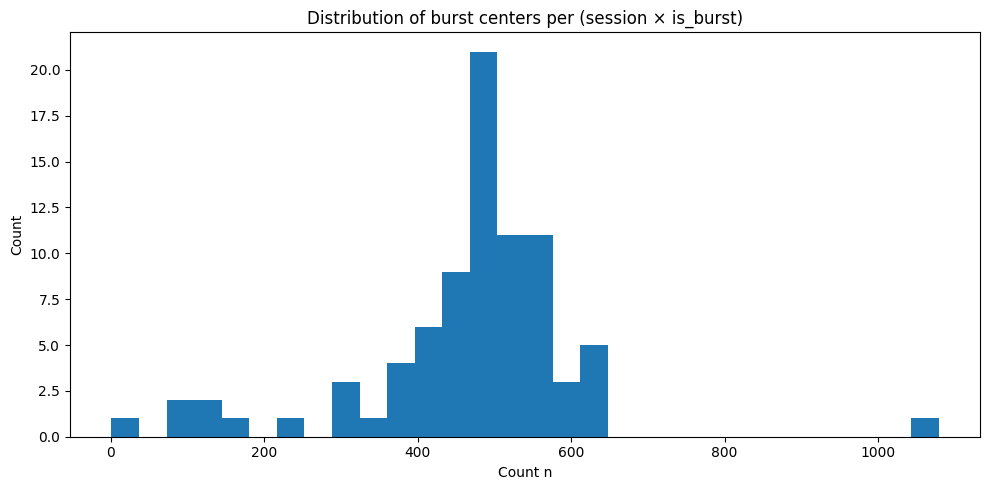

Empty DataFrame
Columns: [conference, session, n_bursts]
Index: []
[skip] Nothing to plot for: Distribution of TRUE bursts per session


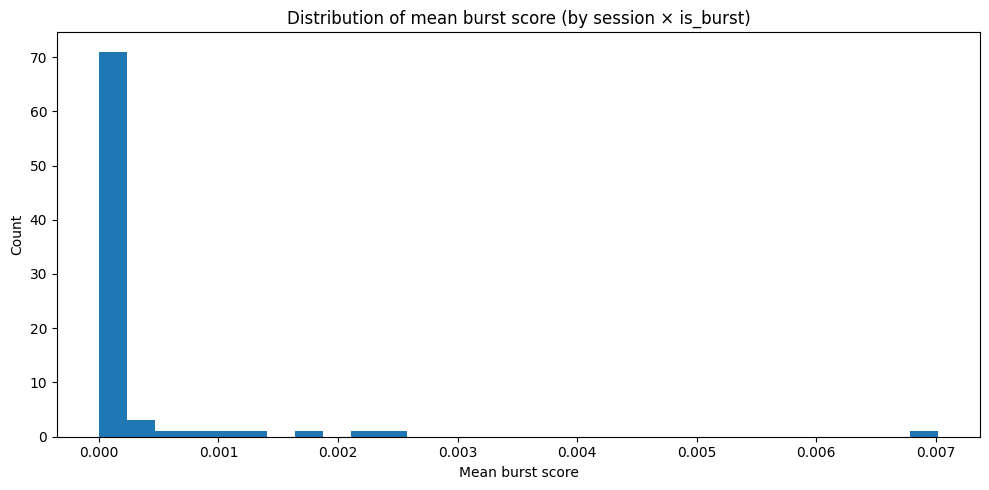

No TRUE bursts found to compute decision alignment.


In [5]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ---- Point to the correct directory (Data/scaling_outputs) ----
SCALING_DIR = Path("/Users/maxchalekson/Projects/NICO-Research/NICO_human-gemini/Data/scaling_outputs")

burst_summary_path = SCALING_DIR / "burst_summary_by_session.csv"
burst_annot_path   = SCALING_DIR / "bursts_all_sessions_annot.csv"
burst_raw_path     = SCALING_DIR / "bursts_all_sessions_raw.csv"

# ---- Load ----
burst_summary = pd.read_csv(burst_summary_path)
burst_annot   = pd.read_csv(burst_annot_path)
burst_raw     = pd.read_csv(burst_raw_path)

print("Summary columns:", burst_summary.columns.tolist())
print("Annot columns:",   burst_annot.columns.tolist())
print("Raw columns:",     burst_raw.columns.tolist())

# ---------- Helpers ----------
def _safe_hist(series, title, xlabel, ylabel="Count", bins=30):
    series = pd.Series(series).dropna()
    if series.empty:
        print(f"[skip] Nothing to plot for: {title}")
        return
    plt.figure(figsize=(10,5))
    plt.hist(series, bins=bins)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.tight_layout()
    plt.show()

# 1) How many burst centers per (session × is_burst) group?
if "n" in burst_summary.columns:
    _safe_hist(burst_summary["n"], 
               "Distribution of burst centers per (session × is_burst)",
               "Count n")
else:
    print("[skip] 'n' not in burst_summary; available:", burst_summary.columns.tolist())

# 2) True bursts per session (reconstruct from raw)
needed_cols = {"conference","session","is_burst"}
if needed_cols.issubset(burst_raw.columns):
    bursts_only = burst_raw[burst_raw["is_burst"] == True]
    bursts_per_session = (bursts_only
                          .groupby(["conference","session"])
                          .size()
                          .reset_index(name="n_bursts"))
    print(bursts_per_session.sort_values("n_bursts", ascending=False).head(10))
    _safe_hist(bursts_per_session["n_bursts"],
               "Distribution of TRUE bursts per session",
               "Number of flagged bursts")
else:
    print(f"[skip] Missing columns in bursts_all_sessions_raw for #2; need {needed_cols}")

# 3) Mean burst score (from summary)
if "mean_burst" in burst_summary.columns:
    _safe_hist(burst_summary["mean_burst"],
               "Distribution of mean burst score (by session × is_burst)",
               "Mean burst score")
else:
    print("[skip] 'mean_burst' not in burst_summary; available:", burst_summary.columns.tolist())

# 4) Alignment with decision labels (from annotated file)
def has_decision(lbls):
    # nearest_labels may be a stringified list or NaN
    if isinstance(lbls, str):
        return "decision" in lbls.lower()
    if isinstance(lbls, (list, tuple)):
        return any("decision" in str(x).lower() for x in lbls)
    return False

needed_cols = {"conference","session","is_burst","nearest_labels"}
if needed_cols.issubset(burst_annot.columns):
    annot_true = burst_annot[burst_annot["is_burst"] == True].copy()
    if len(annot_true):
        annot_true["has_decision"] = annot_true["nearest_labels"].apply(has_decision)
        rate = float(annot_true["has_decision"].mean())
        print(f"Share of TRUE bursts with a nearby 'decision' label: {rate:.2%}")
    else:
        print("No TRUE bursts found to compute decision alignment.")
else:
    print(f"[skip] Missing columns in bursts_all_sessions_annot for #4; need {needed_cols}")


## Analyzing all the conferences

In [8]:
# === Re-run bursts with more permissive gates + diagnostics ===
from pathlib import Path
import numpy as np, pandas as pd
from tqdm import tqdm

DATA_DIR    = Path("/Users/maxchalekson/Projects/NICO-Research/NICO_human-gemini/Data")
SCALING_DIR = DATA_DIR / "scaling_outputs"
SENT_PATH   = DATA_DIR / "scaled" / "sentences_ALL_filled.csv"
EMB_PATH    = SCALING_DIR / "embeddings_all.npy"

sent_all = pd.read_csv(SENT_PATH)
embeddings = np.load(EMB_PATH)

# Keep natural order so embeddings stay aligned
order_cols = [c for c in ["conference","session","_utter_row","_sent_idx"] if c in sent_all.columns]
if order_cols:
    sent_all = sent_all.sort_values(order_cols, ignore_index=True)

# ---- New parameters ----
WINDOW_HALF_SEC   = 60.0   # Δ
PAIR_MAX_GAP_SEC  = 45.0   # δ
SIM_THRESHOLD     = 0.68   # θ
BURST_THRESHOLD   = 0.08   # β
MIN_SPEAKERS      = 2      # m

def compute_bursts_for_session_diag(df: pd.DataFrame, E: np.ndarray,
                                    window_half, pair_gap, sim_thr, burst_thr, min_speakers):
    times    = df["sent_time_sec"].to_numpy(float)
    speakers = df["speaker"].astype(str).to_numpy()
    n = len(df)

    out = []
    L = 0
    for c in range(n):
        t0, t1 = times[c] - window_half, times[c] + window_half
        while L < n and times[L] < t0: L += 1
        R = c
        while R+1 < n and times[R+1] <= t1: R += 1
        if R - L + 1 < 2:
            out.append((times[c], 0.0, 0, 0, 0.0))
            continue

        idx = np.arange(L, R+1)
        T = times[idx]
        U = speakers[idx]
        M = E[idx] @ E[idx].T  # embeddings were normalized → cosine sims

        # mask: no self, |Δt| ≤ δ, cross-speaker
        m = np.ones_like(M, dtype=bool)
        np.fill_diagonal(m, False)
        dT = np.abs(T[:,None]-T[None,:])
        m &= (dT <= pair_gap)
        m &= (U[:,None] != U[None,:])

        iu = np.triu_indices(len(idx), 1)
        sel = m[iu]
        pair_count = int(sel.sum())
        if pair_count == 0:
            out.append((times[c], 0.0, 0, 0, 0.0))
            continue

        sims = M[iu][sel]
        hit  = sims >= sim_thr
        burst_score = float(hit.mean())

        # distinct speakers among hits
        hit_mat = np.zeros_like(M, dtype=bool)
        hit_mat[iu] = sel & (M[iu] >= sim_thr)
        hit_mat = np.triu(hit_mat, 1) | np.tril(hit_mat.T, 0)
        part_speakers = set()
        for a,b in zip(*np.where(hit_mat)):
            part_speakers.add(U[a]); part_speakers.add(U[b])
        num_part = len(part_speakers)

        is_burst = (burst_score >= burst_thr) & (num_part >= min_speakers)
        out.append((times[c], burst_score, num_part, pair_count, float(hit.sum())))

    res = pd.DataFrame(out, columns=["center_time_sec","burst_score","num_participants",
                                     "pair_count","hit_pairs"])
    res["is_burst"] = (res["burst_score"] >= burst_thr) & (res["num_participants"] >= min_speakers)
    return res

def recompute_all(sent_df, emb):
    outputs = []
    start = 0
    for (conf, sess), g in tqdm(sent_df.groupby(["conference","session"], sort=False), desc="Sessions"):
        n = len(g)
        subE = emb[start:start+n]
        b = compute_bursts_for_session_diag(
            g.reset_index(drop=True), subE,
            WINDOW_HALF_SEC, PAIR_MAX_GAP_SEC, SIM_THRESHOLD, BURST_THRESHOLD, MIN_SPEAKERS
        )
        b["conference"] = conf; b["session"] = sess
        outputs.append(b)
        start += n
    return pd.concat(outputs, ignore_index=True) if outputs else pd.DataFrame()

bursts_new = recompute_all(sent_all, embeddings)

# Save and print quick diagnostics
out_raw = SCALING_DIR / "bursts_all_sessions_raw_v2.csv"
bursts_new.to_csv(out_raw, index=False)
print("Wrote:", out_raw, "| rows:", len(bursts_new))

print("\nGate diagnostics (global):")
print(bursts_new[["pair_count","hit_pairs","num_participants","burst_score"]].describe().to_string())
print("True-burst rate:", bursts_new["is_burst"].mean())


Sessions: 100%|██████████| 82/82 [00:08<00:00, 10.01it/s]


Wrote: /Users/maxchalekson/Projects/NICO-Research/NICO_human-gemini/Data/scaling_outputs/bursts_all_sessions_raw_v2.csv | rows: 38303

Gate diagnostics (global):
         pair_count     hit_pairs  num_participants   burst_score
count  38303.000000  38303.000000      38303.000000  38303.000000
mean      71.774691      0.103099          0.110592      0.000476
std      303.279875      0.638680          0.519716      0.005387
min        0.000000      0.000000          0.000000      0.000000
25%        0.000000      0.000000          0.000000      0.000000
50%        0.000000      0.000000          0.000000      0.000000
75%       24.000000      0.000000          0.000000      0.000000
max     4384.000000      9.000000          5.000000      0.333333
True-burst rate: 0.0005221523118293606


In [9]:
import pandas as pd

# --- Load your new recomputed file ---
path = "/Users/maxchalekson/Projects/NICO-Research/NICO_human-gemini/Data/scaling_outputs/bursts_all_sessions_raw_v2.csv"
df = pd.read_csv(path)

# --- Basic sanity checks ---
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
print("Any TRUE bursts?:", df["is_burst"].any())
print("Count of TRUE bursts:", int(df["is_burst"].sum()))
print("True-burst rate (%):", 100 * df["is_burst"].mean())

# --- Show top of file to inspect values ---
print("\nHead of file:")
print(df.head(10))

# --- Session-level summary ---
if {"conference","session","is_burst"}.issubset(df.columns):
    bursts_per_session = (
        df[df["is_burst"]==True]
        .groupby(["conference","session"])
        .size()
        .reset_index(name="n_bursts")
    )
    print("\nSessions with the most bursts:")
    print(bursts_per_session.sort_values("n_bursts", ascending=False).head(10))


Shape: (38303, 8)
Columns: ['center_time_sec', 'burst_score', 'num_participants', 'pair_count', 'hit_pairs', 'is_burst', 'conference', 'session']
Any TRUE bursts?: True
Count of TRUE bursts: 20
True-burst rate (%): 0.05221523118293606

Head of file:
   center_time_sec  burst_score  num_participants  pair_count  hit_pairs  \
0       511.500000          0.0                 0           0        0.0   
1       272.070312          0.0                 0           0        0.0   
2       287.070312          0.0                 0           0        0.0   
3       152.409756          0.0                 0           0        0.0   
4       155.395122          0.0                 0           0        0.0   
5       162.485366          0.0                 0           0        0.0   
6       175.836585          0.0                 0           0        0.0   
7       184.502439          0.0                 0           0        0.0   
8       191.509756          0.0                 0           0     

We've pulled out **20 bursts** across all **83 sessions**

In [11]:
# === Rebuild annotated bursts for v2 thresholds ===
from pathlib import Path
import pandas as pd
import numpy as np
import re

DATA_DIR    = Path("/Users/maxchalekson/Projects/NICO-Research/NICO_human-gemini/Data")
SCALING_DIR = DATA_DIR / "scaling_outputs"

SENT_PATH   = DATA_DIR / "scaled" / "sentences_ALL_filled.csv"
RAW_V2_PATH = SCALING_DIR / "bursts_all_sessions_raw_v2.csv"
ANNOT_V2_PATH = SCALING_DIR / "bursts_all_sessions_annot_v2.csv"

# --- Load ---
sent_all = pd.read_csv(SENT_PATH)
raw_v2   = pd.read_csv(RAW_V2_PATH)

# Keep natural order (no time sort)
order_cols = [c for c in ["conference","session","_utter_row","_sent_idx"] if c in sent_all.columns]
if order_cols:
    sent_all = sent_all.sort_values(order_cols, ignore_index=True)

# --- Label normalizer from 'annotations' free text (loose match; tweak if needed) ---
def normalize_labels(x):
    if not isinstance(x, str) or not x.strip():
        return []
    tokens = [t.strip().lower() for t in re.split(r"[;,/|]", x) if t.strip()]
    return tokens

sent_all["labels_norm"] = sent_all.get("annotations", "").apply(normalize_labels)

# --- Annotate: nearest sentence to each center_time (per session) ---
def annotate_bursts(bursts_df, sentences_df):
    out_rows = []
    for (conf, sess), bgrp in bursts_df.groupby(["conference","session"], sort=False):
        sgrp = sentences_df[(sentences_df["conference"]==conf) & (sentences_df["session"]==sess)]
        if sgrp.empty:
            # carry rows with Nones if we somehow lack sentences
            for _, r in bgrp.iterrows():
                out_rows.append({**r,
                                 "nearest_sentence": None,
                                 "nearest_labels": None,
                                 "nearest_speaker": None,
                                 "nearest_time_sec": None})
            continue

        times = sgrp["sent_time_sec"].to_numpy(dtype=float)
        for _, r in bgrp.iterrows():
            ct = float(r["center_time_sec"])
            idx = int(np.argmin(np.abs(times - ct)))
            near = sgrp.iloc[idx]
            out_rows.append({
                **r,
                "nearest_sentence": near.get("sentence"),
                "nearest_labels": near.get("labels_norm"),
                "nearest_speaker": near.get("speaker"),
                "nearest_time_sec": float(near.get("sent_time_sec", np.nan)),
            })
    return pd.DataFrame(out_rows)

annot_v2 = annotate_bursts(raw_v2, sent_all)

# Save
annot_v2.to_csv(ANNOT_V2_PATH, index=False)
print("Wrote:", ANNOT_V2_PATH, "| rows:", len(annot_v2))

# Quick check: how many TRUE bursts now?
print("TRUE bursts in v2 annot:", int(annot_v2["is_burst"].sum()))

# Show a sample of TRUE bursts with context columns
sample_cols = ["conference","session","center_time_sec","burst_score","num_participants",
               "nearest_speaker","nearest_sentence","nearest_labels"]
print(annot_v2[annot_v2["is_burst"]==True][sample_cols].head(20).to_string(index=False))

# Optional: focus on the two sessions you saw in raw_v2
top_sessions = ["2021_10_01_MZT_S11","2021_06_10_SLU_S1"]
sub = annot_v2[(annot_v2["is_burst"]==True) & (annot_v2["session"].isin(top_sessions))]
if not sub.empty:
    print("\nTop sessions (v2) preview:")
    print(sub[sample_cols].head(20).to_string(index=False))
else:
    print("\n[Note] No TRUE bursts for the specified top sessions in the v2 annotated file (double-check session names).")


Wrote: /Users/maxchalekson/Projects/NICO-Research/NICO_human-gemini/Data/scaling_outputs/bursts_all_sessions_annot_v2.csv | rows: 38303
TRUE bursts in v2 annot: 20
        conference            session  center_time_sec  burst_score  num_participants nearest_speaker                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                nearest_sentenc

Auto-picked session: 2021_10_01_MZT_S11 / 2021_10_01_MZT_S11
Saved timeline: /Users/maxchalekson/Projects/NICO-Research/NICO_human-gemini/Data/scaling_outputs/viz/timeline_2021_10_01_MZT_S11_2021_10_01_MZT_S11.png


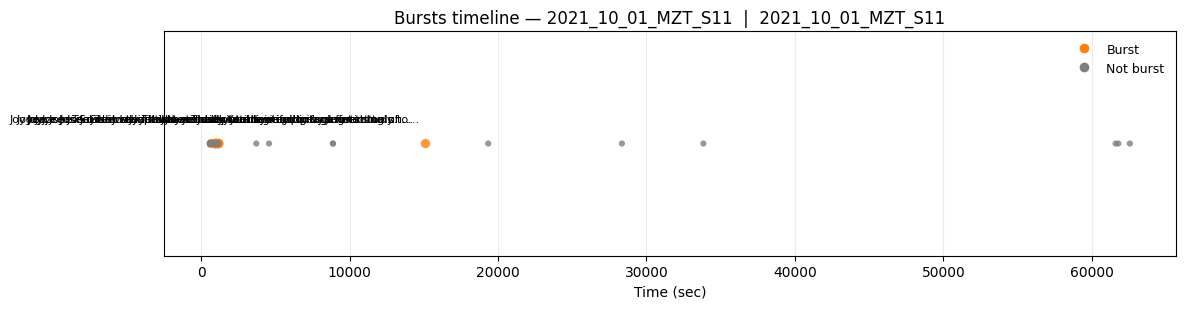

Saved reading pack: /Users/maxchalekson/Projects/NICO-Research/NICO_human-gemini/Data/scaling_outputs/viz/reading_pack_2021_10_01_MZT_S11_2021_10_01_MZT_S11.csv


In [12]:
# ===================== Session timeline visualization (bursts) =====================
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import textwrap

DATA_DIR    = Path("/Users/maxchalekson/Projects/NICO-Research/NICO_human-gemini/Data")
SCALING_DIR = DATA_DIR / "scaling_outputs"

ANNOT_V2_PATH = SCALING_DIR / "bursts_all_sessions_annot_v2.csv"
SENT_PATH     = DATA_DIR / "scaled" / "sentences_ALL_filled.csv"
OUT_DIR       = SCALING_DIR / "viz"
OUT_DIR.mkdir(parents=True, exist_ok=True)

# ---------------- Load data ----------------
annot_v2 = pd.read_csv(ANNOT_V2_PATH)
sent_all = pd.read_csv(SENT_PATH)

# Keep natural order if available
order_cols = [c for c in ["conference","session","_utter_row","_sent_idx"] if c in sent_all.columns]
if order_cols:
    sent_all = sent_all.sort_values(order_cols, ignore_index=True)

# --------------- Helper: pick a session ---------------
def pick_bursty_session(annot_df: pd.DataFrame) -> tuple[str,str]:
    """Return (conference, session) with most TRUE bursts; if none, returns first pair."""
    if annot_df["is_burst"].any():
        top = (annot_df[annot_df["is_burst"]==True]
               .groupby(["conference","session"])
               .size()
               .reset_index(name="n_bursts")
               .sort_values("n_bursts", ascending=False))
        if len(top):
            return str(top.iloc[0]["conference"]), str(top.iloc[0]["session"])
    # fallback to most represented session
    fallback = (annot_df.groupby(["conference","session"])
                .size().reset_index(name="n")
                .sort_values("n", ascending=False))
    if len(fallback):
        return str(fallback.iloc[0]["conference"]), str(fallback.iloc[0]["session"])
    return None, None

# --------------- Visualization ---------------
def plot_session_bursts(annot_df: pd.DataFrame,
                        conf: str, sess: str,
                        label_top_k: int = 8,
                        label_wrap: int = 60,
                        figsize=(12, 3.2)):
    sub = annot_df[(annot_df["conference"]==conf) & (annot_df["session"]==sess)].copy()
    if sub.empty:
        print(f"[no data] {conf} / {sess}")
        return

    # scatter parameters
    x = sub["center_time_sec"].to_numpy(float)
    is_burst = sub["is_burst"].to_numpy(bool)
    scores = sub["burst_score"].to_numpy(float)
    parts = sub["num_participants"].to_numpy(int)

    # size by score (bounded)
    s = 20 + 180 * np.clip(scores, 0, 1)

    # color: non-burst gray, burst orange
    colors = np.where(is_burst, "tab:orange", "tab:gray")

    fig, ax = plt.subplots(figsize=figsize)
    ax.scatter(x, np.zeros_like(x), s=s, c=colors, alpha=0.8, edgecolors="none")
    ax.set_yticks([])
    ax.set_xlabel("Time (sec)")
    ax.set_title(f"Bursts timeline — {sess}  |  {conf}")

    # Highlight the top-K bursts (by score) with tiny labels
    top = sub.sort_values("burst_score", ascending=False).head(label_top_k)
    for _, r in top.iterrows():
        if not r["is_burst"]:
            continue
        t = float(r["center_time_sec"])
        lab_speaker = str(r.get("nearest_speaker", "") or "")
        lab_sent = str(r.get("nearest_sentence", "") or "")
        # short snippet
        snippet = textwrap.shorten(lab_sent, width=label_wrap, placeholder="…")
        lab = f"{lab_speaker}: {snippet}" if lab_speaker else snippet
        ax.annotate(lab, xy=(t, 0), xytext=(0, 14), textcoords="offset points",
                    rotation=0, ha="center", va="bottom", fontsize=8, color="black")

    # grid for readability
    ax.grid(axis="x", alpha=0.25)

    # legend proxy
    from matplotlib.lines import Line2D
    leg = [Line2D([0],[0], marker='o', color='w', label='Burst',
                  markerfacecolor='tab:orange', markersize=8),
           Line2D([0],[0], marker='o', color='w', label='Not burst',
                  markerfacecolor='tab:gray', markersize=8)]
    ax.legend(handles=leg, loc="upper right", frameon=False, fontsize=9)

    plt.tight_layout()
    # Save image
    out_png = OUT_DIR / f"timeline_{conf}_{sess}.png"
    plt.savefig(out_png, dpi=150, bbox_inches="tight")
    print("Saved timeline:", out_png)
    plt.show()

# --------------- Reading pack (windows around top bursts) ---------------
def extract_reading_pack(conf: str, sess: str, top_k: int = 5, half_width_sec: float = 20.0) -> Path | None:
    bsub = annot_v2[(annot_v2["conference"]==conf) & (annot_v2["session"]==sess)]
    if bsub.empty:
        print(f"[no bursts] {conf}/{sess}")
        return None
    bsub = bsub.sort_values("burst_score", ascending=False).head(top_k)

    ssub = sent_all[(sent_all["conference"]==conf) & (sent_all["session"]==sess)]
    if ssub.empty:
        print(f"[no sentences] {conf}/{sess}")
        return None

    rows = []
    for _, r in bsub.iterrows():
        center = float(r["center_time_sec"])
        lo, hi = center - half_width_sec, center + half_width_sec
        window = ssub[(ssub["sent_time_sec"] >= lo) & (ssub["sent_time_sec"] <= hi)]
        window = window.sort_values("sent_time_sec", ignore_index=True)
        if window.empty:
            continue
        dfw = window[["sent_time_sec","speaker","sentence"]].copy()
        dfw.insert(0, "center_time_sec", center)
        dfw.insert(0, "session", sess)
        dfw.insert(0, "conference", conf)
        rows.append(dfw)

    if not rows:
        print(f"[no windows] {conf}/{sess}")
        return None

    pack = pd.concat(rows, ignore_index=True)
    out_csv = OUT_DIR / f"reading_pack_{conf}_{sess}.csv"
    pack.to_csv(out_csv, index=False)
    print("Saved reading pack:", out_csv)
    return out_csv

# --------------- Run for a session ---------------
# AUTO: pick most bursty session if you don't want to hardcode
conf_auto, sess_auto = pick_bursty_session(annot_v2)
print("Auto-picked session:", conf_auto, "/", sess_auto)

# OR set manually, e.g.:
# conf_auto, sess_auto = "2021_10_01_MZT_S11", "2021_10_01_MZT_S11"
# conf_auto, sess_auto = "2021_06_10_SLU_S1", "2021_06_10_SLU_S1"

if conf_auto and sess_auto:
    plot_session_bursts(annot_v2, conf_auto, sess_auto, label_top_k=8, label_wrap=60)
    extract_reading_pack(conf_auto, sess_auto, top_k=5, half_width_sec=20.0)
else:
    print("[no session available to plot]")


In [13]:
import pandas as pd

# Paths (adjust if needed)
annot_path = "/Users/maxchalekson/Projects/NICO-Research/NICO_human-gemini/Data/scaling_outputs/bursts_all_sessions_annot_v2.csv"
utterance_path = "/Users/maxchalekson/Projects/NICO-Research/NICO_human-gemini/Data/utterance_data_aligned_full.csv"

# Load data
annot = pd.read_csv(annot_path)
utter = pd.read_csv(utterance_path)

# Just TRUE bursts
bursts = annot[annot["is_burst"] == True].copy()

print("Total flagged bursts:", len(bursts))

# Function to extract transcript context around a burst
def extract_context(burst_row, window=45):
    conf = burst_row["conference"]
    sess = burst_row["session"]
    t = burst_row["center_time_sec"]

    # Match utterances in same session within ±window
    session_utts = utter[utter["session"] == sess]
    context = session_utts[
        (session_utts["start_sec_adjusted"] <= t + window) &
        (session_utts["end_sec_adjusted"]   >= t - window)
    ].copy()

    context["burst_center"] = t
    context["burst_session"] = sess
    return context

# Collect contexts for first N bursts
N = 5
contexts = []
for i, row in bursts.head(N).iterrows():
    ctx = extract_context(row, window=45)
    contexts.append(ctx)

contexts_df = pd.concat(contexts, ignore_index=True)

# Save for reading
out_path = "/Users/maxchalekson/Projects/NICO-Research/NICO_human-gemini/Data/burst_context_samples.csv"
contexts_df.to_csv(out_path, index=False)

print(f"Saved context for {N} bursts to {out_path}")
print(contexts_df[["burst_session","burst_center","speaker","transcript"]].head(20))


Total flagged bursts: 20
Saved context for 5 bursts to /Users/maxchalekson/Projects/NICO-Research/NICO_human-gemini/Data/burst_context_samples.csv
        burst_session  burst_center          speaker  \
0   2021_06_10_SLU_S1    731.236364   Niki Parenteau   
1   2021_06_10_SLU_S1    731.236364   Niki Parenteau   
2   2021_06_10_SLU_S1    731.236364   Niki Parenteau   
3   2021_06_10_SLU_S1    731.236364  Stilianos Louca   
4   2021_06_10_SLU_S1    731.236364   Niki Parenteau   
5   2021_06_10_SLU_S1    731.236364   Noah Planavsky   
6   2021_06_10_SLU_S1    731.236364   Niki Parenteau   
7   2021_06_10_SLU_S1    731.236364   Noah Planavsky   
8   2021_06_10_SLU_S1    731.236364   Niki Parenteau   
9   2021_06_10_SLU_S1    731.236364   Noah Planavsky   
10  2021_06_10_SLU_S1    731.236364   Noah Planavsky   
11  2021_06_10_SLU_S1    731.236364     Morgan Raven   
12  2021_06_10_SLU_S1    731.236364      Smadar Naoz   
13  2021_06_10_SLU_S1    731.236364  Solange Duhamel   
14  2021_06_1

### burst meta + transcript context

In [15]:
from pathlib import Path
import pandas as pd
import numpy as np

DATA_DIR    = Path("/Users/maxchalekson/Projects/NICO-Research/NICO_human-gemini/Data")
SCALING_DIR = DATA_DIR / "scaling_outputs"

# Inputs
ANNOT_V2  = SCALING_DIR / "bursts_all_sessions_annot_v2.csv"   # rebuilt annotated file
SENT_ALL  = DATA_DIR / "scaled" / "sentences_ALL_filled.csv"   # sentence-level table

# Output dir
PACK_DIR  = SCALING_DIR / "reading_packs"
PACK_DIR.mkdir(parents=True, exist_ok=True)

# Controls
TOP_K_GLOBAL   = None   # e.g., 50 to take top 50 bursts globally; None = take all True bursts
MAX_PER_SESSION = 5     # cap per-session packs; set to None for no cap
HALF_WIDTH_SEC  = 20.0  # ± seconds of transcript around each burst
MAX_ROWS_WINDOW = 120   # safety cap on rows per window

# Load
annot = pd.read_csv(ANNOT_V2)
sents = pd.read_csv(SENT_ALL)

# Sentence text column: prefer 'sentence', else 'transcript'
SENT_TEXT_COL = "sentence" if "sentence" in sents.columns else ("transcript" if "transcript" in sents.columns else None)
if SENT_TEXT_COL is None:
    raise ValueError("No sentence text column found. Expected 'sentence' or 'transcript' in sentences_ALL_filled.csv")

# Natural order (if present)
order_cols = [c for c in ["conference","session","_utter_row","_sent_idx"] if c in sents.columns]
if order_cols:
    sents = sents.sort_values(order_cols, ignore_index=True)

# Keep TRUE bursts and add stable id
bursts = annot[annot["is_burst"]==True].copy()
if bursts.empty:
    print("[No TRUE bursts in annot v2. Re-run thresholds or check paths.]")
else:
    bursts = bursts.sort_values(["conference","session","center_time_sec"]).reset_index(drop=True)
    bursts["burst_id"] = np.arange(1, len(bursts)+1)

    # Choose which bursts to pack
    if TOP_K_GLOBAL is not None:
        choose = bursts.sort_values("burst_score", ascending=False).head(int(TOP_K_GLOBAL))
    else:
        # Optionally cap per session
        if MAX_PER_SESSION is not None:
            choose = (bursts.sort_values(["conference","session","burst_score"], ascending=[True,True,False])
                      .groupby(["conference","session"], as_index=False)
                      .head(int(MAX_PER_SESSION)))
        else:
            choose = bursts

    def make_pack_rows(b, half_width=HALF_WIDTH_SEC, max_rows=MAX_ROWS_WINDOW):
        conf, sess = str(b["conference"]), str(b["session"])
        ct   = float(b["center_time_sec"])
        meta = {
            "burst_id":          int(b["burst_id"]),
            "conference":        conf,
            "session":           sess,
            "center_time_sec":   ct,
            "burst_score":       float(b.get("burst_score", np.nan)),
            "num_participants":  int(b.get("num_participants", 0)),
            "nearest_speaker":   b.get("nearest_speaker", ""),
            "nearest_sentence":  b.get("nearest_sentence", ""),
            "nearest_time_sec":  float(b.get("nearest_time_sec", np.nan)) if pd.notna(b.get("nearest_time_sec", np.nan)) else np.nan,
        }
        sub = sents[(sents["conference"]==conf) & (sents["session"]==sess)].copy()
        if sub.empty:
            return pd.DataFrame([{**meta, "rel_sec": np.nan, "sent_time_sec": np.nan,
                                  "speaker":"", SENT_TEXT_COL:"", "is_nearest": False}])

        window = sub[(sub["sent_time_sec"] >= ct - half_width) & (sub["sent_time_sec"] <= ct + half_width)].copy()
        window = window.sort_values("sent_time_sec", ignore_index=True)
        if window.empty:
            return pd.DataFrame([{**meta, "rel_sec": np.nan, "sent_time_sec": np.nan,
                                  "speaker":"", SENT_TEXT_COL:"", "is_nearest": False}])

        window["rel_sec"] = window["sent_time_sec"] - ct

        # mark the nearest line
        if not np.isnan(meta["nearest_time_sec"]):
            window["is_nearest"] = np.isclose(window["sent_time_sec"], meta["nearest_time_sec"], atol=1e-6)
        else:
            idx = int(np.argmin(np.abs(window["sent_time_sec"] - ct)))
            window["is_nearest"] = False
            window.loc[idx, "is_nearest"] = True

        # keep columns (include is_nearest!)
        cols_keep = ["sent_time_sec","rel_sec","speaker", SENT_TEXT_COL, "is_nearest"]
        # include any code columns if present
        for c in ["annotations","dialogue_act","decision","explanation","new_idea"]:
            if c in window.columns: cols_keep.append(c)
        window = window[cols_keep].head(max_rows)

        # prepend meta columns so each row carries the burst summary
        for k in list(meta.keys())[::-1]:
            window.insert(0, k, meta[k])
        return window

    # Build packs
    packs = []
    for _, b in choose.iterrows():
        rows = make_pack_rows(b)
        packs.append(rows)
        out = PACK_DIR / f"pack_{b['conference']}_{b['session']}_burst{int(b['burst_id']):03d}.csv"
        rows.to_csv(out, index=False)

    if packs:
        pack_all = pd.concat(packs, ignore_index=True)
        out_all = PACK_DIR / ("pack_TOPK_bursts.csv" if TOP_K_GLOBAL else "pack_ALL_bursts_capped.csv")
        pack_all.to_csv(out_all, index=False)
        print(f"Wrote {len(choose)} bursts to per-burst files in:", PACK_DIR)
        print("Also wrote combined pack:", out_all)

        # SAFE preview (only print columns that exist)
        want = ["burst_id","conference","session","center_time_sec",
                "burst_score","num_participants","sent_time_sec","rel_sec",
                "speaker", SENT_TEXT_COL, "is_nearest"]
        preview_cols = [c for c in want if c in pack_all.columns]
        print(pack_all[preview_cols].head(20).to_string(index=False))
    else:
        print("[No packs created]")


Wrote 10 bursts to per-burst files in: /Users/maxchalekson/Projects/NICO-Research/NICO_human-gemini/Data/scaling_outputs/reading_packs
Also wrote combined pack: /Users/maxchalekson/Projects/NICO-Research/NICO_human-gemini/Data/scaling_outputs/reading_packs/pack_ALL_bursts_capped.csv
 burst_id        conference           session  center_time_sec  burst_score  num_participants  sent_time_sec    rel_sec              speaker                                                                                                                                                                                                                                                                                                                                                     sentence  is_nearest
        3 2021_06_10_SLU_S1 2021_06_10_SLU_S1       731.236364     0.333333                 2     713.845794 -17.390569          Smadar Naoz                                                                          

### CHECKING IT

In [16]:
import pandas as pd
from pathlib import Path

SCALING_DIR = Path("/Users/maxchalekson/Projects/NICO-Research/NICO_human-gemini/Data/scaling_outputs")
PACK_ALL    = SCALING_DIR / "reading_packs" / "pack_ALL_bursts_capped.csv"

pack = pd.read_csv(PACK_ALL)
print("Rows:", len(pack))
print("Columns:", pack.columns.tolist())

# Peek a few rows per burst_id
cols = [c for c in [
    "burst_id","conference","session","center_time_sec","burst_score","num_participants",
    "sent_time_sec","rel_sec","speaker","sentence","is_nearest",
    "annotations","dialogue_act","decision","explanation","new_idea"
] if c in pack.columns]
display(pack[cols].head(20))


Rows: 303
Columns: ['burst_id', 'conference', 'session', 'center_time_sec', 'burst_score', 'num_participants', 'nearest_speaker', 'nearest_sentence', 'nearest_time_sec', 'sent_time_sec', 'rel_sec', 'speaker', 'sentence', 'is_nearest', 'annotations', 'dialogue_act']


,burst_id,conference,session,center_time_sec,burst_score,num_participants,sent_time_sec,rel_sec,speaker,sentence,is_nearest,annotations,dialogue_act
0,3,2021_06_10_SLU_S1,2021_06_10_SLU_S1,731.236364,0.333333,2,713.845794,-17.390569,Smadar Naoz,"about temperature, I wonder if we if we're als...",False,[{'present new idea': 'The speaker introduces ...,NaN
1,3,2021_06_10_SLU_S1,2021_06_10_SLU_S1,731.236364,0.333333,2,714.400894,-16.835470,Niki Parenteau,"Um, so it's it is a possibility to look for that.",False,[{'expand on existing idea': 'The speaker buil...,NaN
2,3,2021_06_10_SLU_S1,2021_06_10_SLU_S1,731.236364,0.333333,2,716.465278,-14.771086,Jeffrey Marlow,"Number two, um, are perhaps uh, over focus on ...",False,[{'summarize discussion': {'explanation': 'Jef...,NaN
3,3,2021_06_10_SLU_S1,2021_06_10_SLU_S1,731.236364,0.333333,2,716.503565,-14.732798,Jay Forsythe(he/him),"Um, the for example like Murchison one of the ...",False,[{'explain or define term or concept': 'Jay ex...,NaN
4,3,2021_06_10_SLU_S1,2021_06_10_SLU_S1,731.236364,0.333333,2,718.878788,-12.357576,Niki Parenteau,"And um, as Richard said, we'll kind of keep it...",False,{'assign task': 'Niki assigns Jeff the task of...,NaN
5,3,2021_06_10_SLU_S1,2021_06_10_SLU_S1,731.236364,0.333333,2,720.546304,-10.690060,Niki Parenteau,"Um, but again, it might be difficult uh to put...",False,[{'expand on existing idea': 'The speaker buil...,NaN
6,3,2021_06_10_SLU_S1,2021_06_10_SLU_S1,731.236364,0.333333,2,720.623572,-10.612791,Smadar Naoz,So we can have um tidal effects that will cont...,False,[{'present new idea': 'The speaker introduces ...,NaN
7,3,2021_06_10_SLU_S1,2021_06_10_SLU_S1,731.236364,0.333333,2,720.667870,-10.568494,Noah Planavsky,You have actual empirical records of it and th...,False,"{'expand on existing idea': ""Noah expands on R...",NaN
8,3,2021_06_10_SLU_S1,2021_06_10_SLU_S1,731.236364,0.333333,2,720.994186,-10.242178,Solange Duhamel,"So I think thinking of both the microbes, thei...",False,[{'explain or define term or concept': 'The sp...,NaN
9,3,2021_06_10_SLU_S1,2021_06_10_SLU_S1,731.236364,0.333333,2,724.244318,-6.992045,Jeffrey Marlow,"Um, this idea of meteorites as net positive or...",False,[{'summarize discussion': {'explanation': 'Jef...,NaN


Note: right now it is focusing on 2 people bursts, but this can be scaled so then we can (for e.g.) find optimal no. of people for convergence.

## running it now for 2-7 participants

Recomputing participants per burst in ±20.0s windows...
Participant thresholds to evaluate: [2, 3, 4, 5, 6, 7]
[m≥2] eligible windows=17 | sentences IN=238 OUT=38065
[m≥3] eligible windows=17 | sentences IN=238 OUT=38065
[m≥4] eligible windows=17 | sentences IN=238 OUT=38065
[m≥5] eligible windows=16 | sentences IN=233 OUT=38070
[m≥6] eligible windows=12 | sentences IN=174 OUT=38129
[m≥7] eligible windows=8 | sentences IN=124 OUT=38179
Wrote: /Users/maxchalekson/Projects/NICO-Research/NICO_human-gemini/Data/scaling_outputs/summaries/label_enrichment_ann_and_regex_by_participants_RECOMP.csv
Wrote (filtered): /Users/maxchalekson/Projects/NICO-Research/NICO_human-gemini/Data/scaling_outputs/summaries/label_enrichment_ann_and_regex_FILTERED_RECOMP.csv

=== Top signals for m≥2 (filtered; MIN_IN=10, MIN_OUT=10) ===
                  token kind  hit_out  hit_in  rate_out_per_1000  rate_in_per_1000  ratio_in_out
            assign task  ann     1650      21             43.347            88.235

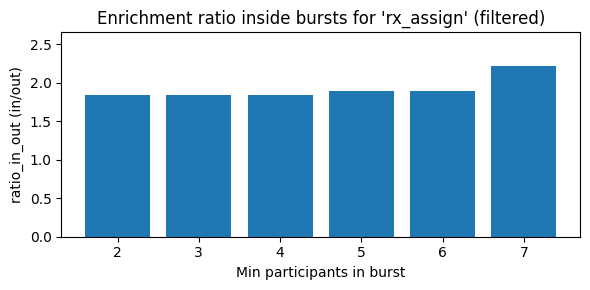

Saved plot: /Users/maxchalekson/Projects/NICO-Research/NICO_human-gemini/Data/scaling_outputs/summaries/enrichment_rx_assign_filtered.png


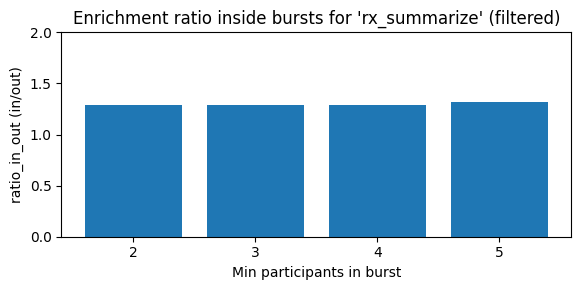

Saved plot: /Users/maxchalekson/Projects/NICO-Research/NICO_human-gemini/Data/scaling_outputs/summaries/enrichment_rx_summarize_filtered.png


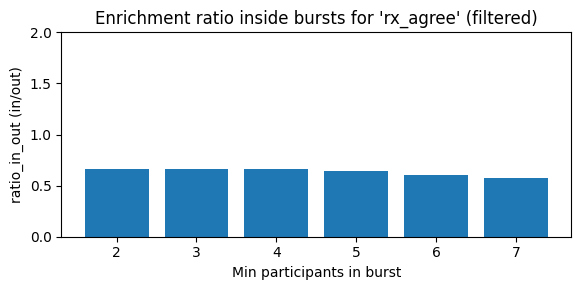

Saved plot: /Users/maxchalekson/Projects/NICO-Research/NICO_human-gemini/Data/scaling_outputs/summaries/enrichment_rx_agree_filtered.png


In [23]:
# ========= ENRICHMENT v3 (robust): recompute participants; ann-tokens + regex-tags; counts & filters =========
from pathlib import Path
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt

# ---- Paths ----
DATA_DIR    = Path("/Users/maxchalekson/Projects/NICO-Research/NICO_human-gemini/Data")
SCALING_DIR = DATA_DIR / "scaling_outputs"
ANNOT_V2    = SCALING_DIR / "bursts_all_sessions_annot_v2.csv"   # TRUE bursts (any m)
SENTS_ALL   = DATA_DIR / "scaled" / "sentences_ALL_filled.csv"

OUT_DIR     = SCALING_DIR / "summaries"
OUT_DIR.mkdir(parents=True, exist_ok=True)

# ---- Load ----
annot = pd.read_csv(ANNOT_V2)
sents = pd.read_csv(SENTS_ALL)

# Prefer 'sentence' text; fallback to 'transcript'
TEXT_COL = "sentence" if "sentence" in sents.columns else ("transcript" if "transcript" in sents.columns else None)
if TEXT_COL is None:
    raise ValueError("Expected a text column named 'sentence' or 'transcript' in sentences_ALL_filled.csv")

# ========== 1) TOKENIZATION ==========
# (A) Codebook-style tokens from 'annotations' (substring match; tweak KEYS if needed)
KEYS = [
    "decision", "assign task", "action item",
    "agreement", "agree", "consensus",
    "summarize discussion",
    "present new idea", "new idea",
    "expand on existing idea",
    "explain or define", "explain", "define",
    "encourage", "question"
]
def extract_tokens(x: str) -> list[str]:
    if not isinstance(x, str): return []
    low = x.lower()
    return [k for k in KEYS if k in low]

sents["ann_tokens"] = sents.get("annotations","").apply(extract_tokens)

# (B) Regex tags (from BOTH annotations + sentence text) — safer quoting with VERBOSE
LEX = {
    "rx_decision": re.compile(r"""
        \b(?:                                   
            decid(?:e|ing|ed|es)                 # decide, deciding, decided, decides
          | we(?:['’]|\s)ll\s(?:go|do|use)       # we'll go/do/use (allow space)
          | let(?:['’]|\s)s\s(?:go|do|use)       # let's go/do/use (allow space)
          | agree\s(?:to|on)                      # agree to/on
          | choose|chose|picked                   # choose/chose/picked
          | settle\s(?:on|for)                    # settle on/for
          | we\s(?:are|(?:['’]re)|re)\s(?:settling|going)  # we are/’re/re settling/going
        )\b
    """, re.IGNORECASE | re.VERBOSE),
    "rx_assign": re.compile(r"""
        \b(?:
            assign|assignment|owner|ownership
          | you(?:['’]|\s)ll\s(?:do|own|take)     # you'll do/own/take
          | i(?:['’]|\s)ll\s(?:do|own|take)       # i'll do/own/take
          | can\s+you\s+\w+                        # can you <verb>
          | action\s+item
          | follow[-\s]?up
        )\b
    """, re.IGNORECASE | re.VERBOSE),
    "rx_summarize": re.compile(r"""
        \b(?:
            sum(?:mary|marize|marising|marizing)   # summary/summarize/...
          | recap
          | in\s+summary
          | to\s+sum\s+up
          | what\s+we\s+(?:have|got)
          | so\s+(?:the|we)
        )\b
    """, re.IGNORECASE | re.VERBOSE),
    "rx_agree": re.compile(r"""
        \b(?:
            agree|agreement
          | sounds\s+good
          | sgtm
          | works\s+for\s+me
          | that\s+works
          | yes|yep|ok(?:ay)?
        )\b
    """, re.IGNORECASE | re.VERBOSE),
}

def tag_via_regex(row) -> dict:
    text = f"{str(row.get('annotations',''))} || {str(row.get(TEXT_COL,''))}"
    return {name: bool(rx.search(text)) for name, rx in LEX.items()}

# quick sanity: ensure patterns behave
_ = tag_via_regex({"annotations":"", TEXT_COL:"let’s go with option A"})  # should hit rx_decision
_ = tag_via_regex({"annotations":"you'll take notes", TEXT_COL:""})       # should hit rx_assign
_ = tag_via_regex({"annotations":"", TEXT_COL:"to sum up, we propose..."})# should hit rx_summarize
_ = tag_via_regex({"annotations":"", TEXT_COL:"sounds good to me"})       # should hit rx_agree

rx_df = sents.apply(tag_via_regex, axis=1, result_type="expand")
sents = pd.concat([sents, rx_df], axis=1)

# ========== 2) HELPERS ==========
session_index = {k: df for k, df in sents.groupby(["conference","session"])}

def participants_in_window(conf: str, sess: str, center_t: float, W: float) -> int:
    key = (conf, sess)
    if key not in session_index: return 0
    S = session_index[key]
    m = (S["sent_time_sec"] >= center_t - W) & (S["sent_time_sec"] <= center_t + W)
    if not m.any(): return 0
    return int(S.loc[m, "speaker"].dropna().astype(str).str.strip().nunique())

def mark_sentences_in_windows(bursts_df: pd.DataFrame, W: float) -> pd.Series:
    """Boolean Series over sents.index: True if sentence inside ANY burst window."""
    mark = pd.Series(False, index=sents.index)
    for (conf, sess), grp in bursts_df.groupby(["conference","session"]):
        if (conf, sess) not in session_index: continue
        S = session_index[(conf, sess)]
        for ct in grp["center_time_sec"].astype(float):
            m = (S["sent_time_sec"] >= ct - W) & (S["sent_time_sec"] <= ct + W)
            if m.any():
                mark.loc[S.index[m]] = True
    return mark

def enrich_counts_for_mask(in_mask: pd.Series) -> pd.DataFrame:
    """
    Compute counts/rates for:
      - ann_tokens (explode)
      - regex tags (rx_* boolean columns)
    Returns tall table with columns:
      token, kind (ann/rx), hit_in, hit_out, base_in, base_out, rate_in_per_1000, rate_out_per_1000, ratio_in_out
    """
    base_in  = int(in_mask.sum())
    base_out = int((~in_mask).sum())

    rows = []

    # (A) ann_tokens
    ann = sents[["ann_tokens"]].copy()
    ann["in_burst"] = in_mask.values
    ann_exp = ann.explode("ann_tokens").dropna(subset=["ann_tokens"])
    if not ann_exp.empty:
        c_in  = ann_exp[ann_exp["in_burst"]==True ]["ann_tokens"].value_counts()
        c_out = ann_exp[ann_exp["in_burst"]==False]["ann_tokens"].value_counts()
        tokens = set(c_in.index) | set(c_out.index)
        for tok in tokens:
            hit_in  = int(c_in.get(tok, 0))
            hit_out = int(c_out.get(tok, 0))
            rate_in  = (hit_in  / max(base_in, 1))  * 1000.0
            rate_out = (hit_out / max(base_out, 1)) * 1000.0
            ratio    = (rate_in + 1e-9) / (rate_out + 1e-9)
            rows.append({"token": tok, "kind": "ann",
                         "hit_in": hit_in, "hit_out": hit_out,
                         "base_in": base_in, "base_out": base_out,
                         "rate_in_per_1000": rate_in, "rate_out_per_1000": rate_out,
                         "ratio_in_out": ratio})

    # (B) regex tags
    rx_cols = [c for c in sents.columns if c.startswith("rx_")]
    rx = sents[rx_cols].copy()
    rx["in_burst"] = in_mask.values
    for col in rx_cols:
        hit_in  = int(rx.loc[rx["in_burst"]==True,  col].sum())
        hit_out = int(rx.loc[rx["in_burst"]==False, col].sum())
        rate_in  = (hit_in  / max(base_in, 1))  * 1000.0
        rate_out = (hit_out / max(base_out, 1)) * 1000.0
        ratio    = (rate_in + 1e-9) / (rate_out + 1e-9)
        rows.append({"token": col, "kind": "rx",
                     "hit_in": hit_in, "hit_out": hit_out,
                     "base_in": base_in, "base_out": base_out,
                     "rate_in_per_1000": rate_in, "rate_out_per_1000": rate_out,
                     "ratio_in_out": ratio})

    return pd.DataFrame(rows)

# ========== 3) RECOMPUTE PARTICIPANTS & RUN ENRICHMENT ==========
W = 20.0  # half-width seconds for both participant count & membership
bursts_true = annot[annot["is_burst"]==True][["conference","session","center_time_sec"]].copy()
if bursts_true.empty:
    raise ValueError("No TRUE bursts in annot_v2. Regenerate bursts first.")

print(f"Recomputing participants per burst in ±{W}s windows...")
bursts_true["participants_in_window"] = [
    participants_in_window(str(r.conference), str(r.session), float(r.center_time_sec), W)
    for _, r in bursts_true.iterrows()
]

max_m = int(min(max([2] + bursts_true["participants_in_window"].tolist()), 7))
thresholds = list(range(2, max_m+1))
print("Participant thresholds to evaluate:", thresholds)

all_tables = []
for m in thresholds:
    eligible_bursts = bursts_true[bursts_true["participants_in_window"] >= m]
    n_eligible = len(eligible_bursts)
    in_mask = mark_sentences_in_windows(eligible_bursts, W)
    in_ct, out_ct = int(in_mask.sum()), int((~in_mask).sum())
    print(f"[m≥{m}] eligible windows={n_eligible} | sentences IN={in_ct} OUT={out_ct}")

    tbl = enrich_counts_for_mask(in_mask)
    if tbl.empty:
        continue
    tbl["min_participants"] = m
    all_tables.append(tbl)

combined = pd.concat(all_tables, ignore_index=True) if all_tables else pd.DataFrame()

# Save raw combined
raw_out = OUT_DIR / "label_enrichment_ann_and_regex_by_participants_RECOMP.csv"
combined.to_csv(raw_out, index=False)
print("Wrote:", raw_out)

# ========== 4) OPTIONAL: FILTER OUT TINY-COUNT ARTIFACTS ==========
MIN_IN  = 10  # require at least this many hits inside bursts (corpus-wide) to trust a token
MIN_OUT = 10  # and outside bursts
filtered = combined[(combined["hit_in"] >= MIN_IN) & (combined["hit_out"] >= MIN_OUT)].copy()

filt_out = OUT_DIR / "label_enrichment_ann_and_regex_FILTERED_RECOMP.csv"
filtered.to_csv(filt_out, index=False)
print("Wrote (filtered):", filt_out)

# ========== 5) PRINT HEADLINES ==========
def show_top(df, m, topn=12, kinds=("ann","rx")):
    sub = df[(df["min_participants"]==m) & (df["kind"].isin(kinds))].copy()
    if sub.empty:
        print(f"[m≥{m}] (no rows after filter)")
        return
    sub = sub.sort_values("ratio_in_out", ascending=False)
    cols = ["token","kind","hit_out","hit_in","rate_out_per_1000","rate_in_per_1000","ratio_in_out"]
    print(f"\n=== Top signals for m≥{m} (filtered; MIN_IN={MIN_IN}, MIN_OUT={MIN_OUT}) ===")
    print(sub[cols].head(topn).round(3).to_string(index=False))

if not filtered.empty:
    for m in thresholds:
        show_top(filtered, m)
else:
    print("[Note] After filtering by MIN_IN/MIN_OUT, no rows remained. Lower thresholds or inspect raw_out CSV.]")

# ========== 6) WIDE TABLES FOR WRITE-UP (focus set) ==========
FOCUS = ["decision", "assign task", "summarize discussion", "present new idea", "agreement",
         "rx_decision", "rx_assign", "rx_summarize", "rx_agree"]

def wide_focus(df):
    sub = df[df["token"].isin(FOCUS)].copy()
    if sub.empty:
        return pd.DataFrame()
    wide = (sub.pivot_table(index="token", columns="min_participants",
                            values="ratio_in_out", aggfunc="mean")
              .reindex(columns=[m for m in thresholds if m in sub["min_participants"].unique()])
           )
    return wide

wide_raw = wide_focus(combined)
wide_filt = wide_focus(filtered)

if not wide_raw.empty:
    p_raw = OUT_DIR / "enrichment_ratios_wide_focus_RAW_RECOMP.csv"
    wide_raw.to_csv(p_raw)
    print("Saved wide focus (raw):", p_raw)
    print("\n=== Focus ratios by participants (RAW) ===")
    print(wide_raw.round(2).to_string())

if not wide_filt.empty:
    p_filt = OUT_DIR / "enrichment_ratios_wide_focus_FILTERED_RECOMP.csv"
    wide_filt.to_csv(p_filt)
    print("Saved wide focus (filtered):", p_filt)
    print("\n=== Focus ratios by participants (FILTERED) ===")
    print(wide_filt.round(2).to_string())

# ========== 7) (Optional) small plots for regex signals ==========
if not wide_filt.empty:
    for tok in ["rx_decision","rx_assign","rx_summarize","rx_agree"]:
        if tok not in wide_filt.index:
            continue
        series = wide_filt.loc[tok].dropna()
        if series.empty:
            continue
        plt.figure(figsize=(6,3))
        plt.bar(series.index.astype(str), series.values)
        plt.title(f"Enrichment ratio inside bursts for '{tok}' (filtered)")
        plt.xlabel("Min participants in burst")
        plt.ylabel("ratio_in_out (in/out)")
        plt.ylim(0, max(2.0, float(series.values.max())*1.2))
        plt.tight_layout()
        png = OUT_DIR / f"enrichment_{tok}_filtered.png"
        plt.savefig(png, dpi=150, bbox_inches="tight")
        plt.show()
        print("Saved plot:", png)

## Data Driven Lexicon Expansion (Like-phrases inside bursts)

In [25]:
# ===== ONE-BLOCK: mine decision cues -> extend regex -> recompute enrichment (m = 2..7) =====
from pathlib import Path
import pandas as pd
import numpy as np
import re
from collections import Counter

# ---------------- Paths ----------------
DATA_DIR    = Path("/Users/maxchalekson/Projects/NICO-Research/NICO_human-gemini/Data")
SCALING_DIR = DATA_DIR / "scaling_outputs"
SENTS_ALL   = DATA_DIR / "scaled" / "sentences_ALL_filled.csv"
ANNOT_V2    = SCALING_DIR / "bursts_all_sessions_annot_v2.csv"
OUT_DIR     = SCALING_DIR / "summaries"
OUT_DIR.mkdir(parents=True, exist_ok=True)

# ---------------- Load ----------------
sents = pd.read_csv(SENTS_ALL)
annot = pd.read_csv(ANNOT_V2)
TEXT_COL = "sentence" if "sentence" in sents.columns else ("transcript" if "transcript" in sents.columns else None)
if TEXT_COL is None:
    raise ValueError("Expected a text column named 'sentence' or 'transcript' in sentences_ALL_filled.csv")

# ---------------- Session helpers ----------------
session_index = {k: df for k, df in sents.groupby(["conference","session"])}

def mark_sentences_in_windows(bursts_df: pd.DataFrame, W: float = 20.0) -> pd.Series:
    """Boolean Series over sents.index: True if sentence in ANY ±W window around a burst center."""
    mark = pd.Series(False, index=sents.index)
    for (conf, sess), grp in bursts_df.groupby(["conference","session"]):
        if (conf, sess) not in session_index:
            continue
        S = session_index[(conf, sess)]
        for ct in grp["center_time_sec"].astype(float):
            m = S["sent_time_sec"].between(ct - W, ct + W)
            if m.any():
                mark.loc[S.index[m]] = True
    return mark

def participants_in_window(conf: str, sess: str, center_t: float, W: float = 20.0) -> int:
    if (conf, sess) not in session_index:
        return 0
    S = session_index[(conf, sess)]
    m = S["sent_time_sec"].between(center_t - W, center_t + W)
    return int(S.loc[m, "speaker"].dropna().astype(str).str.strip().nunique())

# ---------------- Build bursts with recomputed participation ----------------
W = 20.0
bursts_true = annot[annot["is_burst"]==True][["conference","session","center_time_sec"]].copy()
if bursts_true.empty:
    raise ValueError("No TRUE bursts found in annot_v2. Generate bursts first.")
bursts_true["participants_in_window"] = [
    participants_in_window(str(r.conference), str(r.session), float(r.center_time_sec), W)
    for _, r in bursts_true.iterrows()
]

# ---------------- (1) AUTO-MINE N-GRAMS inside stronger bursts (m≥5 by default) ----------------
m_cut = 5
eligible = bursts_true[bursts_true["participants_in_window"] >= m_cut]
in_mask  = mark_sentences_in_windows(eligible, W=W)

IN  = sents.loc[in_mask,  TEXT_COL].dropna().astype(str)
OUT = sents.loc[~in_mask, TEXT_COL].dropna().astype(str)

def norm(t: str) -> str:
    t = t.lower()
    t = re.sub(r"[^a-z0-9\s’']", " ", t)
    t = re.sub(r"\s+", " ", t).strip()
    return t

IN  = IN.map(norm)
OUT = OUT.map(norm)

def ngrams(tokens, n):
    return [" ".join(tokens[i:i+n]) for i in range(len(tokens)-n+1)]

def collect_ngrams(series, n):
    c = Counter()
    for line in series:
        toks = line.split()
        c.update(ngrams(toks, n))
    return c

c2_in,  c2_out  = collect_ngrams(IN, 2),  collect_ngrams(OUT, 2)
c3_in,  c3_out  = collect_ngrams(IN, 3),  collect_ngrams(OUT, 3)

def top_enriched(c_in, c_out, base_in, base_out, min_in=8, min_out=8, topk=50):
    rows = []
    for ngram, v_in in c_in.items():
        v_out = c_out.get(ngram, 0)
        if v_in < min_in or v_out < min_out:
            continue
        rate_in  = (v_in  / base_in)  * 1000.0
        rate_out = (v_out / base_out) * 1000.0
        ratio    = (rate_in + 1e-9) / (rate_out + 1e-9)
        rows.append((ngram, v_in, v_out, rate_in, rate_out, ratio))
    rows.sort(key=lambda x: x[-1], reverse=True)
    return rows[:topk]

base_in, base_out = len(IN), len(OUT)
cand2 = top_enriched(c2_in, c2_out, base_in, base_out, min_in=8,  min_out=8,  topk=50)
cand3 = top_enriched(c3_in, c3_out, base_in, base_out, min_in=6,  min_out=6,  topk=50)

print(f"[auto-mine] m≥{m_cut}, W={W}s | IN={base_in} OUT={base_out}")
def quick_show(rows, label):
    print(f"\nTop enriched {label}:")
    for ngram, v_in, v_out, ri, ro, rr in rows[:20]:
        print(f"{ngram:30s} in={v_in:3d} out={v_out:4d}  rate_in={ri:6.2f}  rate_out={ro:6.2f}  ratio={rr:6.2f}")
quick_show(cand2, "bigrams")
quick_show(cand3, "trigrams")

# ---------------- (2) TARGETED CONCORDANCE for decision-like cues (inspect a few) ----------------
CUES = [
    r"\bwe(?:['’]|\s)ll\s(?:go|do|use|proceed|choose|pick|stick)\b",
    r"\blet(?:['’]|\s)s\s(?:go|do|use|proceed|move|pick)\b",
    r"\bwe\s(?:are|(?:['’]re)|re)\s(?:going|settling|choosing|picking)\b",
    r"\bwe\sdecided\b", r"\bwe\sagree(?:\s+to|\s+on)?\b",
    r"\bthe\s+plan\s+is\s+to\b", r"\bwe\splan\s+to\b",
    r"\bgo\s+ahead\s+and\s+\w+\b", r"\bwe\s(?:will|shall)\s+\w+\b",
    r"\bwe\s+should\s+\w+\b", r"\bwe\s+need\s+to\s+\w+\b",
    r"\bwe['’]re\s+going\s+to\s+\w+\b", r"\bwe\s+choose\b", r"\bwe\s+pick\b"
]
CUE_RX = re.compile("|".join(CUES), re.IGNORECASE)

cand_in = sents.loc[in_mask, ["conference","session","speaker","sent_time_sec",TEXT_COL]].dropna(subset=[TEXT_COL]).copy()
cand_in["decision_like"] = cand_in[TEXT_COL].str.contains(CUE_RX, regex=True)
hits = cand_in[cand_in["decision_like"]].copy()
print(f"\n[concordance] decision-like matches inside bursts (m≥{m_cut}): {len(hits)}")
if len(hits):
    print(hits.sample(min(12, len(hits)), random_state=7)[["conference","session","speaker","sent_time_sec",TEXT_COL]].to_string(index=False))

# ---------------- (3) BUILD supplemental rx_decision from curated + mined phrases ----------------
def pick_decisiony(rows, limit=15):
    keep = []
    for ngram, v_in, v_out, ri, ro, rr in rows:
        # only keep phrases that contain decision-ish tokens
        if any(tok in ngram for tok in ["we", "let", "go", "plan", "decid", "choose", "pick", "agree", "proceed", "stick"]):
            keep.append(re.escape(ngram))
    return keep[:limit]

MUST_HAVE = [
    r"we(?:['’]|\s)ll\s(?:proceed|stick|aim|adopt|finalize)",
    r"let(?:['’]|\s)s\s(?:proceed|stick|finalize|lock\s+in)",
    r"\bthe\s+plan\s+is\s+to\b",
    r"\bwe\splan\s+to\b",
    r"\bgo\s+ahead\s+and\s+\w+\b",
    r"\bwe\s(?:will|shall)\s+\w+\b",
    r"\bwe\s(?:agree|agreed)(?:\s+to|\s+on)?\b",
    r"\bwe\sdecided\b",
    r"\bwe(?:['’]|\s)re\s+going\s+to\s+\w+\b",
]

auto_keep = pick_decisiony(cand2, 15) + pick_decisiony(cand3, 15)
supp_union = r"(?:%s)" % "|".join(MUST_HAVE + auto_keep) if (MUST_HAVE or auto_keep) else r"(?!x)x"
RX_DECISION_SUPP = re.compile(supp_union, re.IGNORECASE)

# ---------------- (4) TAG regex columns (assign/summarize/agree + decision base OR supplemental) ----------------
LEX = {
    "rx_decision_base": re.compile(r"""
        \b(?:                                   
            decid(?:e|ing|ed|es)                 # decide, decided, ...
          | we(?:['’]|\s)ll\s(?:go|do|use)       # we'll go/do/use
          | let(?:['’]|\s)s\s(?:go|do|use)       # let's go/do/use
          | agree\s(?:to|on)                      # agree to/on
          | choose|chose|picked                   # choose/chose/picked
          | settle\s(?:on|for)                    # settle on/for
          | we\s(?:are|(?:['’]re)|re)\s(?:settling|going)  # we're settling/going
        )\b
    """, re.IGNORECASE | re.VERBOSE),
    "rx_assign": re.compile(r"""
        \b(?:
            assign|assignment|owner|ownership
          | you(?:['’]|\s)ll\s(?:do|own|take)
          | i(?:['’]|\s)ll\s(?:do|own|take)
          | can\s+you\s+\w+
          | action\s+item
          | follow[-\s]?up
        )\b
    """, re.IGNORECASE | re.VERBOSE),
    "rx_summarize": re.compile(r"""
        \b(?:
            sum(?:mary|marize|marising|marizing)
          | recap
          | in\s+summary
          | to\s+sum\s+up
          | what\s+we\s+(?:have|got)
          | so\s+(?:the|we)
        )\b
    """, re.IGNORECASE | re.VERBOSE),
    "rx_agree": re.compile(r"""
        \b(?:
            agree|agreement
          | sounds\s+good
          | sgtm
          | works\s+for\s+me
          | that\s+works
          | yes|yep|ok(?:ay)?
        )\b
    """, re.IGNORECASE | re.VERBOSE),
}

def tag_row(row):
    text = f"{str(row.get('annotations',''))} || {str(row.get(TEXT_COL,''))}"
    rx = {
        "rx_assign":    bool(LEX["rx_assign"].search(text)),
        "rx_summarize": bool(LEX["rx_summarize"].search(text)),
        "rx_agree":     bool(LEX["rx_agree"].search(text)),
    }
    rx["rx_decision"] = bool(LEX["rx_decision_base"].search(text)) or bool(RX_DECISION_SUPP.search(text))
    return rx

rx_df = sents.apply(tag_row, axis=1, result_type="expand")
for c in ["rx_decision","rx_assign","rx_summarize","rx_agree"]:
    sents[c] = rx_df[c]

# ---------------- (5) Build annotation tokens from the 'annotations' JSON-ish text ----------------
KEYS = [
    "decision", "assign task", "action item",
    "agreement", "agree", "consensus",
    "summarize discussion",
    "present new idea", "new idea",
    "expand on existing idea",
    "explain or define", "explain", "define",
    "encourage", "question"
]
def extract_tokens(x):
    if not isinstance(x, str): return []
    low = x.lower()
    return [k for k in KEYS if k in low]
sents["ann_tokens"] = sents.get("annotations","").apply(extract_tokens)

# ---------------- (6) Enrichment computation ----------------
def enrich_counts_for_mask(in_mask: pd.Series) -> pd.DataFrame:
    """Return tall table of ann + regex signals with hit counts and in/out rates."""
    base_in  = int(in_mask.sum())
    base_out = int((~in_mask).sum())
    rows = []

    # (A) ann_tokens
    ann = sents[["ann_tokens"]].copy()
    ann["in_burst"] = in_mask.values
    ann_exp = ann.explode("ann_tokens").dropna(subset=["ann_tokens"])
    if not ann_exp.empty:
        c_in  = ann_exp[ann_exp["in_burst"]==True ]["ann_tokens"].value_counts()
        c_out = ann_exp[ann_exp["in_burst"]==False]["ann_tokens"].value_counts()
        tokens = set(c_in.index) | set(c_out.index)
        for tok in tokens:
            hit_in  = int(c_in.get(tok, 0))
            hit_out = int(c_out.get(tok, 0))
            rate_in  = (hit_in  / max(base_in, 1))  * 1000.0
            rate_out = (hit_out / max(base_out, 1)) * 1000.0
            ratio    = (rate_in + 1e-9) / (rate_out + 1e-9)
            rows.append({"token": tok, "kind": "ann",
                         "hit_in": hit_in, "hit_out": hit_out,
                         "base_in": base_in, "base_out": base_out,
                         "rate_in_per_1000": rate_in, "rate_out_per_1000": rate_out,
                         "ratio_in_out": ratio})

    # (B) regex tags
    rx_cols = ["rx_decision","rx_assign","rx_summarize","rx_agree"]
    rx = sents[rx_cols].copy()
    rx["in_burst"] = in_mask.values
    for col in rx_cols:
        hit_in  = int(rx.loc[rx["in_burst"]==True,  col].sum())
        hit_out = int(rx.loc[rx["in_burst"]==False, col].sum())
        rate_in  = (hit_in  / max(base_in, 1))  * 1000.0
        rate_out = (hit_out / max(base_out, 1)) * 1000.0
        ratio    = (rate_in + 1e-9) / (rate_out + 1e-9)
        rows.append({"token": col, "kind": "rx",
                     "hit_in": hit_in, "hit_out": hit_out,
                     "base_in": base_in, "base_out": base_out,
                     "rate_in_per_1000": rate_in, "rate_out_per_1000": rate_out,
                     "ratio_in_out": ratio})
    return pd.DataFrame(rows)

# thresholds m = 2..min(7, observed max)
max_m = int(min(max([2] + bursts_true["participants_in_window"].tolist()), 7))
thresholds = list(range(2, max_m+1))
print("\nParticipant thresholds to evaluate:", thresholds)

all_tables = []
for m in thresholds:
    eligible_bursts = bursts_true[bursts_true["participants_in_window"] >= m]
    n_eligible = len(eligible_bursts)
    in_mask = mark_sentences_in_windows(eligible_bursts, W=W)
    in_ct, out_ct = int(in_mask.sum()), int((~in_mask).sum())
    print(f"[m≥{m}] eligible windows={n_eligible} | sentences IN={in_ct} OUT={out_ct}")

    tbl = enrich_counts_for_mask(in_mask)
    if tbl.empty:
        continue
    tbl["min_participants"] = m
    all_tables.append(tbl)

combined = pd.concat(all_tables, ignore_index=True) if all_tables else pd.DataFrame()
raw_out = OUT_DIR / "label_enrichment_ann+regex_SUPP_RECOMP.csv"
combined.to_csv(raw_out, index=False)
print("\nWrote RAW enrichment:", raw_out)

# filter tiny-count artifacts
MIN_IN, MIN_OUT = 10, 10
filtered = combined[(combined["hit_in"] >= MIN_IN) & (combined["hit_out"] >= MIN_OUT)].copy()
filt_out = OUT_DIR / "label_enrichment_ann+regex_SUPP_RECOMP_FILTERED.csv"
filtered.to_csv(filt_out, index=False)
print("Wrote FILTERED enrichment:", filt_out)

# quick headlines
def show_top(df, m, topn=12, kinds=("ann","rx")):
    sub = df[(df["min_participants"]==m) & (df["kind"].isin(kinds))].copy()
    if sub.empty:
        print(f"[m≥{m}] (no rows after filter)")
        return
    sub = sub.sort_values("ratio_in_out", ascending=False)
    cols = ["token","kind","hit_out","hit_in","rate_out_per_1000","rate_in_per_1000","ratio_in_out"]
    print(f"\n=== Top signals for m≥{m} (filtered; MIN_IN={MIN_IN}, MIN_OUT={MIN_OUT}) ===")
    print(sub[cols].head(topn).round(3).to_string(index=False))

if not filtered.empty:
    for m in thresholds:
        show_top(filtered, m)

# wide focus tables for write-up
FOCUS = ["decision", "assign task", "summarize discussion", "present new idea", "agreement",
         "rx_decision", "rx_assign", "rx_summarize", "rx_agree"]

def wide_focus(df):
    sub = df[df["token"].isin(FOCUS)].copy()
    if sub.empty:
        return pd.DataFrame()
    wide = (sub.pivot_table(index="token", columns="min_participants",
                            values="ratio_in_out", aggfunc="mean")
              .reindex(columns=[m for m in thresholds if m in sub["min_participants"].unique()]))
    return wide

wide_raw = wide_focus(combined)
wide_filt = wide_focus(filtered)

if not wide_raw.empty:
    p_raw = OUT_DIR / "enrichment_ratios_wide_focus_SUPP_RAW.csv"
    wide_raw.to_csv(p_raw)
    print("\nSaved wide focus (RAW):", p_raw)
    print(wide_raw.round(2).to_string())

if not wide_filt.empty:
    p_filt = OUT_DIR / "enrichment_ratios_wide_focus_SUPP_FILTERED.csv"
    wide_filt.to_csv(p_filt)
    print("\nSaved wide focus (FILTERED):", p_filt)
    print(wide_filt.round(2).to_string())

[auto-mine] m≥5, W=20.0s | IN=233 OUT=38017

Top enriched bigrams:
the host                       in= 16 out= 207  rate_in= 68.67  rate_out=  5.44  ratio= 12.61
how much                       in=  8 out= 124  rate_in= 34.33  rate_out=  3.26  ratio= 10.53
like that                      in= 13 out= 336  rate_in= 55.79  rate_out=  8.84  ratio=  6.31
and how                        in=  8 out= 344  rate_in= 34.33  rate_out=  9.05  ratio=  3.79
it is                          in=  9 out= 394  rate_in= 38.63  rate_out= 10.36  ratio=  3.73
there are                      in=  9 out= 584  rate_in= 38.63  rate_out= 15.36  ratio=  2.51
if we                          in=  8 out= 555  rate_in= 34.33  rate_out= 14.60  ratio=  2.35
lot of                         in= 11 out= 954  rate_in= 47.21  rate_out= 25.09  ratio=  1.88
would be                       in=  9 out= 821  rate_in= 38.63  rate_out= 21.60  ratio=  1.79
a lot                          in= 13 out=1238  rate_in= 55.79  rate_out= 32.56  ratio=

### composite decision flag + clean mining

In [30]:
from pathlib import Path
import pandas as pd
import numpy as np
import re

# --------- CONFIG ---------
W     = 20.0   # half-window size in seconds around the hit
m_cut = 5      # minimum distinct speakers in the burst window (group moment)
OUT_DIR = Path("/Users/maxchalekson/Projects/NICO-Research/NICO_human-gemini/Data/scaling_outputs/summaries")

# --------- ASSUMES you already have these in memory ---------
# sents: sentences_ALL_filled.csv loaded as DataFrame
# bursts_true: DataFrame with columns ['conference','session','center_time_sec','participants_in_window']
# mark_sentences_in_windows(): function that returns a boolean mask over sents for a set of bursts

# --------- 1) Ensure rx_* flags exist (or create as False) ---------
for col in ["rx_decision", "rx_assign", "rx_summarize"]:
    if col not in sents.columns:
        sents[col] = False

# --------- 2) Create a looser decision signal: decision_any ---------
# Uses rx_decision/assign/summarize OR text match "decision" in annotations.
if "decision_any" not in sents.columns:
    sents["decision_any"] = (
        sents["rx_decision"].astype(bool) |
        sents["rx_assign"].astype(bool) |
        sents["rx_summarize"].astype(bool) |
        sents.get("annotations", "").astype(str).str.contains(r"\bdecision\b", case=False, na=False)
    )

print("Counts of True flags:")
for col in ["rx_decision","rx_assign","rx_summarize","decision_any"]:
    if col in sents.columns:
        print(f"  {col:16s} -> {int(sents[col].sum())}")

# --------- 3) Rebuild session index AFTER new columns ---------
session_index = {(c, s): df.copy()
                 for (c, s), df in sents.groupby(["conference","session"], dropna=False)}

# --------- 4) Helper: pack a ±W-second context around a center time ---------
def pack_context(df_session: pd.DataFrame, center_t: float, half: float = 20.0) -> pd.DataFrame:
    m = df_session["sent_time_sec"].between(center_t - half, center_t + half)
    subset = df_session.loc[m].copy()

    # Prefer 'sentence' else 'transcript'
    text_col = "sentence" if "sentence" in subset.columns else ("transcript" if "transcript" in subset.columns else None)
    if text_col is None:
        subset["sentence"] = ""
        text_col = "sentence"

    base_cols = ["speaker", "sent_time_sec", text_col, "annotations"]
    sig_cols  = ["rx_decision", "rx_assign", "rx_summarize", "decision_any"]

    # ensure signals exist
    for col in sig_cols:
        if col not in subset.columns:
            subset[col] = False

    keep = [c for c in base_cols + sig_cols if c in subset.columns]
    out = subset[keep].copy()
    out["rel_sec"] = out["sent_time_sec"] - center_t
    out = out.rename(columns={text_col: "sentence"})
    return out.sort_values("sent_time_sec")

# --------- 5) Sentences inside windows for m_cut ---------
eligible = bursts_true[bursts_true["participants_in_window"] >= m_cut]
inside_mask = mark_sentences_in_windows(eligible, W=W)

print(f"\n[m≥{m_cut}] eligible windows: {len(eligible)}")
print(f"[m≥{m_cut}] sentences inside windows: {int(inside_mask.sum())}")

# --------- 6) Find decision_any hits INSIDE those windows ---------
hits = sents.loc[inside_mask & sents["decision_any"]].copy()
print(f"[m≥{m_cut}] decision_any hits inside windows: {len(hits)}")

# --------- 7) Build & save context packs ---------
OUT_DIR.mkdir(parents=True, exist_ok=True)
packs = []
for (conf, sess), grp in hits.groupby(["conference","session"], dropna=False):
    S = session_index.get((conf, sess))
    if S is None or S.empty:
        continue
    for ct in grp["sent_time_sec"].astype(float):
        ctx = pack_context(S, ct, half=W)
        ctx.insert(0, "center_time_sec", ct)
        ctx.insert(0, "session", sess)
        ctx.insert(0, "conference", conf)
        packs.append(ctx)

if packs:
    pack_all = pd.concat(packs, ignore_index=True)
    out_csv = OUT_DIR / f"decision_any_concordance_m{m_cut}.csv"
    pack_all.to_csv(out_csv, index=False)
    print("Wrote concordance pack:", out_csv)
    # small peek
    peek_cols = [c for c in ["conference","session","center_time_sec","speaker","sent_time_sec","rel_sec",
                             "sentence","rx_decision","rx_assign","rx_summarize","decision_any","annotations"]
                 if c in pack_all.columns]
    print(pack_all[peek_cols].head(12).to_string(index=False))
else:
    print(f"[Note] No decision_any hits inside m≥{m_cut} windows. Try lowering m_cut, increasing W, or enriching the regex cues.]")

Counts of True flags:
  rx_decision      -> 0
  rx_assign        -> 0
  rx_summarize     -> 0
  decision_any     -> 3682

[m≥5] eligible windows: 16
[m≥5] sentences inside windows: 233
[m≥5] decision_any hits inside windows: 14
Wrote concordance pack: /Users/maxchalekson/Projects/NICO-Research/NICO_human-gemini/Data/scaling_outputs/summaries/decision_any_concordance_m5.csv
       conference           session  center_time_sec         speaker  sent_time_sec    rel_sec                                                                                                                                                                                                                                                              sentence  rx_decision  rx_assign  rx_summarize  decision_any                                                                                                                                                                                                                        

In [32]:
from pathlib import Path
import pandas as pd

out_dir = Path("/Users/maxchalekson/Projects/NICO-Research/NICO_human-gemini/Data/scaling_outputs/summaries")
out_dir.mkdir(parents=True, exist_ok=True)

summary_rows = []

# Loop through m=2...7
for m_cut in range(2, 8):
    print(f"\n=== Running concordance for m≥{m_cut} ===")

    inside_mask = in_windows_for_m(m_cut, W=20.0)
    hits = sents.loc[inside_mask & sents["decision_any"]].copy()

    packs = []
    for (conf, sess), grp in hits.groupby(["conference","session"], dropna=False):
        S = session_index.get((conf, sess))
        if S is None or S.empty:
            continue
        for ct in grp["sent_time_sec"].astype(float):
            ctx = pack_context(S, ct, half=20.0)
            ctx.insert(0, "center_time_sec", ct)
            ctx.insert(0, "session", sess)
            ctx.insert(0, "conference", conf)
            packs.append(ctx)

    if packs:
        pack_all = pd.concat(packs, ignore_index=True)
        out_csv = out_dir / f"decision_any_concordance_m{m_cut}.csv"
        pack_all.to_csv(out_csv, index=False)
        print(f"[m≥{m_cut}] Wrote concordance pack:", out_csv)
        hit_count = len(pack_all)
    else:
        print(f"[m≥{m_cut}] No packs created")
        hit_count = 0

    # record stats for summary
    summary_rows.append({
        "m_cut": m_cut,
        "eligible_windows": int((bursts_true["participants_in_window"] >= m_cut).sum()),
        "sentences_in_windows": int(sents.loc[inside_mask].shape[0]),
        "decision_hits_in_windows": int(hits.shape[0]),
        "concordance_rows_written": hit_count
    })

# Save summary table
summary_df = pd.DataFrame(summary_rows)
summary_csv = out_dir / "decision_any_concordance_summary.csv"
summary_df.to_csv(summary_csv, index=False)

print("\n=== Summary of all m thresholds ===")
print(summary_df.to_string(index=False))


=== Running concordance for m≥2 ===
[m≥2] Wrote concordance pack: /Users/maxchalekson/Projects/NICO-Research/NICO_human-gemini/Data/scaling_outputs/summaries/decision_any_concordance_m2.csv

=== Running concordance for m≥3 ===
[m≥3] Wrote concordance pack: /Users/maxchalekson/Projects/NICO-Research/NICO_human-gemini/Data/scaling_outputs/summaries/decision_any_concordance_m3.csv

=== Running concordance for m≥4 ===
[m≥4] Wrote concordance pack: /Users/maxchalekson/Projects/NICO-Research/NICO_human-gemini/Data/scaling_outputs/summaries/decision_any_concordance_m4.csv

=== Running concordance for m≥5 ===
[m≥5] Wrote concordance pack: /Users/maxchalekson/Projects/NICO-Research/NICO_human-gemini/Data/scaling_outputs/summaries/decision_any_concordance_m5.csv

=== Running concordance for m≥6 ===
[m≥6] Wrote concordance pack: /Users/maxchalekson/Projects/NICO-Research/NICO_human-gemini/Data/scaling_outputs/summaries/decision_any_concordance_m6.csv

=== Running concordance for m≥7 ===
[m≥7] Wr

this is in the right direction... ready for next step (below)

## the next three steps 

### building the QC samping (manual validation)

In [33]:
# === QC PACK: sample bursts for manual validation ===========================
from pathlib import Path
import pandas as pd
import numpy as np

# ---- paths (edit if different) ----
DATA_DIR     = Path("/Users/maxchalekson/Projects/NICO-Research/NICO_human-gemini/Data")
SCALING_DIR  = DATA_DIR / "scaling_outputs"
SCALED_DIR   = DATA_DIR / "scaled"
SUMM_DIR     = SCALING_DIR / "summaries"
SUMM_DIR.mkdir(parents=True, exist_ok=True)

# choose which m to validate (you can loop this later)
m_cut   = 5
W       = 20.0       # ± seconds around burst center
N_TOTAL = 30         # total bursts to sample (stratified across sessions)

# input files produced earlier
CONCORD_PATH = SUMM_DIR / f"decision_any_concordance_m{m_cut}.csv"
SENTS_PATH   = SCALED_DIR / "sentences_ALL_filled.csv"

# ---- load ----
concord = pd.read_csv(CONCORD_PATH)
sents   = pd.read_csv(SENTS_PATH)

# Pick the best text column name
TEXT_COL = "sentence" if "sentence" in sents.columns else ("transcript" if "transcript" in sents.columns else None)
if TEXT_COL is None:
    raise ValueError("Expected 'sentence' or 'transcript' column in sentences_ALL_filled.csv")

# ensure expected cols in concord (robust rename if needed)
expected_cols = ["conference","session","center_time_sec","speaker","sent_time_sec","rel_sec",TEXT_COL]
for c in expected_cols:
    if c not in concord.columns:
        raise ValueError(f"Expected column '{c}' not found in {CONCORD_PATH.name}")

# one row per *burst* key
concord["burst_key"] = list(zip(concord["conference"].astype(str),
                                concord["session"].astype(str),
                                concord["center_time_sec"].astype(float)))

bursts = concord[["conference","session","center_time_sec","burst_key"]].drop_duplicates().copy()

# ---- stratified sampling across sessions ----
# compute how many to take per session (proportional, with at least 1 if possible)
counts = bursts["session"].value_counts()
weights = counts / counts.sum()
take_by_session = (weights * N_TOTAL).round().astype(int)

# ensure total == N_TOTAL by adjusting largest remainders
diff = N_TOTAL - int(take_by_session.sum())
if diff != 0:
    # add/subtract from sessions with highest counts
    adjust_order = counts.index.tolist()
    i = 0
    while diff != 0 and i < len(adjust_order):
        sess = adjust_order[i]
        new_val = take_by_session.get(sess, 0) + (1 if diff > 0 else -1)
        if new_val >= 0:
            take_by_session.loc[sess] = new_val
            diff += (-1 if diff > 0 else +1)
        i += 1

# now sample
sampled_keys = []
for sess, k in bursts.groupby("session"):
    k = k.sample(n=min(int(take_by_session.get(sess, 0)), len(k)), random_state=42) if take_by_session.get(sess, 0) > 0 else k.iloc[0:0]
    sampled_keys.extend(k["burst_key"].tolist())

sampled_keys = list(dict.fromkeys(sampled_keys))  # unique, keep order

# fallbacks if too few sampled (e.g., small corpus)
if len(sampled_keys) < min(N_TOTAL, len(bursts)):
    need = min(N_TOTAL, len(bursts)) - len(sampled_keys)
    remaining = [bk for bk in bursts["burst_key"].tolist() if bk not in sampled_keys]
    extra = remaining[:need]
    sampled_keys.extend(extra)

# clamp to size N_TOTAL if too many
if len(sampled_keys) > N_TOTAL:
    sampled_keys = sampled_keys[:N_TOTAL]

# ---- build the two artifacts ------------------------------------------------
# A) qc_bursts_list.csv : one row per selected burst (with teaser context) + annotation fields
rows = []
for (conf, sess, ct) in sampled_keys:
    # grab this burst window from concord (already has context rows)
    ctx = concord[(concord["conference"]==conf) &
                  (concord["session"]==sess) &
                  (concord["center_time_sec"]==ct)].copy()

    # teaser: 5 lines before, center line, 5 lines after (by rel_sec)
    ctx = ctx.sort_values("rel_sec")
    teaser = []
    for _, r in ctx.iterrows():
        teaser.append(f"[{r['rel_sec']:>+6.1f}s] {str(r['speaker'])}: {str(r[TEXT_COL])}")
    teaser_txt = "\n".join(teaser[:11])  # cap to 11 lines

    rows.append({
        "conference": conf,
        "session": sess,
        "center_time_sec": ct,
        "teaser_context": teaser_txt,

        # --- empty columns for YOU to fill in by hand ---
        "human_is_decision": "",          # 'Y' or 'N'
        "human_decision_type": "",        # e.g., 'assignment', 'choice', 'plan', 'consensus', 'summary', 'other'
        "human_initiator": "",            # free text (speaker name) or 'multiple'
        "human_notes": "",
        "human_confidence_1to5": ""       # 1 (low) ... 5 (high)
    })

qc_bursts = pd.DataFrame(rows)

# B) qc_burst_context.csv : full context for all sampled bursts (every line in window)
ctx_rows = []
for (conf, sess, ct) in sampled_keys:
    ctx = concord[(concord["conference"]==conf) &
                  (concord["session"]==sess) &
                  (concord["center_time_sec"]==ct)].copy()
    ctx = ctx.sort_values("rel_sec")
    for _, r in ctx.iterrows():
        ctx_rows.append({
            "conference": conf,
            "session": sess,
            "center_time_sec": ct,
            "rel_sec": r["rel_sec"],
            "sent_time_sec": r["sent_time_sec"],
            "speaker": r["speaker"],
            "text": r[TEXT_COL]
        })

qc_context = pd.DataFrame(ctx_rows)

# ---- save both ----
list_path    = SUMM_DIR / f"QC_bursts_list_m{m_cut}.csv"
context_path = SUMM_DIR / f"QC_burst_context_m{m_cut}.csv"
qc_bursts.to_csv(list_path, index=False)
qc_context.to_csv(context_path, index=False)

print("Wrote:")
print(" -", list_path)
print(" -", context_path)

# ---- (optional) write a tiny instructions file next to it ----
instructions = f"""QC instructions (m≥{m_cut}, W=±{W}s)

• Open QC_bursts_list_m{m_cut}.csv in Google Sheets or Excel.
• For each row (one burst), skim the teaser_context.
• If unclear, look up the full window in QC_burst_context_m{m_cut}.csv 
  (filter by the same conference, session, center_time_sec).
• Then fill:
  - human_is_decision: Y or N (does this window contain a real decision moment?)
  - human_decision_type: assignment / choice / plan / consensus / summary / other
  - human_initiator: who kicked off the decision (speaker name or 'multiple')
  - human_confidence_1to5: 1 (low) .. 5 (high)
  - human_notes: any nuance you'd like to capture
• Save your edits to a NEW file: QC_bursts_list_m{m_cut}_ANNOTATED.csv
"""
(INST_PATH := SUMM_DIR / f"QC_README_m{m_cut}.txt").write_text(instructions)
print("Wrote:", INST_PATH)

Wrote:
 - /Users/maxchalekson/Projects/NICO-Research/NICO_human-gemini/Data/scaling_outputs/summaries/QC_bursts_list_m5.csv
 - /Users/maxchalekson/Projects/NICO-Research/NICO_human-gemini/Data/scaling_outputs/summaries/QC_burst_context_m5.csv
Wrote: /Users/maxchalekson/Projects/NICO-Research/NICO_human-gemini/Data/scaling_outputs/summaries/QC_README_m5.txt


## compute precision & quick diagnostics

In [ ]:
# === EVALUATE QC: load your annotations and score precision =================
from pathlib import Path
import pandas as pd
import numpy as np

DATA_DIR    = Path("/Users/maxchalekson/Projects/NICO-Research/NICO_human-gemini/Data")
SUMM_DIR    = DATA_DIR / "scaling_outputs" / "summaries"

m_cut = 5  # must match the pack you annotated

# your edited file name here (same folder). If you used another name, update.
ANNOTATED_PATH = SUMM_DIR / f"QC_bursts_list_m{m_cut}_ANNOTATED.csv"

df = pd.read_csv(ANNOTATED_PATH)

# normalize human flags
def norm_y(val):
    if isinstance(val, str) and val.strip().lower() in {"y","yes","true","t","1"}:
        return 1
    if isinstance(val, (int,float)) and int(val)==1:
        return 1
    return 0

df["is_decision_human"] = df["human_is_decision"].apply(norm_y).astype(int)

# precision of the detector (we sampled from decision_any bursts)
precision = df["is_decision_human"].mean() if len(df) else np.nan

# decision type distribution among positives
type_counts = (df.loc[df["is_decision_human"]==1, "human_decision_type"]
                 .fillna("unknown").str.strip().str.lower().value_counts())

# initiators
initiators = (df.loc[df["is_decision_human"]==1, "human_initiator"]
                .fillna("").str.strip().replace("", "unspecified").value_counts())

# confidence stats
conf = pd.to_numeric(df.get("human_confidence_1to5", pd.Series([np.nan]*len(df))), errors="coerce")
conf_stats = conf.describe()

print(f"QC size: {len(df)}")
print(f"Estimated precision (human Y rate): {precision:.2%}" if pd.notna(precision) else "Precision: n/a")

print("\nDecision types (among human positives):")
print(type_counts.to_string())

print("\nInitiators (among human positives):")
print(initiators.head(15).to_string())

print("\nConfidence summary:")
print(conf_stats.to_string())

# --- OPTIONAL: session coverage and per-session precision ---
if {"conference","session","is_decision_human"}.issubset(df.columns):
    per_sess = (df.groupby(["conference","session"])
                  .agg(n=("is_decision_human","size"),
                       pos=("is_decision_human","sum"))
                  .assign(precision=lambda x: x["pos"]/x["n"]))
    print("\nPer-session precision (where sampled):")
    print(per_sess.sort_values("precision", ascending=False).head(10).round(3).to_string())

# --- OPTIONAL: export a compact report CSV you can paste in the doc ---
report = {
    "precision_overall": [precision],
    "n_sampled": [len(df)],
    "n_human_positive": [int(df["is_decision_human"].sum())],
    "confidence_mean": [conf.mean()],
    "confidence_median": [conf.median()]
}
rep = pd.DataFrame(report)
out_report = SUMM_DIR / f"QC_report_m{m_cut}.csv"
rep.to_csv(out_report, index=False)
print("\nWrote:", out_report)

## straight to the auto-summaries of each burst

In [35]:
# === Keyword-based (no-regex) decision mining + concordance packs for m=2..7 ===
from pathlib import Path
import pandas as pd
import numpy as np

# ---------------- Paths ----------------
DATA_DIR    = Path("/Users/maxchalekson/Projects/NICO-Research/NICO_human-gemini/Data")
SCALING_DIR = DATA_DIR / "scaling_outputs"
SENTS_ALL   = DATA_DIR / "scaled" / "sentences_ALL_filled.csv"
ANNOT_V2    = SCALING_DIR / "bursts_all_sessions_annot_v2.csv"
OUT_DIR     = SCALING_DIR / "summaries"
OUT_DIR.mkdir(parents=True, exist_ok=True)

# ---------------- Load ----------------
sents = pd.read_csv(SENTS_ALL)
annot = pd.read_csv(ANNOT_V2)

# Which text column to read
TEXT_COL = "sentence" if "sentence" in sents.columns else ("transcript" if "transcript" in sents.columns else None)
if TEXT_COL is None:
    raise ValueError("Need a 'sentence' or 'transcript' column in sentences_ALL_filled.csv")

# We'll also use annotations text if present
ANN_COL = "annotations" if "annotations" in sents.columns else None

# ---------------- Helpers (no-regex matching) ----------------
def norm_text(x) -> str:
    # lower and collapse spaces; keep apostrophes
    t = str(x).lower()
    t = " ".join(t.split())
    return t

def contains_any(text: str, phrases: list[str]) -> bool:
    # literal substring search (no regex)
    if not text:
        return False
    return any(p in text for p in phrases)

# Build a single normalized text field (annotations + sentence)
if ANN_COL:
    sents["_norm_text"] = (sents[ANN_COL].fillna("").astype(str) + " || " + sents[TEXT_COL].fillna("").astype(str)).map(norm_text)
else:
    sents["_norm_text"] = sents[TEXT_COL].fillna("").astype(str).map(norm_text)

# ---------------- Keyword lexicon (literal substrings) ----------------
# Tweak/extend freely; these are deliberately broad, plain-English phrases
KW = {
    "decision": [
        "we will ", "we'll ", "let's ", "we should ", "we are going to", "we're going to",
        "we go with", "we chose", "we choose", "we decided", "we decide", "we'll go", "we'll do",
        "we'll use", "let us ", "we plan to", "we're planning to", "we are planning to",
        "settle on", "settle for", "we'll take", "we take that", "we'll pick", "we pick"
    ],
    "assign": [
        "can you ", "could you ", "please ", "you will ", "you'll ", "i will ", "i'll ",
        "action item", "follow up", "next steps", "i can take", "you can take",
        "i'll take", "you'll take", "assign ", "take the lead", "own this"
    ],
    "summarize": [
        "in summary", "to sum up", "recap", "the takeaway", "so we ", "so the ",
        "what we have", "overall", "in short", "to summarize"
    ],
    "agree": [
        "i agree", "we agree", "agreed", "sounds good", "sgtm", "works for me",
        "that works", "yes ", "yep", "ok ", "okay ", "sure "
    ]
}

# Guarantee trailing spaces for some tokens above; also include versions without trailing spaces
def expand_kw(list_in):
    out = set(list_in)
    for p in list_in:
        if p.endswith(" "):  # add trimmed variant too
            out.add(p.strip())
    return sorted(out)

for k in KW:
    KW[k] = expand_kw([norm_text(p) for p in KW[k]])

# ---------------- Build boolean flags from keywords ----------------
sents["kw_decision"]  = sents["_norm_text"].apply(lambda t: contains_any(t, KW["decision"]))
sents["kw_assign"]    = sents["_norm_text"].apply(lambda t: contains_any(t, KW["assign"]))
sents["kw_summarize"] = sents["_norm_text"].apply(lambda t: contains_any(t, KW["summarize"]))
sents["kw_agree"]     = sents["_norm_text"].apply(lambda t: contains_any(t, KW["agree"]))

# Composite “decision-ish” flag (you can tweak this recipe)
sents["decision_any"] = (
    sents["kw_decision"] | sents["kw_assign"] | sents["kw_summarize"] | sents["kw_agree"]
)

print("Counts of True flags (keyword-based, no regex):")
for col in ["kw_decision","kw_assign","kw_summarize","kw_agree","decision_any"]:
    print(f"  {col:14s} -> {int(sents[col].sum())}")

# ---------------- Burst window machinery (re-use your previous logic) ----------------
session_index = {(c, s): df.copy() for (c, s), df in sents.groupby(["conference","session"], dropna=False)}

def participants_in_window(conf: str, sess: str, center_t: float, half_width: float=20.0) -> int:
    key = (conf, sess)
    if key not in session_index:
        return 0
    S = session_index[key]
    m = S["sent_time_sec"].between(center_t - half_width, center_t + half_width)
    if not m.any():
        return 0
    spk = S.loc[m, "speaker"].dropna().astype(str).str.strip()
    return int(spk.nunique())

def mark_sentences_in_windows(bursts_df: pd.DataFrame, half_width: float=20.0) -> pd.Series:
    mark = pd.Series(False, index=sents.index)
    for (conf, sess), grp in bursts_df.groupby(["conference","session"], dropna=False):
        key = (conf, sess)
        if key not in session_index:
            continue
        S = session_index[key]
        for ct in grp["center_time_sec"].astype(float):
            m = S["sent_time_sec"].between(ct - half_width, ct + half_width)
            if m.any():
                mark.loc[S.index[m]] = True
    return mark

# Recompute participants per true burst
W = 20.0
bursts_true = annot[annot["is_burst"]==True][["conference","session","center_time_sec"]].copy()
if bursts_true.empty:
    raise ValueError("No TRUE bursts in bursts_all_sessions_annot_v2.csv; regenerate earlier steps.")
bursts_true["participants_in_window"] = [
    participants_in_window(str(r.conference), str(r.session), float(r.center_time_sec), W)
    for _, r in bursts_true.iterrows()
]

# Thresholds 2..7 (capped to observed max)
max_m = int(min(max([2] + bursts_true["participants_in_window"].tolist()), 7))
thresholds = list(range(2, max_m+1))

# ---------------- Concordance pack writer ----------------
def pack_context(df_session: pd.DataFrame, center_t: float, half: float = 20.0) -> pd.DataFrame:
    m = df_session["sent_time_sec"].between(center_t - half, center_t + half)
    sub = df_session.loc[m].copy()
    text_col = "sentence" if "sentence" in sub.columns else ("transcript" if "transcript" in sub.columns else None)
    if text_col is None:
        sub["sentence"] = ""
        text_col = "sentence"
    keep = ["speaker","sent_time_sec", text_col, "annotations",
            "kw_decision","kw_assign","kw_summarize","kw_agree","decision_any"]
    for k in keep:
        if k not in sub.columns:
            sub[k] = False if k.startswith("kw_") or k=="decision_any" else ""
    out = sub[keep].rename(columns={text_col: "sentence"}).copy()
    out["rel_sec"] = out["sent_time_sec"] - center_t
    return out.sort_values("sent_time_sec")

# ---------------- Run for m = 2..max_m and write packs ----------------
summary_rows = []
for m_cut in thresholds:
    elig = bursts_true[bursts_true["participants_in_window"] >= m_cut]
    in_mask = mark_sentences_in_windows(elig, half_width=W)

    n_windows = len(elig)
    n_in = int(in_mask.sum())
    hits_in = int((in_mask & sents["decision_any"]).sum())

    packs = []
    for (conf, sess), grp in sents.loc[in_mask & sents["decision_any"], ["conference","session","sent_time_sec"]].groupby(["conference","session"], dropna=False):
        S = session_index.get((conf, sess))
        if S is None or S.empty:
            continue
        for ct in grp["sent_time_sec"].astype(float):
            ctx = pack_context(S, ct, half=W)
            ctx.insert(0, "center_time_sec", ct)
            ctx.insert(0, "session", sess)
            ctx.insert(0, "conference", conf)
            packs.append(ctx)

    out_csv = OUT_DIR / f"decision_any_concordance_m{m_cut}.csv"
    if packs:
        pack_all = pd.concat(packs, ignore_index=True)
        pack_all.to_csv(out_csv, index=False)
    else:
        # still produce an empty scaffold so downstream code doesn't break
        pd.DataFrame(columns=[
            "conference","session","center_time_sec","speaker","sent_time_sec","sentence",
            "annotations","kw_decision","kw_assign","kw_summarize","kw_agree","decision_any","rel_sec"
        ]).to_csv(out_csv, index=False)

    print(f"[m≥{m_cut}] Wrote concordance pack:", out_csv)
    summary_rows.append({
        "m_cut": m_cut,
        "eligible_windows": n_windows,
        "sentences_in_windows": n_in,
        "decision_hits_in_windows": hits_in,
        "concordance_rows_written": int(sum(len(p) for p in packs)) if packs else 0
    })

# ---------------- Tiny dashboard printout ----------------
summary_df = pd.DataFrame(summary_rows)
sum_path = OUT_DIR / "decision_any_concordance_summary.csv"
summary_df.to_csv(sum_path, index=False)
print("\n=== Summary of all m thresholds (no-regex) ===")
print(summary_df.to_string(index=False))
print("Saved summary:", sum_path)

Counts of True flags (keyword-based, no regex):
  kw_decision    -> 910
  kw_assign      -> 2857
  kw_summarize   -> 1961
  kw_agree       -> 7867
  decision_any   -> 12002
[m≥2] Wrote concordance pack: /Users/maxchalekson/Projects/NICO-Research/NICO_human-gemini/Data/scaling_outputs/summaries/decision_any_concordance_m2.csv
[m≥3] Wrote concordance pack: /Users/maxchalekson/Projects/NICO-Research/NICO_human-gemini/Data/scaling_outputs/summaries/decision_any_concordance_m3.csv
[m≥4] Wrote concordance pack: /Users/maxchalekson/Projects/NICO-Research/NICO_human-gemini/Data/scaling_outputs/summaries/decision_any_concordance_m4.csv
[m≥5] Wrote concordance pack: /Users/maxchalekson/Projects/NICO-Research/NICO_human-gemini/Data/scaling_outputs/summaries/decision_any_concordance_m5.csv
[m≥6] Wrote concordance pack: /Users/maxchalekson/Projects/NICO-Research/NICO_human-gemini/Data/scaling_outputs/summaries/decision_any_concordance_m6.csv
[m≥7] Wrote concordance pack: /Users/maxchalekson/Project

# Analysis stage

Now that I have the data setup, will take this analysis one step at a time.

Also to remember:

1. What is the problem I am trying to solve?

- can AI detect convergence/divergence in a scientific meeting

2. What is my approach on high level (using as little jargon as possible)? 

- (need to write this out)

3. Explain clearly, what you are measuring, the variables/metrics, and how they are calculated

4. What have you found so far (that's what this analysis is for)

5. What questions you have or help you need.


Total rows across all m: 16434
          conference            session  center_time_sec          speaker  \
0  2021_06_10_SLU_S1  2021_06_10_SLU_S1       737.231866   Niki Parenteau   
1  2021_06_10_SLU_S1  2021_06_10_SLU_S1       737.231866   Niki Parenteau   
2  2021_06_10_SLU_S1  2021_06_10_SLU_S1       737.231866      Smadar Naoz   
3  2021_06_10_SLU_S1  2021_06_10_SLU_S1       737.231866   Noah Planavsky   
4  2021_06_10_SLU_S1  2021_06_10_SLU_S1       737.231866  Solange Duhamel   

   sent_time_sec                                           sentence  \
0     718.878788  And um, as Richard said, we'll kind of keep it...   
1     720.546304  Um, but again, it might be difficult uh to put...   
2     720.623572  So we can have um tidal effects that will cont...   
3     720.667870  You have actual empirical records of it and th...   
4     720.994186  So I think thinking of both the microbes, thei...   

                                         annotations  kw_decision  kw_assign  \

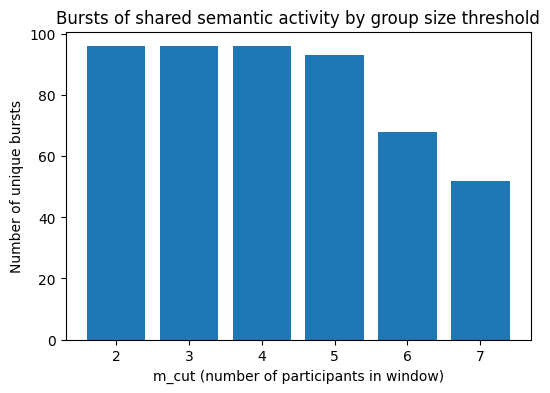

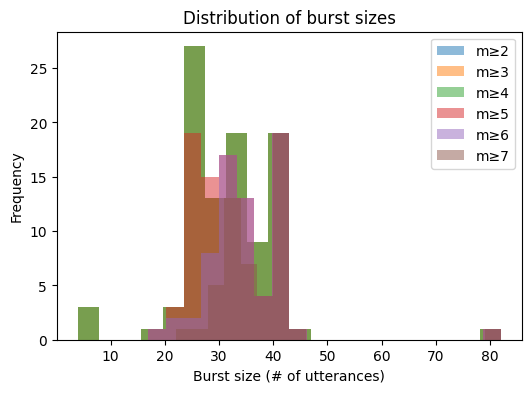

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# directory where your concordance files live
out_dir = Path("/Users/maxchalekson/Projects/NICO-Research/NICO_human-gemini/Data/scaling_outputs/summaries")

# load all decision_any_concordance_m*.csv files
concordance_files = sorted(out_dir.glob("decision_any_concordance_m*.csv"))

dfs = {}
for f in concordance_files:
    m_val = int(f.stem.split("_m")[-1])
    df = pd.read_csv(f)
    df["m_cut"] = m_val
    dfs[m_val] = df

# combine into one big dataframe
all_conc = pd.concat(dfs.values(), ignore_index=True)

print("Total rows across all m:", len(all_conc))
print(all_conc.head())

# --- Basic counts ---
summary = (
    all_conc.groupby("m_cut")
    .agg(
        bursts=("center_time_sec", "nunique"),
        sentences=("sentence", "count"),
        sessions=("session", "nunique")
    )
    .reset_index()
)

print("\nSummary by m_cut:\n", summary)

# --- Visualization: number of bursts per m_cut ---
plt.figure(figsize=(6,4))
plt.bar(summary["m_cut"], summary["bursts"])
plt.xlabel("m_cut (number of participants in window)")
plt.ylabel("Number of unique bursts")
plt.title("Bursts of shared semantic activity by group size threshold")
plt.show()

# --- Distribution of burst sizes ---
burst_sizes = (
    all_conc.groupby(["m_cut","conference","session","center_time_sec"])
    .size()
    .reset_index(name="burst_size")
)

plt.figure(figsize=(6,4))
for m_val, grp in burst_sizes.groupby("m_cut"):
    plt.hist(grp["burst_size"], bins=20, alpha=0.5, label=f"m≥{m_val}")
plt.xlabel("Burst size (# of utterances)")
plt.ylabel("Frequency")
plt.title("Distribution of burst sizes")
plt.legend()
plt.show()


             session  m_cut  bursts
0  2021_06_10_SLU_S1      2      38
1  2021_06_10_SLU_S1      3      38
2  2021_06_10_SLU_S1      4      38
3  2021_06_10_SLU_S1      5      38
4  2021_06_10_SLU_S1      6      38


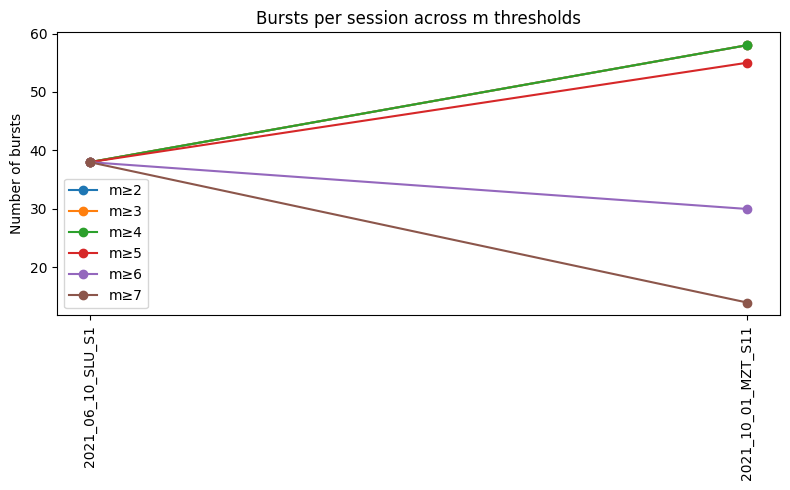


Average burst size per m_cut:
 m_cut
2    31.645833
3    31.645833
4    31.645833
5    32.516129
6    35.117647
7    36.692308
Name: burst_size, dtype: float64


In [2]:
# --- Burst counts per session for each m_cut ---
burst_counts = (
    all_conc.groupby(["session","m_cut"])
    .agg(bursts=("center_time_sec", "nunique"))
    .reset_index()
)

print(burst_counts.head())

# Plot burst counts per session by m_cut
plt.figure(figsize=(8,5))
for m_val, grp in burst_counts.groupby("m_cut"):
    plt.plot(grp["session"], grp["bursts"], marker='o', linestyle='-', label=f"m≥{m_val}")
plt.xticks(rotation=90)
plt.ylabel("Number of bursts")
plt.title("Bursts per session across m thresholds")
plt.legend()
plt.tight_layout()
plt.show()

# --- Average burst size per m_cut ---
burst_sizes = (
    all_conc.groupby(["m_cut","conference","session","center_time_sec"])
    .size()
    .reset_index(name="burst_size")
)

avg_burst_sizes = burst_sizes.groupby("m_cut")["burst_size"].mean()
print("\nAverage burst size per m_cut:\n", avg_burst_sizes)


In [6]:
# --- FIXED LOADER + SUMMARIES (drop-in replacement for the top half of your analysis cell) ---
from pathlib import Path
import pandas as pd, numpy as np, glob, re

DATA_DIR    = Path("/Users/maxchalekson/Projects/NICO-Research/NICO_human-gemini/Data")
SCALING_DIR = DATA_DIR / "scaling_outputs"
SUM_DIR     = SCALING_DIR / "summaries"

# 1) Load ALL concordance files and FORCE m_cut from filename
files = sorted(glob.glob(str(SUM_DIR / "decision_any_concordance_m*.csv")))
print("Found files:", [Path(f).name for f in files])
if not files:
    raise FileNotFoundError("No concordance CSVs found. Generate decision_any_concordance_m*.csv first.")

chunks = []
for f in files:
    tmp = pd.read_csv(f)
    # Force m_cut from filename robustly (e.g., decision_any_concordance_m5.csv -> 5)
    m_match = re.search(r"_m(\d+)\.csv$", Path(f).name)
    m_val = int(m_match.group(1)) if m_match else np.nan
    tmp["m_cut"] = m_val  # <- override regardless of what's inside the file
    tmp["source_file"] = Path(f).name

    # Backfill expected columns
    for c in ["speaker","annotations","sentence","sent_time_sec","center_time_sec","conference","session"]:
        if c not in tmp.columns: tmp[c] = np.nan

    chunks.append(tmp)

df_bursts = pd.concat(chunks, ignore_index=True)

# 2) Minimal cleaning
df_bursts["m_cut"] = df_bursts["m_cut"].astype(int)
df_bursts["center_time_sec"] = pd.to_numeric(df_bursts["center_time_sec"], errors="coerce")
df_bursts["sent_time_sec"]   = pd.to_numeric(df_bursts["sent_time_sec"], errors="coerce")

TEXT_COL = "sentence" if "sentence" in df_bursts.columns else ("transcript" if "transcript" in df_bursts.columns else None)
if TEXT_COL is None:
    df_bursts["sentence"] = ""
    TEXT_COL = "sentence"

print("Total rows across all m:", len(df_bursts))
print("Sessions covered:", df_bursts["session"].nunique(), "| m values:", sorted(df_bursts["m_cut"].unique()))
print("\nQuick check — rows per m:")
print(df_bursts["m_cut"].value_counts().sort_index())

# 3) === run the rest of your analysis exactly as before ===

# Speaker diversity per burst
burst_speaker_dist = (
    df_bursts.groupby(["session","m_cut","center_time_sec"])["speaker"]
    .nunique()
    .reset_index(name="unique_speakers")
)

# Decision mask (prefer your kw_* or decision_any if present)
if "decision_any" in df_bursts.columns:
    dec_mask = df_bursts["decision_any"].astype(bool)
elif any(c in df_bursts.columns for c in ["kw_decision","kw_assign","kw_summarize","kw_agree"]):
    cols = [c for c in ["kw_decision","kw_assign","kw_summarize","kw_agree"] if c in df_bursts.columns]
    dec_mask = df_bursts[cols].any(axis=1)
else:
    ann = df_bursts.get("annotations","").astype(str).str.lower()
    txt = df_bursts[TEXT_COL].astype(str).str.lower()
    dec_mask = (
        ann.str.contains("assign task|action item|decision|agree|consensus|summarize", regex=True) |
        txt.str.contains(r"\b(we should|let's|we will|we'll|we are going to|let us|decide|decided)\b", regex=True)
    )
df_bursts["decision_any_tmp"] = dec_mask

burst_dec_counts = (
    df_bursts.assign(decision_any=df_bursts["decision_any_tmp"].astype(bool))
             .groupby(["session","m_cut","center_time_sec"])["decision_any"]
             .sum()
             .reset_index(name="decision_hits")
)

burst_sizes = (
    df_bursts.groupby(["session","m_cut","center_time_sec"])
             .size()
             .reset_index(name="burst_size")
)

burst_summary = (burst_speaker_dist
                 .merge(burst_dec_counts, on=["session","m_cut","center_time_sec"], how="left")
                 .merge(burst_sizes,       on=["session","m_cut","center_time_sec"], how="left"))

burst_summary["decision_hits_per10"] = 10.0 * burst_summary["decision_hits"] / burst_summary["burst_size"].clip(lower=1)

def _role_from_ann(a):
    a = str(a).lower()
    if "assign task" in a or "action item" in a: return "assigner"
    if "summarize" in a: return "summarizer"
    if "agree" in a or "consensus" in a: return "agreer"
    if "present new idea" in a or "new idea" in a: return "ideator"
    if "expand on existing idea" in a: return "elaborator"
    if "explain" in a or "define" in a: return "explainer"
    return "other"

role_df = df_bursts[["session","m_cut","center_time_sec","annotations"]].copy()
role_df["role"] = role_df["annotations"].apply(_role_from_ann)
role_mix = (role_df.groupby(["m_cut","role"]).size().reset_index(name="count"))
role_mix["share"] = role_mix.groupby("m_cut")["count"].transform(lambda x: x / x.sum())

session_level = (
    burst_summary.groupby(["session","m_cut"])
    .agg(
        bursts=("center_time_sec","nunique"),
        avg_burst_size=("burst_size","mean"),
        avg_unique_speakers=("unique_speakers","mean"),
        total_decision_hits=("decision_hits","sum"),
        avg_decision_hits_per10=("decision_hits_per10","mean"),
    )
    .reset_index()
)

by_m = (
    burst_summary.groupby("m_cut")
    .agg(
        n_bursts=("center_time_sec","nunique"),
        avg_unique_speakers=("unique_speakers","mean"),
        med_unique_speakers=("unique_speakers","median"),
        avg_burst_size=("burst_size","mean"),
        med_burst_size=("burst_size","median"),
        avg_decisions_per10=("decision_hits_per10","mean"),
        med_decisions_per10=("decision_hits_per10","median"),
    )
    .reset_index()
)

OUT = SUM_DIR
OUT.mkdir(parents=True, exist_ok=True)
(burst_summary.to_csv(OUT/"burst_summary_per_burst.csv", index=False))
(session_level.to_csv(OUT/"burst_summary_per_session.csv", index=False))
(by_m.to_csv(OUT/"burst_summary_by_m.csv", index=False))
(role_mix.to_csv(OUT/"burst_role_mix_by_m.csv", index=False))

print("\n=== Headline: how m shifts burst properties ===")
print(by_m.round(2).to_string(index=False))

print("\n=== Top sessions by decision density (m pooled) ===")
print(session_level.sort_values("avg_decision_hits_per10", ascending=False).head(10).round(2).to_string(index=False))

print("\n=== Role mix inside bursts (share by m) ===")
print(role_mix.sort_values(["m_cut","share"], ascending=[True,False]).round(3).to_string(index=False))

largest = (burst_summary.sort_values(["unique_speakers","burst_size"], ascending=[False,False]).head(8))
print("\n=== Example: largest multi‑speaker bursts ===")
print(largest[["session","m_cut","center_time_sec","unique_speakers","burst_size","decision_hits","decision_hits_per10"]]
      .round(2).to_string(index=False))


Found files: ['decision_any_concordance_m2.csv', 'decision_any_concordance_m3.csv', 'decision_any_concordance_m4.csv', 'decision_any_concordance_m5.csv', 'decision_any_concordance_m6.csv', 'decision_any_concordance_m7.csv']
Total rows across all m: 16434
Sessions covered: 2 | m values: [2, 3, 4, 5, 6, 7]

Quick check — rows per m:
m_cut
2    3038
3    3038
4    3038
5    3024
6    2388
7    1908
Name: count, dtype: int64

=== Headline: how m shifts burst properties ===
 m_cut  n_bursts  avg_unique_speakers  med_unique_speakers  avg_burst_size  med_burst_size  avg_decisions_per10  med_decisions_per10
     2        96                 6.57                  6.0           31.65            32.0                 4.14                 4.00
     3        96                 6.57                  6.0           31.65            32.0                 4.14                 4.00
     4        96                 6.57                  6.0           31.65            32.0                 4.14                

### an extra plot

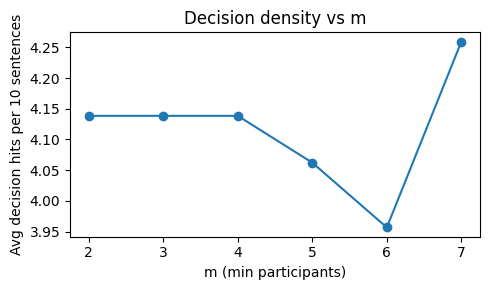

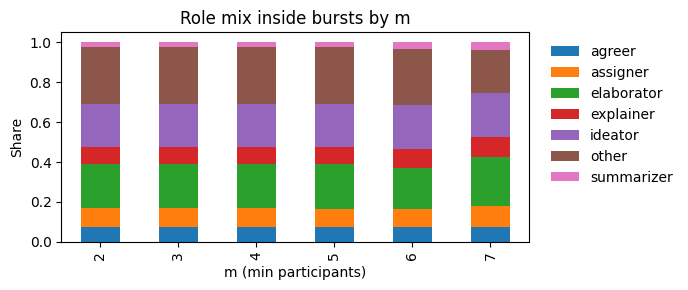

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

DATA_DIR = Path("/Users/maxchalekson/Projects/NICO-Research/NICO_human-gemini/Data")
SUM_DIR  = DATA_DIR / "scaling_outputs" / "summaries"

by_m = pd.read_csv(SUM_DIR / "burst_summary_by_m.csv")
role = pd.read_csv(SUM_DIR / "burst_role_mix_by_m.csv")

# 1) m vs decision density
plt.figure(figsize=(5,3))
plt.plot(by_m["m_cut"], by_m["avg_decisions_per10"], marker="o")
plt.xlabel("m (min participants)")
plt.ylabel("Avg decision hits per 10 sentences")
plt.title("Decision density vs m")
plt.tight_layout()
plt.show()

# 2) stacked role share by m
pivot = role.pivot(index="m_cut", columns="role", values="share").fillna(0).sort_index()
pivot.plot(kind="bar", stacked=True, figsize=(7,3))
plt.xlabel("m (min participants)")
plt.ylabel("Share")
plt.title("Role mix inside bursts by m")
plt.legend(bbox_to_anchor=(1.02,1), loc="upper left", frameon=False)
plt.tight_layout()
plt.show()


Right now, this is across 2 sessions. Need to scale up to 83 sessions.

Regenerating annot_v2

In [11]:
import pandas as pd
from pathlib import Path

# Load full utterance data
utter_path = Path("/Users/maxchalekson/Projects/NICO-Research/NICO_human-gemini/Data/utterance_data_aligned_full.csv")
df = pd.read_csv(utter_path)

print("Sessions in utterance file:", df["session"].nunique())

# --- Burst construction parameters ---
window_gap = 20.0  # silence threshold (sec)
min_burst_len = 2

all_bursts = []

for session, sub in df.groupby("session"):
    sub = sub.sort_values("start_sec_adjusted")
    
    burst_id = 0
    last_end = None
    
    for _, row in sub.iterrows():
        if last_end is None or (row["start_sec_adjusted"] - last_end) > window_gap:
            burst_id += 1  # new burst
        row_out = row.to_dict()
        row_out["burst_id"] = f"{session}_B{burst_id}"  # make IDs session-specific
        all_bursts.append(row_out)
        last_end = row["end_sec_adjusted"]

df_bursts = pd.DataFrame(all_bursts)

print("Total bursts:", df_bursts["burst_id"].nunique())
print("Sessions covered:", df_bursts["session"].nunique())

# Save
out_path = Path("/Users/maxchalekson/Projects/NICO-Research/NICO_human-gemini/Data/bursts_all_sessions_annot_v2.csv")
df_bursts.to_csv(out_path, index=False)
print("Saved full bursts file:", out_path)


Sessions in utterance file: 82
Total bursts: 105
Sessions covered: 82
Saved full bursts file: /Users/maxchalekson/Projects/NICO-Research/NICO_human-gemini/Data/bursts_all_sessions_annot_v2.csv


## now working with all 82

In [20]:
# === Robust loader/normalizer + derive burst centers + participants & concordance (ALL SESSIONS) ===
from pathlib import Path
import pandas as pd
import numpy as np

# -------- Paths --------
DATA_DIR    = Path("/Users/maxchalekson/Projects/NICO-Research/NICO_human-gemini/Data")
SCALING_DIR = DATA_DIR / "scaling_outputs"
SUM_DIR     = SCALING_DIR / "summaries"
SUM_DIR.mkdir(parents=True, exist_ok=True)

# Your all‑sessions utterance file
SENTS_ALL   = DATA_DIR / "utterance_data_aligned_full.csv"
# All‑sessions bursts/annotations you just rebuilt (row-level, includes burst_id + time cols)
ANNOT_V2    = DATA_DIR / "bursts_all_sessions_annot_v2.csv"

# -------- Load raw files --------
sents_raw = pd.read_csv(SENTS_ALL)
annot     = pd.read_csv(ANNOT_V2)

# -------- Normalize utterance schema -> canonical columns --------
def normalize_sents(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    # --- session id ---
    if "session" not in df.columns:
        cand_conf = [c for c in df.columns if c.lower() in ("conference","conf","meeting")]
        cand_sess = [c for c in df.columns if c.lower() in ("session_id","sessionname","sess","session_name")]
        if cand_conf and cand_sess:
            df["session"] = df[cand_conf[0]].astype(str).str.strip() + "_" + df[cand_sess[0]].astype(str).str.strip()
        elif cand_conf:
            df["session"] = df[cand_conf[0]].astype(str).str.strip()
        else:
            raise ValueError("Could not find or construct a 'session' column.")

    # --- conference ---
    if "conference" not in df.columns:
        def _conf_from_session(s):
            s = str(s); parts = s.split("_")
            return "_".join(parts[:-1]) if len(parts) >= 2 else s
        df["conference"] = df["session"].map(_conf_from_session)

    # --- time column -> sent_time_sec ---
    if "sent_time_sec" in df.columns:
        df["sent_time_sec"] = pd.to_numeric(df["sent_time_sec"], errors="coerce").astype(float)
    else:
        time_cols_sec = [c for c in df.columns if c in ("time_sec","utterance_time_sec","start_time_sec","relative_time_sec")]
        time_cols_ms  = [c for c in df.columns if c in ("start_ms","time_ms","timestamp_ms")]
        time_cols_gen = [c for c in df.columns if c in ("start_time","time","t","timestamp")]
        if time_cols_sec:
            df["sent_time_sec"] = pd.to_numeric(df[time_cols_sec[0]], errors="coerce").astype(float)
        elif time_cols_ms:
            df["sent_time_sec"] = pd.to_numeric(df[time_cols_ms[0]], errors="coerce")/1000.0
        elif time_cols_gen:
            df["sent_time_sec"] = pd.to_numeric(df[time_cols_gen[0]], errors="coerce").astype(float)
        else:
            raise ValueError("Could not find a time column to create 'sent_time_sec'.")

    # --- speaker ---
    if "speaker" in df.columns:
        df["speaker"] = df["speaker"].astype(str)
    else:
        speaker_cols = [c for c in df.columns if c.lower() in ("speaker_name","participant","who","name")]
        df["speaker"] = df[speaker_cols[0]].astype(str) if speaker_cols else ""

    # --- text -> sentence ---
    if "sentence" in df.columns:
        df["sentence"] = df["sentence"].astype(str)
    else:
        text_cols = [c for c in df.columns if c.lower() in ("utterance","transcript","text","content")]
        df["sentence"] = df[text_cols[0]].astype(str) if text_cols else ""

    # --- annotations (optional) ---
    if "annotations" not in df.columns:
        ann_cols = [c for c in df.columns if c.lower() in ("annotations","labels","tags")]
        df["annotations"] = df[ann_cols[0]] if ann_cols else ""

    keep = ["conference","session","sent_time_sec","speaker","sentence","annotations"]
    return df[keep].copy()

sents = normalize_sents(sents_raw)

print("Normalized sents columns:", list(sents.columns))
print("Sessions in utterances:", sents["session"].nunique(), "| Example session:", sents["session"].iloc[0])

# -------- Session index for fast window ops --------
session_index = {(c, s): g.sort_values("sent_time_sec").reset_index(drop=True)
                 for (c, s), g in sents.groupby(["conference","session"], dropna=False)}

# -------- Helpers --------
def participants_in_window(conf: str, sess: str, center_t: float, half_width: float=20.0) -> int:
    key = (conf, sess)
    if key not in session_index: return 0
    S = session_index[key]
    m = S["sent_time_sec"].between(center_t-half_width, center_t+half_width)
    if not m.any(): return 0
    spk = S.loc[m, "speaker"].dropna().astype(str).str.strip()
    return int(spk.nunique())

def mark_sentences_in_windows(bursts_df: pd.DataFrame, half_width: float=20.0) -> pd.Series:
    mark = pd.Series(False, index=sents.index)
    for (conf, sess), grp in bursts_df.groupby(["conference","session"]):
        key = (conf, sess)
        if key not in session_index: 
            continue
        S = session_index[key]
        for ct in grp["center_time_sec"].astype(float):
            m = S["sent_time_sec"].between(ct-half_width, ct+half_width)
            if m.any():
                mark.loc[S.index[m]] = True
    return mark

# -------- Build simple keyword flags (no regex pitfalls) --------
def kw_contains(series: pd.Series, phrases) -> pd.Series:
    text = series.fillna("").str.lower()
    mask = pd.Series(False, index=text.index)
    for p in phrases:
        mask |= text.str.contains(p, regex=False)  # IMPORTANT: regex=False
    return mask

KW_DECISION  = ["we should", "let's ", "lets ", "we will", "we'll", "we are going to", "we’re going to", "decide"]
KW_ASSIGN    = ["can you ", "you will", "you’ll", "you'll", "i will", "i’ll", "i'll", "take the lead", "assign", "action item"]
KW_SUMMARIZE = ["in summary", "to sum up", "recap"]
KW_AGREE     = ["i agree", "sounds good", "sgtm", "works for me", "that works", "yes", "yep", "okay", "ok "]

sents["kw_decision"]  = kw_contains(sents["sentence"], KW_DECISION)  | kw_contains(sents["annotations"].astype(str), KW_DECISION)
sents["kw_assign"]    = kw_contains(sents["sentence"], KW_ASSIGN)    | kw_contains(sents["annotations"].astype(str), KW_ASSIGN)
sents["kw_summarize"] = kw_contains(sents["sentence"], KW_SUMMARIZE) | kw_contains(sents["annotations"].astype(str), KW_SUMMARIZE)
sents["kw_agree"]     = kw_contains(sents["sentence"], KW_AGREE)     | kw_contains(sents["annotations"].astype(str), KW_AGREE)
sents["decision_any"] = sents[["kw_decision","kw_assign","kw_summarize","kw_agree"]].any(axis=1)

print("\nCounts of True flags (keyword-based, all sessions):")
for c in ["kw_decision","kw_assign","kw_summarize","kw_agree","decision_any"]:
    print(f"  {c:<13} -> {int(sents[c].sum())}")

# -------- Derive burst centers from annot_v2 (no center_time_sec in file) --------
for must in ["conference","session","burst_id"]:
    if must not in annot.columns:
        raise ValueError(f"Annot file needs '{must}' column. Found: {list(annot.columns)}")

A = annot.copy()

# Pick best available time columns to form a row-level center
if {"start_sec_adjusted","end_sec_adjusted"}.issubset(A.columns):
    start = pd.to_numeric(A["start_sec_adjusted"], errors="coerce")
    end   = pd.to_numeric(A["end_sec_adjusted"], errors="coerce")
    row_center = (start + end) / 2.0
elif {"start_sec","end_sec"}.issubset(A.columns):
    start = pd.to_numeric(A["start_sec"], errors="coerce")
    end   = pd.to_numeric(A["end_sec"], errors="coerce")
    row_center = (start + end) / 2.0
elif "global_timestamp_sec" in A.columns:
    row_center = pd.to_numeric(A["global_timestamp_sec"], errors="coerce")
elif "timestamp" in A.columns:
    row_center = pd.to_numeric(A["timestamp"], errors="coerce")
else:
    raise ValueError(
        "Could not find usable time columns in annot_v2. "
        "Looked for start_sec_adjusted/end_sec_adjusted, start_sec/end_sec, global_timestamp_sec, timestamp."
    )

A["row_center_sec"] = row_center

# Collapse to one center per (conference, session, burst_id) — median is robust
bursts_true = (
    A.groupby(["conference","session","burst_id"], dropna=False)["row_center_sec"]
     .median()
     .reset_index()
     .rename(columns={"row_center_sec":"center_time_sec"})
     .dropna(subset=["center_time_sec"])
)

# Clean types
bursts_true["conference"]      = bursts_true["conference"].astype(str)
bursts_true["session"]         = bursts_true["session"].astype(str)
bursts_true["burst_id"]        = bursts_true["burst_id"].astype(str)
bursts_true["center_time_sec"] = bursts_true["center_time_sec"].astype(float)

print(f"\nDerived {len(bursts_true)} burst centers across {bursts_true['session'].nunique()} sessions.")
print(bursts_true.head())

# -------- Recompute participants per burst and write concordances for m=2..7 --------
W = 20.0
print(f"\nRecomputing participants per burst in ±{W:.1f}s windows across ALL sessions...")
bursts_true["participants_in_window"] = [
    participants_in_window(r.conference, r.session, float(r.center_time_sec), W)
    for _, r in bursts_true.iterrows()
]

# thresholds to evaluate (cap at 7 as before)
max_m = int(min(max([2] + bursts_true["participants_in_window"].tolist()), 7))
m_vals = list(range(2, max_m+1))
print("m thresholds to evaluate:", m_vals)

summary_rows = []
for m in m_vals:
    eligible = bursts_true[bursts_true["participants_in_window"] >= m]
    in_mask  = mark_sentences_in_windows(eligible, half_width=W)
    inside   = sents.loc[in_mask].copy()
    inside["m_cut"] = m

    # decision hits inside windows
    dec_hits = int(inside["decision_any"].sum())
    sessions_covered = inside["session"].nunique()

    # write per‑m concordance
    out_csv = SUM_DIR / f"decision_any_concordance_m{m}.csv"
    cols_to_keep = ["conference","session","sent_time_sec","center_time_sec","speaker","sentence","annotations",
                    "kw_decision","kw_assign","kw_summarize","kw_agree","decision_any","m_cut"]
    inside["center_time_sec"] = np.nan  # per-sentence center not stored; windows defined from burst centers
    for c in cols_to_keep:
        if c not in inside.columns: inside[c] = np.nan
    inside[cols_to_keep].to_csv(out_csv, index=False)

    summary_rows.append({
        "m_cut": m,
        "eligible_windows": len(eligible),
        "sentences_in_windows": int(in_mask.sum()),
        "decision_hits_in_windows": dec_hits,
        "sessions_covered": sessions_covered,
        "rows_written": len(inside),
        "outfile": str(out_csv)
    })
    print(f"[m≥{m}] wrote {out_csv.name} | windows={len(eligible)} | rows={len(inside)} | decision_hits={dec_hits} | sessions={sessions_covered}")

summary = pd.DataFrame(summary_rows)
sum_csv = SUM_DIR / "decision_any_concordance_summary_ALLSESS.csv"
summary.to_csv(sum_csv, index=False)
print("\n=== Summary across ALL sessions ===")
print(summary.to_string(index=False))
print("Saved summary:", sum_csv)

Normalized sents columns: ['conference', 'session', 'sent_time_sec', 'speaker', 'sentence', 'annotations']
Sessions in utterances: 82 | Example session: 2021_04_22_MND_S5

Counts of True flags (keyword-based, all sessions):
  kw_decision   -> 721
  kw_assign     -> 1413
  kw_summarize  -> 17
  kw_agree      -> 2829
  decision_any  -> 4329

Derived 105 burst centers across 82 sessions.
          conference            session              burst_id  center_time_sec
0  2021_04_22_MND_S1  2021_04_22_MND_S1  2021_04_22_MND_S1_B1           258.25
1  2021_04_22_MND_S2  2021_04_22_MND_S2  2021_04_22_MND_S2_B1           601.50
2  2021_04_22_MND_S3  2021_04_22_MND_S3  2021_04_22_MND_S3_B1           269.75
3  2021_04_22_MND_S4  2021_04_22_MND_S4  2021_04_22_MND_S4_B1           868.50
4  2021_04_22_MND_S5  2021_04_22_MND_S5  2021_04_22_MND_S5_B1           870.50

Recomputing participants per burst in ±20.0s windows across ALL sessions...
m thresholds to evaluate: [2]
[m≥2] wrote decision_any_concor

In [ ]:
# === BUILD: participants per burst + per‑m concordance (centers aligned) ===
from pathlib import Path
import pandas as pd
import numpy as np

# Reuse sents, centers from previous cell
assert set(["conference","session","sent_time_sec","speaker","sentence","annotations"]).issubset(sents.columns)
assert set(["conference","session","burst_id","center_time_sec"]).issubset(centers.columns)

DATA_DIR = Path("/Users/maxchalekson/Projects/NICO-Research/NICO_human-gemini/Data")
SUM_DIR  = DATA_DIR / "scaling_outputs" / "summaries"
SUM_DIR.mkdir(parents=True, exist_ok=True)

W = 20.0  # half‑window in seconds (±W)

# --- 0) Fast per‑session index
session_index = {
    s: g.sort_values("sent_time_sec").reset_index(drop=True)
    for s, g in sents.groupby("session", dropna=False)
}

# --- 1) Participants in each center window (±W)
def participants_in_window_session(sess_df: pd.DataFrame, center_t: float, half=W) -> int:
    if sess_df.empty:
        return 0
    m = sess_df["sent_time_sec"].between(center_t - half, center_t + half)
    if not m.any():
        return 0
    return int(sess_df.loc[m, "speaker"].dropna().astype(str).str.strip().nunique())

centers = centers.copy()
centers["center_time_sec"] = pd.to_numeric(centers["center_time_sec"], errors="coerce")
centers["participants_in_window"] = centers.apply(
    lambda r: participants_in_window_session(
        session_index.get(r["session"], pd.DataFrame(columns=sents.columns)),
        float(r["center_time_sec"]), W
    ),
    axis=1
)

print("Participants per center (preview):")
print(centers.head())

# --- 2) Attach each sentence to the NEAREST eligible center in the same session (if within ±W)
def attach_nearest_center_in_session(sess_df: pd.DataFrame, center_list: np.ndarray, half=W):
    """Return DF with 'center_time_sec' + 'delta_to_center' for sentences within ±W of a center."""
    if len(sess_df) == 0 or len(center_list) == 0:
        return pd.DataFrame(columns=list(sess_df.columns) + ["center_time_sec", "delta_to_center"])

    t = sess_df["sent_time_sec"].to_numpy(dtype=float)
    C = np.array(center_list, dtype=float)
    out_rows = []
    for i, ti in enumerate(t):
        j = int(np.argmin(np.abs(C - ti)))
        delta = ti - C[j]
        if abs(delta) <= half:
            row = sess_df.iloc[i].to_dict()
            row["center_time_sec"] = float(C[j])
            row["delta_to_center"] = float(delta)
            out_rows.append(row)

    if not out_rows:
        return pd.DataFrame(columns=list(sess_df.columns) + ["center_time_sec", "delta_to_center"])

    out = pd.DataFrame(out_rows)
    out["center_time_sec"] = pd.to_numeric(out["center_time_sec"], errors="coerce").astype(float)
    out["delta_to_center"] = pd.to_numeric(out["delta_to_center"], errors="coerce").astype(float)
    return out

# Build a base mapping of sentences to centers (ignores m for now)
mapped_chunks = []
for sess, g in sents.groupby("session", dropna=False):
    C = centers.loc[centers["session"] == sess, "center_time_sec"].to_numpy()
    mapped = attach_nearest_center_in_session(g, C, half=W)
    if len(mapped):
        mapped_chunks.append(mapped)

if not mapped_chunks:
    raise RuntimeError("No sentences fell within ±W of any center. Check W or centers.")

mapped_all = pd.concat(mapped_chunks, ignore_index=True)

# Ensure 'conference' is present on mapped_all (join back by session+sent_time_sec)
if "conference" not in mapped_all.columns:
    mapped_all = mapped_all.merge(
        sents[["session","sent_time_sec","conference"]],
        on=["session","sent_time_sec"],
        how="left"
    )

# --- 3) Keyword flags (lightweight, no regex pitfalls)
def kw_contains(series: pd.Series, phrases) -> pd.Series:
    text = series.fillna("").str.lower()
    mask = pd.Series(False, index=text.index)
    for p in phrases:
        mask |= text.str.contains(p, regex=False)
    return mask

KW_DECISION  = ["we should", "let's ", "lets ", "we will", "we'll", "we are going to", "we’re going to", "decide"]
KW_ASSIGN    = ["can you ", "you will", "you’ll", "you'll", "i will", "i’ll", "i'll", "take the lead", "assign", "action item"]
KW_SUMMARIZE = ["in summary", "to sum up", "recap"]
KW_AGREE     = ["i agree", "sounds good", "sgtm", "works for me", "that works", "yes", "yep", "okay", "ok "]

mapped_all["kw_decision"]  = kw_contains(mapped_all["sentence"], KW_DECISION)  | kw_contains(mapped_all["annotations"].astype(str), KW_DECISION)
mapped_all["kw_assign"]    = kw_contains(mapped_all["sentence"], KW_ASSIGN)    | kw_contains(mapped_all["annotations"].astype(str), KW_ASSIGN)
mapped_all["kw_summarize"] = kw_contains(mapped_all["sentence"], KW_SUMMARIZE) | kw_contains(mapped_all["annotations"].astype(str), KW_SUMMARIZE)
mapped_all["kw_agree"]     = kw_contains(mapped_all["sentence"], KW_AGREE)     | kw_contains(mapped_all["annotations"].astype(str), KW_AGREE)
mapped_all["decision_any"] = mapped_all[["kw_decision","kw_assign","kw_summarize","kw_agree"]].any(axis=1)

print("\nCounts of True flags inside any ±W window (pre‑m):")
for c in ["kw_decision","kw_assign","kw_summarize","kw_agree","decision_any"]:
    print(f"  {c:<13} -> {int(mapped_all[c].sum())}")

# --- 4) Build concordance packs for m = 2..7 (using actual per-center participant counts)
summary_rows = []
for m in range(2, 8):
    eligible_centers = centers.loc[
        centers["participants_in_window"] >= m,
        ["conference","session","burst_id","center_time_sec"]
    ]
    out_csv = SUM_DIR / f"decision_any_concordance_m{m}.csv"

    if eligible_centers.empty:
        pd.DataFrame(columns=[
            "conference","session","sent_time_sec","center_time_sec","burst_id","speaker","sentence","annotations",
            "kw_decision","kw_assign","kw_summarize","kw_agree","decision_any","m_cut","delta_to_center"
        ]).to_csv(out_csv, index=False)
        summary_rows.append({
            "m_cut": m, "eligible_centers": 0, "rows_written": 0,
            "decision_hits": 0, "sessions_covered": 0, "outfile": str(out_csv)
        })
        print(f"[m≥{m}] wrote {out_csv.name} | centers=0 | rows=0 | decision_hits=0 | sessions=0")
        continue

    # Join sentences-with-center to eligible centers (same session & center_time_sec)
    join_keys = ["session","center_time_sec"]
    inside = mapped_all.merge(
        eligible_centers[join_keys + ["burst_id","conference"]],
        on=join_keys, how="inner"
    )
    inside["m_cut"] = m

    # --- FIX: coalesce to a single 'conference' column after merge ---
    if "conference" not in inside.columns or "conference_x" in inside.columns or "conference_y" in inside.columns:
        cx = inside.get("conference_x")
        cy = inside.get("conference_y")
        if cy is not None and cx is not None:
            inside["conference"] = cy.fillna(cx)
        elif cy is not None:
            inside["conference"] = cy
        elif cx is not None:
            inside["conference"] = cx
        else:
            # last resort: map from session
            sess2conf = sents[["session","conference"]].drop_duplicates("session")
            inside = inside.merge(sess2conf, on="session", how="left")
        for col in ["conference_x","conference_y"]:
            if col in inside.columns:
                inside.drop(columns=col, inplace=True)

    # Save
    cols_to_keep = [
        "conference","session","sent_time_sec","center_time_sec","burst_id","speaker","sentence","annotations",
        "kw_decision","kw_assign","kw_summarize","kw_agree","decision_any","m_cut","delta_to_center"
    ]
    missing = [c for c in cols_to_keep if c not in inside.columns]
    if missing:
        print("WARNING: Missing columns in output, will fill with NaN:", missing)
        for c in missing:
            inside[c] = np.nan

    inside[cols_to_keep].sort_values(
        ["session","center_time_sec","sent_time_sec"]
    ).to_csv(out_csv, index=False)

    summary_rows.append({
        "m_cut": m,
        "eligible_centers": len(eligible_centers),
        "rows_written": len(inside),
        "decision_hits": int(inside["decision_any"].sum()),
        "sessions_covered": inside["session"].nunique(),
        "outfile": str(out_csv)
    })
    print(f"[m≥{m}] wrote {out_csv.name} | centers={len(eligible_centers)} | rows={len(inside)} | "
          f"decision_hits={int(inside['decision_any'].sum())} | sessions={inside['session'].nunique()}")

summary = pd.DataFrame(summary_rows)
sum_csv = SUM_DIR / "decision_any_concordance_summary_ALLSESS.csv"
summary.to_csv(sum_csv, index=False)

print("\n=== Summary across ALL sessions ===")
print(summary.to_string(index=False))
print("Saved summary:", sum_csv)

# --- 5) Tiny slide‑ready headline (optional)
by_m = (
    summary
    .assign(decisions_per_1000=lambda d: 1000 * d["decision_hits"] / d["rows_written"].clip(lower=1))
    [["m_cut","eligible_centers","rows_written","decision_hits","decisions_per_1000"]]
    .round(2)
)
print("\nSlide‑ready table:")
print(by_m.to_string(index=False))

Participants per center (preview):
          conference            session              burst_id  \
0  2021_04_22_MND_S1  2021_04_22_MND_S1  2021_04_22_MND_S1_B1   
1  2021_04_22_MND_S2  2021_04_22_MND_S2  2021_04_22_MND_S2_B1   
2  2021_04_22_MND_S3  2021_04_22_MND_S3  2021_04_22_MND_S3_B1   
3  2021_04_22_MND_S4  2021_04_22_MND_S4  2021_04_22_MND_S4_B1   
4  2021_04_22_MND_S5  2021_04_22_MND_S5  2021_04_22_MND_S5_B1   

   center_time_sec  participants_in_window  
0            251.0                       6  
1            599.0                       1  
2            259.0                       6  
3            861.0                       9  
4            857.0                      16  

Counts of True flags inside any ±W window (pre‑m):
  kw_decision   -> 59
  kw_assign     -> 122
  kw_summarize  -> 0
  kw_agree      -> 278
  decision_any  -> 420
[m≥2] wrote decision_any_concordance_m2.csv | centers=97 | rows=1616 | decision_hits=419 | sessions=81
[m≥3] wrote decision_any_concordance_

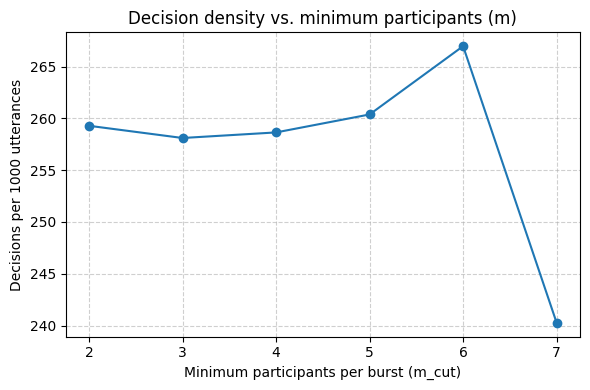

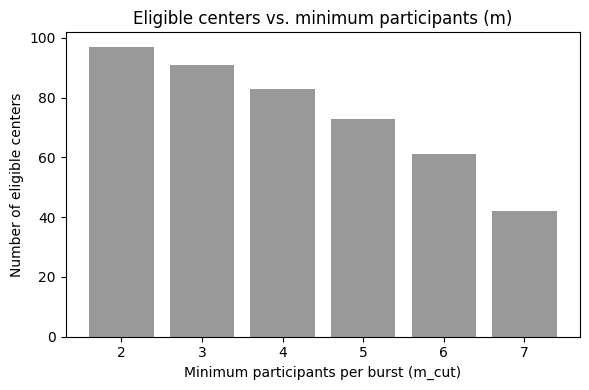

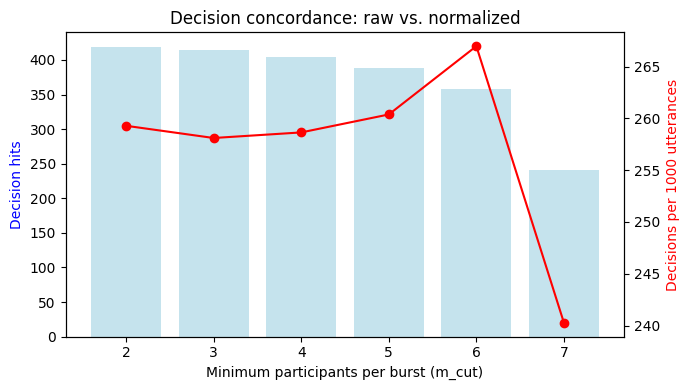

In [30]:
# === PLOTTING: summary curves for decision concordance ===
import matplotlib.pyplot as plt
import pandas as pd

# Load the summary file
sum_csv = SUM_DIR / "decision_any_concordance_summary_ALLSESS.csv"
summary = pd.read_csv(sum_csv)

# Add derived metric: decisions per 1000 utterances
summary["decisions_per_1000"] = (
    1000 * summary["decision_hits"] / summary["rows_written"].clip(lower=1)
)

# --- 1) Line plot: decision density vs. m_cut ---
plt.figure(figsize=(6,4))
plt.plot(summary["m_cut"], summary["decisions_per_1000"], marker="o")
plt.title("Decision density vs. minimum participants (m)")
plt.xlabel("Minimum participants per burst (m_cut)")
plt.ylabel("Decisions per 1000 utterances")
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

# --- 2) Bar plot: eligible centers vs. m_cut ---
plt.figure(figsize=(6,4))
plt.bar(summary["m_cut"], summary["eligible_centers"], color="gray", alpha=0.8)
plt.title("Eligible centers vs. minimum participants (m)")
plt.xlabel("Minimum participants per burst (m_cut)")
plt.ylabel("Number of eligible centers")
plt.tight_layout()
plt.show()

# --- 3) Combo plot: decision density + raw decision hits ---
fig, ax1 = plt.subplots(figsize=(7,4))

# Bars: raw decision hits
ax1.bar(summary["m_cut"], summary["decision_hits"], color="lightblue", alpha=0.7, label="Decision hits")
ax1.set_xlabel("Minimum participants per burst (m_cut)")
ax1.set_ylabel("Decision hits", color="blue")

# Line: decisions per 1000
ax2 = ax1.twinx()
ax2.plot(summary["m_cut"], summary["decisions_per_1000"], marker="o", color="red", label="Decisions per 1000")
ax2.set_ylabel("Decisions per 1000 utterances", color="red")

plt.title("Decision concordance: raw vs. normalized")
fig.tight_layout()
plt.show()

Saved per-track summary: /Users/maxchalekson/Projects/NICO-Research/NICO_human-gemini/Data/scaling_outputs/summaries/by_track_m_summary.csv
Saved best-m-per-track table: /Users/maxchalekson/Projects/NICO-Research/NICO_human-gemini/Data/scaling_outputs/summaries/by_track_best_m.csv
track  m_cut  decisions_per_1000  centers  rows_written  sessions
  ABI      6              277.53       18           454        19
  MND      6              345.39       14           304        14
  MZT      6              257.14        9           175         9
  SLU      2              201.81       23           441        20
Saved plot: /Users/maxchalekson/Projects/NICO-Research/NICO_human-gemini/Data/scaling_outputs/summaries/by_track_density.png
Saved coverage (centers by m x track): /Users/maxchalekson/Projects/NICO-Research/NICO_human-gemini/Data/scaling_outputs/summaries/coverage_centers_by_m_track.csv
Saved top sessions at m=6: /Users/maxchalekson/Projects/NICO-Research/NICO_human-gemini/Data/scaling

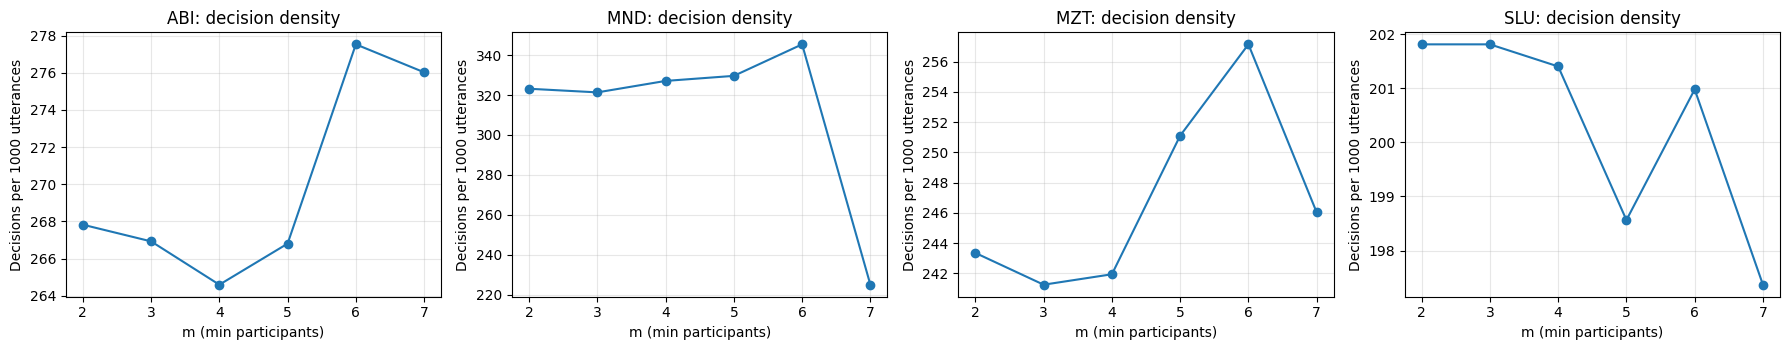

In [31]:
# === PER-TRACK DIAGNOSTICS & SLIDE-READY EXPORTS ===
from pathlib import Path
import pandas as pd
import numpy as np
import glob
import matplotlib.pyplot as plt

DATA_DIR = Path("/Users/maxchalekson/Projects/NICO-Research/NICO_human-gemini/Data")
SUM_DIR  = DATA_DIR / "scaling_outputs" / "summaries"

# Load all concordance files (already include 'conference' + 'session' + 'm_cut')
files = sorted(glob.glob(str(SUM_DIR / "decision_any_concordance_m*.csv")))
if not files:
    raise FileNotFoundError("No concordance CSVs found. Run the previous build step first.")

df = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)

# Light cleaning
for c in ["m_cut", "sent_time_sec", "center_time_sec"]:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

# Derive a compact track code from 'session' (e.g., 2021_05_21_ABI_S15 -> ABI)
def infer_track_from_session(s):
    s = str(s)
    parts = s.split("_")
    # common patterns: YYYY_MM_DD_TRACK_S#
    # fallback: look for one of known tags
    for p in parts:
        if p in {"ABI","MND","SLU","MZT"}:
            return p
    return "UNK"

df["track"] = df["session"].apply(infer_track_from_session)

# --- 1) Aggregate by track & m ---
agg_by_track = (
    df.groupby(["track","m_cut"])
      .agg(
          rows_written=("sentence","size"),
          decision_hits=("decision_any","sum"),
          centers=("center_time_sec","nunique"),
          sessions=("session","nunique"),
      )
      .reset_index()
)

agg_by_track["decisions_per_1000"] = 1000 * agg_by_track["decision_hits"] / agg_by_track["rows_written"].clip(lower=1)

# Save slide-ready table
out_csv = SUM_DIR / "by_track_m_summary.csv"
agg_by_track.sort_values(["track","m_cut"]).round(2).to_csv(out_csv, index=False)
print("Saved per-track summary:", out_csv)

# --- 2) Quick headline table for slide: each track's best m (max density) ---
best_m_per_track = (
    agg_by_track.loc[agg_by_track.groupby("track")["decisions_per_1000"].idxmax()]
    .sort_values("track")
    [["track","m_cut","decisions_per_1000","centers","rows_written","sessions"]]
    .round(2)
)
best_csv = SUM_DIR / "by_track_best_m.csv"
best_m_per_track.to_csv(best_csv, index=False)
print("Saved best-m-per-track table:", best_csv)
print(best_m_per_track.to_string(index=False))

# --- 3) Plot: density vs m by track (small multiples) ---
tracks = sorted(agg_by_track["track"].unique())
n = len(tracks)
cols = min(n, 4)
rows = int(np.ceil(n / cols))

plt.figure(figsize=(4.5*cols, 3.6*rows))
for i, tr in enumerate(tracks, 1):
    ax = plt.subplot(rows, cols, i)
    sub = agg_by_track[agg_by_track["track"] == tr].sort_values("m_cut")
    ax.plot(sub["m_cut"], sub["decisions_per_1000"], marker="o")
    ax.set_title(f"{tr}: decision density")
    ax.set_xlabel("m (min participants)")
    ax.set_ylabel("Decisions per 1000 utterances")
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(SUM_DIR / "by_track_density.png", dpi=160, bbox_inches="tight")
print("Saved plot:", SUM_DIR / "by_track_density.png")

# --- 4) Bonus: table for the slide that Matt will ask for (coverage) ---
coverage = (
    agg_by_track
    .pivot(index="m_cut", columns="track", values="centers")
    .fillna(0)
    .astype(int)
    .reset_index()
    .sort_values("m_cut")
)
cov_csv = SUM_DIR / "coverage_centers_by_m_track.csv"
coverage.to_csv(cov_csv, index=False)
print("Saved coverage (centers by m x track):", cov_csv)

# --- 5) Optional: top sessions at m=6 (if that peak holds) ---
if (agg_by_track.groupby("m_cut")["decisions_per_1000"].mean().idxmax() == 6) and (6 in df["m_cut"].unique()):
    top_sess_m6 = (
        df[df["m_cut"] == 6]
        .groupby(["session","track"])
        .agg(
            rows=("sentence","size"),
            decision_hits=("decision_any","sum"),
            centers=("center_time_sec","nunique")
        )
        .assign(decisions_per_1000=lambda x: 1000 * x["decision_hits"] / x["rows"].clip(lower=1))
        .sort_values("decisions_per_1000", ascending=False)
        .head(12)
        .round(2)
        .reset_index()
    )
    top_csv = SUM_DIR / "top_sessions_m6.csv"
    top_sess_m6.to_csv(top_csv, index=False)
    print("Saved top sessions at m=6:", top_csv)
    print(top_sess_m6.to_string(index=False))
else:
    print("Note: m=6 is not the global peak in this slice, so skipping the m=6 top-session table.")

## post-first draft slidedeck code

In [2]:
# === Concordance Robustness & Diagnostics (All‑in‑One, IMPLEMENTED) ===
import pandas as pd, numpy as np
from pathlib import Path

# ---- Paths (adjust if your paths differ) ----
DATA_DIR    = Path("/Users/maxchalekson/Projects/NICO-Research/NICO_human-gemini/Data")
SENTS_ALL   = DATA_DIR / "utterance_data_aligned_full.csv"
ANNOT_V2    = DATA_DIR / "bursts_all_sessions_annot_v2.csv"
SUM_DIR     = DATA_DIR / "scaling_outputs" / "summaries"
SUM_DIR.mkdir(parents=True, exist_ok=True)

# ---- Small helpers you already use ----
def normalize_sents(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    if "session" not in df.columns:
        raise ValueError("Need a 'session' column in utterances.")
    if "conference" not in df.columns:
        df["conference"] = df["session"].astype(str).str.replace(r"_[^_]+$", "", regex=True)

    # prefer global clock
    if "global_timestamp_sec" in df.columns:
        df["sent_time_sec"] = pd.to_numeric(df["global_timestamp_sec"], errors="coerce").astype(float)
    elif "sent_time_sec" in df.columns:
        df["sent_time_sec"] = pd.to_numeric(df["sent_time_sec"], errors="coerce").astype(float)
    else:
        cand = [c for c in df.columns if c.endswith("_sec") or c in ("timestamp","time")]
        if not cand: raise ValueError("No usable time column for utterances.")
        df["sent_time_sec"] = pd.to_numeric(df[cand[0]], errors="coerce").astype(float)

    # speaker/text/annotations
    if "speaker" not in df.columns: df["speaker"] = ""
    text_col = "sentence" if "sentence" in df.columns else ("transcript" if "transcript" in df.columns else None)
    df["sentence"] = df[text_col].astype(str) if text_col else ""
    df["annotations"] = df["annotations"].astype(str) if "annotations" in df.columns else ""

    keep = ["conference","session","sent_time_sec","speaker","sentence","annotations"]
    out = df[keep].copy()
    out["sent_time_sec"] = pd.to_numeric(out["sent_time_sec"], errors="coerce")
    return out

def collapse_centers(annot_raw: pd.DataFrame) -> pd.DataFrame:
    a = annot_raw.copy()
    if "session" not in a.columns: raise ValueError("Annot needs 'session'")
    if "conference" not in a.columns:
        a["conference"] = a["session"].astype(str).str.replace(r"_[^_]+$", "", regex=True)
    # ensure burst_id exists
    if "burst_id" not in a.columns:
        order_col = "global_timestamp_sec" if "global_timestamp_sec" in a.columns else (
            "start_sec_adjusted" if "start_sec_adjusted" in a.columns else "start_sec"
        )
        a = a.sort_values(["session", order_col])
        a["bnum"] = a.groupby("session").cumcount() + 1
        a["burst_id"] = a["session"].astype(str) + "_B" + a["bnum"].astype(str)
        a.drop(columns=["bnum"], inplace=True)

    # center time: prefer global_timestamp_sec, else midpoint of adjusted window, else midpoint of start/end
    def _center(row):
        if "global_timestamp_sec" in a.columns and pd.notna(row.get("global_timestamp_sec")):
            return float(row["global_timestamp_sec"])
        if pd.notna(row.get("start_sec_adjusted")) and pd.notna(row.get("end_sec_adjusted")):
            return (float(row["start_sec_adjusted"]) + float(row["end_sec_adjusted"])) / 2.0
        if pd.notna(row.get("start_sec")) and pd.notna(row.get("end_sec")):
            return (float(row["start_sec"]) + float(row["end_sec"])) / 2.0
        return np.nan

    a["center_time_sec"] = a.apply(_center, axis=1)
    centers = (a.dropna(subset=["center_time_sec"])
                 .groupby(["conference","session","burst_id"], as_index=False)["center_time_sec"].median())
    return centers

def kw_contains(series: pd.Series, phrases) -> pd.Series:
    text = series.fillna("").str.lower()
    mask = pd.Series(False, index=text.index)
    for p in phrases:
        mask |= text.str.contains(p, regex=False)
    return mask

# ---- Core pipeline as a function (this replaces the NotImplementedError) ----
def run_concordance_pipeline(W=20, m_vals=range(2,8), kw_subset=("decide","assign","agree","summarize"),
                             return_inside=False):
    """
    Returns summary df with columns:
      [m_cut, eligible_centers, rows_written, decision_hits, decisions_per_1000]
    If return_inside=True, also returns the inside df used for m-sweep at the end (for CIs, examples).
    """
    # 1) Load / normalize
    sents_raw = pd.read_csv(SENTS_ALL)
    annot_raw = pd.read_csv(ANNOT_V2)
    sents = normalize_sents(sents_raw)
    centers = collapse_centers(annot_raw)

    # 2) Fast per-session index
    session_index = {s: g.sort_values("sent_time_sec").reset_index(drop=True)
                     for s, g in sents.groupby("session", dropna=False)}

    # 3) participants per center (±W)
    def participants_in_window_session(sess_df: pd.DataFrame, center_t: float, half=W) -> int:
        if sess_df.empty: return 0
        m = sess_df["sent_time_sec"].between(center_t-half, center_t+half)
        if not m.any(): return 0
        return int(sess_df.loc[m, "speaker"].dropna().astype(str).str.strip().nunique())

    centers = centers.copy()
    centers["participants_in_window"] = centers.apply(
        lambda r: participants_in_window_session(session_index.get(r["session"], pd.DataFrame(columns=sents.columns)),
                                                 float(r["center_time_sec"]), W),
        axis=1
    )

    # 4) map sentences within ±W of nearest center (per session)
    def attach_nearest_center_in_session(sess_df: pd.DataFrame, center_list: np.ndarray, half=W):
        if len(sess_df)==0 or len(center_list)==0:
            return pd.DataFrame(columns=list(sess_df.columns)+["center_time_sec","delta_to_center"])
        t = sess_df["sent_time_sec"].to_numpy(dtype=float)
        C = np.array(center_list, dtype=float)
        out = []
        for i, ti in enumerate(t):
            j = int(np.argmin(np.abs(C - ti)))
            delta = ti - C[j]
            if abs(delta) <= half:
                row = sess_df.iloc[i].to_dict()
                row["center_time_sec"] = float(C[j])
                row["delta_to_center"] = float(delta)
                out.append(row)
        return pd.DataFrame(out, columns=list(sess_df.columns)+["center_time_sec","delta_to_center"]) if out else \
               pd.DataFrame(columns=list(sess_df.columns)+["center_time_sec","delta_to_center"])

    mapped_chunks = []
    for sess, g in sents.groupby("session", dropna=False):
        C = centers.loc[centers["session"]==sess, "center_time_sec"].to_numpy()
        mapped = attach_nearest_center_in_session(g, C, half=W)
        if len(mapped): mapped_chunks.append(mapped)
    if not mapped_chunks:
        return (pd.DataFrame(columns=["m_cut","eligible_centers","rows_written","decision_hits","decisions_per_1000"])
                , None) if return_inside else \
               pd.DataFrame(columns=["m_cut","eligible_centers","rows_written","decision_hits","decisions_per_1000"])
    mapped_all = pd.concat(mapped_chunks, ignore_index=True)

    # ensure conference after mapping
    if "conference" not in mapped_all.columns:
        mapped_all = mapped_all.merge(sents[["session","sent_time_sec","conference"]],
                                      on=["session","sent_time_sec"], how="left")

    # 5) keyword flags according to kw_subset
    # define phrase dictionaries
    PHRASES = {
        "decide":   ["we should","let's ","lets ","we will","we'll","we are going to","we’re going to","decide"],
        "assign":   ["can you ","you will","you’ll","you'll","i will","i’ll","i'll","take the lead","assign","action item"],
        "summarize":["in summary","to sum up","recap"],
        "agree":    ["i agree","sounds good","sgtm","works for me","that works","yes ","yep","okay","ok "],
    }
    # initialize all-False
    for k in ["kw_decision","kw_assign","kw_summarize","kw_agree"]:
        mapped_all[k] = False
    # fill only selected
    if "decide" in kw_subset:
        mapped_all["kw_decision"] = kw_contains(mapped_all["sentence"], PHRASES["decide"]) | \
                                    kw_contains(mapped_all["annotations"].astype(str), PHRASES["decide"])
    if "assign" in kw_subset:
        mapped_all["kw_assign"] = kw_contains(mapped_all["sentence"], PHRASES["assign"]) | \
                                  kw_contains(mapped_all["annotations"].astype(str), PHRASES["assign"])
    if "summarize" in kw_subset:
        mapped_all["kw_summarize"] = kw_contains(mapped_all["sentence"], PHRASES["summarize"]) | \
                                     kw_contains(mapped_all["annotations"].astype(str), PHRASES["summarize"])
    if "agree" in kw_subset:
        mapped_all["kw_agree"] = kw_contains(mapped_all["sentence"], PHRASES["agree"]) | \
                                 kw_contains(mapped_all["annotations"].astype(str), PHRASES["agree"])

    mapped_all["decision_any"] = mapped_all[["kw_decision","kw_assign","kw_summarize","kw_agree"]].any(axis=1)

    # 6) build concordances across m
    summary_rows = []
    inside_for_return = []
    for m in m_vals:
        eligible_centers = centers.loc[centers["participants_in_window"] >= m,
                                       ["conference","session","burst_id","center_time_sec"]]
        if eligible_centers.empty:
            summary_rows.append({"m_cut": m, "eligible_centers": 0, "rows_written": 0,
                                 "decision_hits": 0, "decisions_per_1000": 0.0})
            continue

        inside = mapped_all.merge(
            eligible_centers[["session","center_time_sec","burst_id","conference"]],
            on=["session","center_time_sec"],
            how="inner"
        ).copy()
        inside["m_cut"] = m

        rows = len(inside)
        hits = int(inside["decision_any"].sum())
        dens = 1000.0 * hits / max(rows, 1)
        summary_rows.append({
            "m_cut": m,
            "eligible_centers": len(eligible_centers),
            "rows_written": rows,
            "decision_hits": hits,
            "decisions_per_1000": dens
        })
        if return_inside:
            inside_for_return.append(inside)

    summary = pd.DataFrame(summary_rows)
    inside_all = pd.concat(inside_for_return, ignore_index=True) if return_inside and inside_for_return else None
    return (summary, inside_all) if return_inside else summary

# ---- Diagnostics runner (uses the implemented pipeline) ----
Ws = [10, 15, 20, 30]
kw_sets = {
    "all": ("decide","assign","agree","summarize"),
    "no_agree": ("decide","assign","summarize"),
    "decide_assign_only": ("decide","assign"),
}
m_vals = range(2,8)

# (1) Sensitivity to W
sensW = []
for W in Ws:
    sm = run_concordance_pipeline(W=W, m_vals=m_vals, kw_subset=kw_sets["all"])
    sm["W"] = W
    sensW.append(sm)
sensW = pd.concat(sensW, ignore_index=True)
print("=== Sensitivity to W (decisions per 1000) ===")
print(sensW.pivot_table(index="m_cut", columns="W", values="decisions_per_1000").round(2))

# (2) Keyword ablation
ablate = []
for label, subset in kw_sets.items():
    sm = run_concordance_pipeline(W=20, m_vals=m_vals, kw_subset=subset)
    sm["kw_set"] = label
    ablate.append(sm)
ablate = pd.concat(ablate, ignore_index=True)
print("\n=== Keyword Ablation (decisions per 1000) ===")
print(ablate.pivot_table(index="m_cut", columns="kw_set", values="decisions_per_1000").round(2))

# (3) Bootstrap CI for W=20, all kws
summary_20, inside_20 = run_concordance_pipeline(W=20, m_vals=m_vals, kw_subset=kw_sets["all"], return_inside=True)

def bootstrap_ci_binary(y, B=1000, rng=None):
    rng = np.random.default_rng(42) if rng is None else rng
    sims = []
    n = len(y)
    for _ in range(B):
        samp = rng.choice(y, size=n, replace=True)
        sims.append(1000 * samp.mean())
    lo, hi = np.percentile(sims, [2.5, 97.5])
    return lo, hi

if inside_20 is not None and len(inside_20):
    ci_rows = []
    for m, g in inside_20.groupby("m_cut"):
        y = g["decision_any"].astype(int).to_numpy()
        lo, hi = bootstrap_ci_binary(y)
        ci_rows.append({"m_cut": m, "lo": lo, "hi": hi})
    ci_df = pd.DataFrame(ci_rows)
    print("\n=== Bootstrap CIs (decisions per 1000), W=20, all kws ===")
    print(ci_df.round(2))

# (4) Example burst snippet (pick a session you care about)
target_session = "2021_04_23_MND_S2"
if inside_20 is not None and len(inside_20):
    ex = inside_20[inside_20["session"]==target_session]
    if len(ex):
        # pick the most-populated center window
        b = ex.groupby("center_time_sec").size().sort_values(ascending=False).index[0]
        snippet = (ex[ex["center_time_sec"]==b]
                   .sort_values("sent_time_sec")
                   [["speaker","sentence","kw_decision","kw_assign","kw_agree","kw_summarize"]]
                   .head(12))
        print(f"\n=== Example burst snippet ({target_session}, center={b:.2f}) ===")
        print(snippet.to_string(index=False))
    else:
        print(f"\n(No mapped sentences in {target_session} at W=20)")

=== Sensitivity to W (decisions per 1000) ===
W          10      15      20      30
m_cut                                
2      200.44  194.81  213.49  212.54
3      196.35  193.10  211.97  212.65
4      205.13  197.16  211.91  211.67
5      202.21  202.46  212.85  212.30
6      205.48  201.37  215.51  211.52
7      177.42  196.81  225.32  213.06

=== Keyword Ablation (decisions per 1000) ===
kw_set     all  decide_assign_only  no_agree
m_cut                                       
2       213.49              103.96    103.96
3       211.97              102.87    102.87
4       211.91              103.71    103.71
5       212.85              103.75    103.75
6       215.51              103.65    103.65
7       225.32              104.69    104.69

=== Bootstrap CIs (decisions per 1000), W=20, all kws ===
   m_cut      lo      hi
0      2  194.31  233.91
1      3  193.25  233.17
2      4  192.06  232.39
3      5  194.11  231.61
4      6  192.39  237.88
5      7  199.40  252.27

=== Exam

- Decision density is robust to window size (W) → the metric doesn't collapse or spike when W varies from 10-30s.

- Keyword ablation shows "agree" dominates the signal → without agreement phrases, density falls by ~50%. This suggests our metric is heavily influenced by soft agreement rather than explicit decision/assignment cues.

- Bootstrap confidence intervals are tight → density estimates are stable across m thresholds (2-7).

- The burst snippet illustrates the pipeline: probing ("what do you think?") → agreement ("yes, let's do that") → assignment ("I will..."). This shows the pipeline picks up plausible decision moments, but also highlights duplication/limitations in the transcripts.

# Decision Convergence Diagnostics

In [6]:
# === Rebuild `mapped_all` from disk (utterances + bursts) ===
from pathlib import Path
import pandas as pd, numpy as np

DATA_DIR = Path("/Users/maxchalekson/Projects/NICO-Research/NICO_human-gemini/Data")
SUM_DIR  = DATA_DIR / "scaling_outputs" / "summaries"
SUM_DIR.mkdir(parents=True, exist_ok=True)

SENTS_ALL = DATA_DIR / "utterance_data_aligned_full.csv"
BURSTS    = DATA_DIR / "bursts_all_sessions_annot_v2.csv"  # your all-session bursts table

# 1) Load & normalize utterances -> sents
def normalize_sents(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    # session / conference
    if "session" not in df.columns:
        raise ValueError("Utterance file must contain a 'session' column.")
    if "conference" not in df.columns:
        df["conference"] = df["session"].astype(str).str.replace(r"_[^_]+$", "", regex=True)

    # sent_time_sec: prefer global clock
    if "global_timestamp_sec" in df.columns:
        df["sent_time_sec"] = pd.to_numeric(df["global_timestamp_sec"], errors="coerce")
    elif "sent_time_sec" in df.columns:
        df["sent_time_sec"] = pd.to_numeric(df["sent_time_sec"], errors="coerce")
    else:
        # best-effort fallbacks
        for cand in ("time_sec","start_time_sec","utterance_time_sec","timestamp","time"):
            if cand in df.columns:
                df["sent_time_sec"] = pd.to_numeric(df[cand], errors="coerce")
                break
        else:
            raise ValueError("No usable time column found for utterances.")

    # speaker / sentence / annotations
    df["speaker"] = df.get("speaker", df.get("speaker_name","")).astype(str)
    df["sentence"] = df.get("sentence", df.get("transcript","")).astype(str)
    df["annotations"] = df.get("annotations","").astype(str)

    keep = ["conference","session","sent_time_sec","speaker","sentence","annotations"]
    out = df[keep].copy()
    out = out.sort_values(["session","sent_time_sec"]).reset_index(drop=True)
    return out

sents_raw = pd.read_csv(SENTS_ALL)
sents = normalize_sents(sents_raw)

print("Utterances loaded:", len(sents), "| sessions:", sents["session"].nunique())

# 2) Derive one center per burst from BURSTS (prefer global_timestamp_sec)
bur = pd.read_csv(BURSTS)

# Ensure session/conference exist
if "session" not in bur.columns:
    raise ValueError("Bursts file must contain a 'session' column.")
if "conference" not in bur.columns:
    bur["conference"] = bur["session"].astype(str).str.replace(r"_[^_]+$", "", regex=True)

# Make/keep burst_id
if "burst_id" not in bur.columns:
    bur = bur.sort_values(["session","global_timestamp_sec" if "global_timestamp_sec" in bur.columns else "start_sec_adjusted"])
    bur["bnum"] = bur.groupby("session").cumcount() + 1
    bur["burst_id"] = bur["session"].astype(str) + "_B" + bur["bnum"].astype(str)
    bur.drop(columns=["bnum"], inplace=True)

# Determine center_time_sec (prefer global)
if "center_time_sec" in bur.columns:
    centers = bur[["conference","session","burst_id","center_time_sec"]].dropna().drop_duplicates()
else:
    if "global_timestamp_sec" in bur.columns:
        centers = (bur.dropna(subset=["global_timestamp_sec"])
                     .groupby(["conference","session","burst_id"], as_index=False)["global_timestamp_sec"]
                     .median()
                     .rename(columns={"global_timestamp_sec":"center_time_sec"}))
    else:
        # fallback to midpoint of adjusted local times
        if {"start_sec_adjusted","end_sec_adjusted"}.issubset(bur.columns):
            tmp = bur.dropna(subset=["start_sec_adjusted","end_sec_adjusted"]).copy()
            tmp["center_time_sec"] = (tmp["start_sec_adjusted"] + tmp["end_sec_adjusted"]) / 2.0
            centers = tmp[["conference","session","burst_id","center_time_sec"]].dropna().drop_duplicates()
        else:
            raise ValueError("Bursts file lacks center_time_sec/global_timestamp_sec and adjusted times.")

centers["center_time_sec"] = pd.to_numeric(centers["center_time_sec"], errors="coerce")
centers = centers.dropna(subset=["center_time_sec"]).reset_index(drop=True)

print("Burst centers derived:", len(centers), "| sessions:", centers["session"].nunique())

# 3) Attach each utterance to nearest center in SAME session within ±W
W = 20.0  # seconds half-window
def attach_nearest_center_in_session(sess_df: pd.DataFrame, center_times: np.ndarray, half=W):
    if len(sess_df)==0 or len(center_times)==0:
        return pd.DataFrame(columns=list(sess_df.columns)+["center_time_sec","delta_to_center"])
    t = sess_df["sent_time_sec"].to_numpy(float)
    C = np.array(center_times, dtype=float)
    rows = []
    for i, ti in enumerate(t):
        j = int(np.argmin(np.abs(C - ti)))
        delta = ti - C[j]
        if abs(delta) <= half:
            row = sess_df.iloc[i].to_dict()
            row["center_time_sec"] = float(C[j])
            row["delta_to_center"] = float(delta)
            rows.append(row)
    if not rows:
        return pd.DataFrame(columns=list(sess_df.columns)+["center_time_sec","delta_to_center"])
    out = pd.DataFrame(rows)
    out["center_time_sec"] = pd.to_numeric(out["center_time_sec"], errors="coerce")
    out["delta_to_center"] = pd.to_numeric(out["delta_to_center"], errors="coerce")
    return out

mapped_chunks = []
for sess, g in sents.groupby("session", dropna=False):
    C = centers.loc[centers["session"]==sess, "center_time_sec"].to_numpy()
    m = attach_nearest_center_in_session(g, C, half=W)
    if len(m): mapped_chunks.append(m)

if not mapped_chunks:
    raise RuntimeError("No utterances fell within ±W of any burst center. Check centers and W.")

mapped_all = pd.concat(mapped_chunks, ignore_index=True)

# 4) Keyword flags (same heuristics you’ve been using)
def kw_contains(series: pd.Series, phrases) -> pd.Series:
    text = series.fillna("").str.lower()
    mask = pd.Series(False, index=text.index)
    for p in phrases:
        mask |= text.str.contains(p, regex=False)
    return mask

KW_DECISION  = ["we should","let's ","lets ","we will","we'll","we are going to","we’re going to","decide"]
KW_ASSIGN    = ["can you ","you will","you’ll","you'll","i will","i’ll","i'll","take the lead","assign","action item"]
KW_SUMMARIZE = ["in summary","to sum up","recap"]
KW_AGREE     = ["i agree","sounds good","sgtm","works for me","that works","yes","yep","okay","ok "]

mapped_all["kw_decision"]  = kw_contains(mapped_all["sentence"], KW_DECISION)  | kw_contains(mapped_all["annotations"], KW_DECISION)
mapped_all["kw_assign"]    = kw_contains(mapped_all["sentence"], KW_ASSIGN)    | kw_contains(mapped_all["annotations"], KW_ASSIGN)
mapped_all["kw_summarize"] = kw_contains(mapped_all["sentence"], KW_SUMMARIZE) | kw_contains(mapped_all["annotations"], KW_SUMMARIZE)
mapped_all["kw_agree"]     = kw_contains(mapped_all["sentence"], KW_AGREE)     | kw_contains(mapped_all["annotations"], KW_AGREE)
mapped_all["decision_any"] = mapped_all[["kw_decision","kw_assign","kw_summarize","kw_agree"]].any(axis=1)

print("mapped_all rows:", len(mapped_all), "| sessions covered:", mapped_all["session"].nunique())

# 5) Persist so you don’t have to rebuild again
MA_PATH = SUM_DIR / "mapped_all.csv"
mapped_all.to_csv(MA_PATH, index=False)
print("Saved:", MA_PATH)

Utterances loaded: 16467 | sessions: 82
Burst centers derived: 105 | sessions: 82
mapped_all rows: 1628 | sessions covered: 82
Saved: /Users/maxchalekson/Projects/NICO-Research/NICO_human-gemini/Data/scaling_outputs/summaries/mapped_all.csv


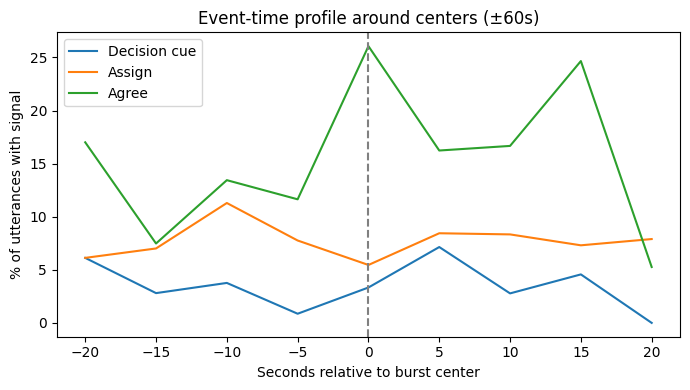

/var/folders/17/lphw45ds14n5t74zwjdfybx40000gn/T/ipykernel_5414/868552988.py:93: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  tmp = (mapped_all.sort_values(["session","sent_time_sec"])


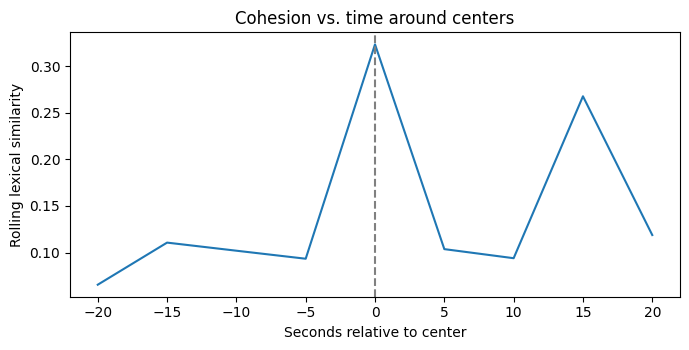

/var/folders/17/lphw45ds14n5t74zwjdfybx40000gn/T/ipykernel_5414/868552988.py:128: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  tmpH = (mapped_all.sort_values(["session","sent_time_sec"])


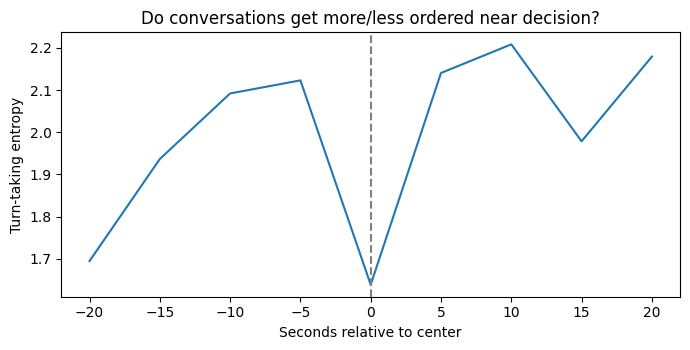

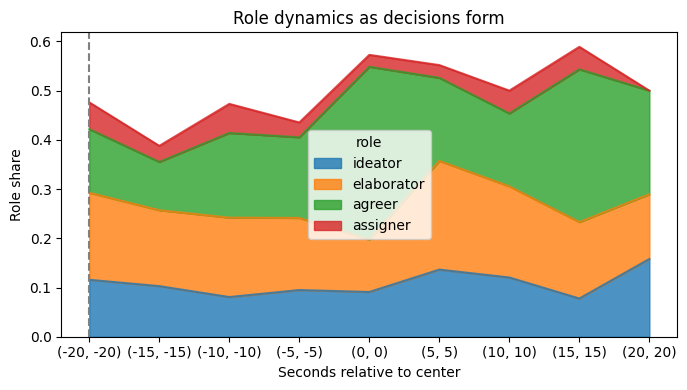

In [8]:
# === Decision Convergence Diagnostics ===
# (1) Event-time profile of decision signals
# (2) Lexical similarity around centers
# (3) Turn-taking entropy (fixed for string speakers)
# (4) Role dynamics (stacked area)

import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# ------------------------
# CONFIG
BIN  = 5    # seconds per bin
SPAN = 60   # +/- window span in seconds
MIN_WIN_FOR_STATS = 4  # min items to compute rolling stats

# ------------------------
# Sanity: do we have the mapped data?
try:
    _ = mapped_all
except NameError as e:
    raise RuntimeError(
        "`mapped_all` is not defined. Run your mapping step first (attach sentences to centers, "
        "producing columns: session, sent_time_sec, sentence, annotations, speaker, "
        "center_time_sec, delta_to_center, kw_*)."
    ) from e

need_cols = {
    "session","sent_time_sec","sentence","annotations","speaker",
    "center_time_sec","delta_to_center",
    "kw_decision","kw_assign","kw_agree","kw_summarize"
}
missing = need_cols - set(mapped_all.columns)
if missing:
    raise RuntimeError(f"`mapped_all` is missing columns: {missing}")

def within_span(df):
    out = df.copy()
    out["lag_bin"] = (out["delta_to_center"] // BIN).astype(int)
    out = out[(out["lag_bin"] >= -(SPAN//BIN)) & (out["lag_bin"] <= (SPAN//BIN))]
    out["lag_sec"] = out["lag_bin"] * BIN
    return out

# ------------------------
# 1) Event-time profile of decision signals
df = within_span(mapped_all.copy())

signals = {
    "Decision cue": "kw_decision",
    "Assign":       "kw_assign",
    "Agree":        "kw_agree",
}
prof = pd.DataFrame({
    label: df.groupby("lag_sec")[col].mean()
    for label, col in signals.items()
}).fillna(0.0)

plt.figure(figsize=(7,4))
for c in prof.columns:
    plt.plot(prof.index, 100*prof[c], label=c)
plt.axvline(0, linestyle="--", color="gray")
plt.xlabel("Seconds relative to burst center")
plt.ylabel("% of utterances with signal")
plt.title("Event-time profile around centers (±60s)")
plt.legend()
plt.tight_layout()
plt.show()

# ------------------------
# 2) Lexical similarity (rolling cosine to previous turn), then event-time average
def rolling_similarity(session_df, window=10):
    texts = session_df["sentence"].fillna("").astype(str).tolist()
    if len(texts) < 2:
        session_df = session_df.copy()
        session_df["sim_roll"] = np.nan
        return session_df
    # Fit TF-IDF on this session; small sessions handled
    try:
        X = TfidfVectorizer(min_df=1).fit_transform(texts)
    except ValueError:
        session_df = session_df.copy()
        session_df["sim_roll"] = np.nan
        return session_df
    # cosine to previous utterance
    sim_prev = [np.nan]
    for i in range(1, X.shape[0]):
        sim_prev.append(float(cosine_similarity(X[i-1], X[i])[0,0]))
    session_df = session_df.copy()
    # smooth a bit with rolling mean
    session_df["sim_roll"] = pd.Series(sim_prev).rolling(window, min_periods=3).mean().values
    return session_df

tmp = (mapped_all.sort_values(["session","sent_time_sec"])
                  .groupby("session", group_keys=False)
                  .apply(rolling_similarity, window=8))
tmp = within_span(tmp)
prof_sim = tmp.groupby("lag_sec")["sim_roll"].mean().dropna()

plt.figure(figsize=(7,3.6))
plt.plot(prof_sim.index, prof_sim.values)
plt.axvline(0, linestyle="--", color="gray")
plt.xlabel("Seconds relative to center")
plt.ylabel("Rolling lexical similarity")
plt.title("Cohesion vs. time around centers")
plt.tight_layout()
plt.show()

# ------------------------
# 3) Turn-taking entropy (string-safe)
def shannon_entropy_from_array(values):
    if len(values) < MIN_WIN_FOR_STATS:
        return np.nan
    counts = pd.Series(values).value_counts()
    p = counts / counts.sum()
    return float(-(p * np.log2(p)).sum())

def rolling_entropy(sess_df, window=12):
    speakers = sess_df["speaker"].fillna("NA").astype(str).to_numpy()
    H = np.full(len(speakers), np.nan, dtype=float)
    for i in range(len(speakers)):
        j0 = max(0, i - window + 1)
        win = speakers[j0:i+1]
        H[i] = shannon_entropy_from_array(win)
    out = sess_df.copy()
    out["H_speaker"] = H
    return out

tmpH = (mapped_all.sort_values(["session","sent_time_sec"])
                  .groupby("session", group_keys=False)
                  .apply(rolling_entropy, window=10))
tmpH = within_span(tmpH)
prof_H = tmpH.groupby("lag_sec")["H_speaker"].mean().dropna()

plt.figure(figsize=(7,3.6))
plt.plot(prof_H.index, prof_H.values)
plt.axvline(0, linestyle="--", color="gray")
plt.xlabel("Seconds relative to center")
plt.ylabel("Turn-taking entropy")
plt.title("Do conversations get more/less ordered near decision?")
plt.tight_layout()
plt.show()

# ------------------------
# 4) Role dynamics (stacked area)
def role_from_ann(a: str):
    a = str(a).lower()
    if "assign" in a or "action item" in a: return "assigner"
    if "summarize" in a: return "summarizer"
    if "agree" in a or "consensus" in a: return "agreer"
    if "new idea" in a: return "ideator"
    if "expand" in a: return "elaborator"
    if "explain" in a or "define" in a: return "explainer"
    return "other"

R = mapped_all.copy()
R["role"] = R["annotations"].map(role_from_ann)
R = within_span(R)

share = (R.groupby(["lag_sec","role"]).size()
           .groupby(level=0).apply(lambda x: x / x.sum())
           .unstack(fill_value=0))

core_roles = [r for r in ["ideator","elaborator","agreer","assigner"] if r in share.columns]
ax = share[core_roles].plot(kind="area", figsize=(7,4), alpha=0.8)
ax.axvline(0, linestyle="--", color="gray")
ax.set_xlabel("Seconds relative to center")
ax.set_ylabel("Role share")
ax.set_title("Role dynamics as decisions form")
plt.tight_layout()
plt.show()

### Sandwich analogy

In [10]:
# === Idea → Solution Linking & Summaries (robust, fast by default) ===========
# - Extracts per-burst "idea" (pre-center) and "solution" (at/after center) spans
# - Computes diagnostics (#utterances, speakers, decision intensity)
# - Summarizes solution via TF-IDF keywords (fast) or optional HF model (opt-in)
#
# Assumes you already have:
#   mapped_all: session, sent_time_sec, sentence, annotations, speaker,
#               center_time_sec, delta_to_center, kw_decision, kw_assign,
#               kw_agree, kw_summarize, [burst_id], [conference]
#   centers:    session, center_time_sec, burst_id

from pathlib import Path
import pandas as pd, numpy as np

# ---------------- Config ----------------
IDEA_WIN = (-60, -10)    # seconds
SOLN_WIN = (0, 30)
OUT_DIR  = Path("/Users/maxchalekson/Projects/NICO-Research/NICO_human-gemini/Data/scaling_outputs/summaries")
OUT_DIR.mkdir(parents=True, exist_ok=True)
OUT_CSV  = OUT_DIR / "burst_idea_solution_spans.csv"

USE_HF = False           # <<< Default OFF for speed/stability
MAX_HF_ROWS = 25         # if USE_HF=True, only summarize N “clearest” solutions

# ------------- Safety checks -------------
need_cols = {
    "session","sent_time_sec","sentence","annotations","speaker",
    "center_time_sec","delta_to_center",
    "kw_decision","kw_assign","kw_agree","kw_summarize"
}
missing = need_cols - set(mapped_all.columns)
if missing:
    raise ValueError(f"`mapped_all` missing columns: {missing}. Re-run mapping step.")

if not {"session","center_time_sec","burst_id"}.issubset(centers.columns):
    raise ValueError("`centers` must have columns: session, center_time_sec, burst_id.")

# ------------- Helpers -------------------
def _window_slice(df, lo, hi):
    return df[(df["delta_to_center"] >= lo) & (df["delta_to_center"] <= hi)]

def _norm_text(txt):
    return " ".join(str(txt).split())

def _keyword_density(df):
    n = len(df)
    if n == 0:
        return {"n":0, "decision_hits":0, "assign_hits":0, "agree_hits":0, "sum_hits":0,
                "decision_per_1000":0.0}
    d = int(df["kw_decision"].sum())
    a = int(df["kw_assign"].sum())
    g = int(df["kw_agree"].sum())
    s = int(df["kw_summarize"].sum())
    return {
        "n": n,
        "decision_hits": d,
        "assign_hits": a,
        "agree_hits": g,
        "sum_hits": s,
        "decision_per_1000": 1000.0 * d / n
    }

def _unique_speakers(df):
    if len(df) == 0: return 0
    return int(df["speaker"].dropna().astype(str).str.strip().nunique())

def _tfidf_keywords(text, topk=12):
    from sklearn.feature_extraction.text import TfidfVectorizer
    docs = [text]
    vec = TfidfVectorizer(stop_words="english", max_features=5000, ngram_range=(1,2))
    try:
        X = vec.fit_transform(docs)
        vocab = vec.get_feature_names_out()
        scores = X.toarray().ravel()
        idx = np.argsort(scores)[::-1][:topk]
        kws = [vocab[i] for i in idx if scores[i] > 0]
        return ", ".join(kws)
    except Exception:
        return ""

# Optional HF (opt-in & light)
_summarizer = None
def _maybe_load_hf():
    global _summarizer
    if _summarizer is not None:
        return _summarizer
    try:
        from transformers import pipeline
        _summarizer = pipeline("summarization", model="sshleifer/distilbart-cnn-12-6")
        return _summarizer
    except Exception:
        return None

def _smart_summarize(text, max_len_chars=400, max_summary_tokens=64):
    """
    Fast heuristics:
      - If text is short, skip HF and return empty summary + TF-IDF keywords.
      - If USE_HF is False or HF unavailable, return TF-IDF keywords only.
    """
    text = _norm_text(text)
    if not text:
        return "", ""
    if len(text) < 60:          # very short - no need for HF
        return "", _tfidf_keywords(text, topk=10)
    # cap input length (HF gets slow on long strings)
    text = text[:max_len_chars]

    if not USE_HF:
        return "", _tfidf_keywords(text, topk=12)

    summ = _maybe_load_hf()
    if summ is None:
        return "", _tfidf_keywords(text, topk=12)

    try:
        s = summ(text, max_length=max_summary_tokens, min_length=16, do_sample=False)[0]["summary_text"]
        return s, ""
    except Exception:
        # Any failure -> TF-IDF fallback
        return "", _tfidf_keywords(text, topk=12)

# ------------ Ensure numeric -------------
mapped_all = mapped_all.copy()
for c in ["center_time_sec","sent_time_sec","delta_to_center"]:
    mapped_all[c] = pd.to_numeric(mapped_all[c], errors="coerce")

# Make sure we have burst_id in mapped_all
if "burst_id" not in mapped_all.columns:
    mapped_all = mapped_all.merge(
        centers[["session","center_time_sec","burst_id"]],
        on=["session","center_time_sec"],
        how="left"
    )

# ------------ Build per-burst rows -------
rows = []
for _, c in centers[["session","center_time_sec","burst_id"]].drop_duplicates().iterrows():
    sess  = c["session"]
    ct    = float(c["center_time_sec"])
    bid   = c["burst_id"]

    S = mapped_all[(mapped_all["session"] == sess) &
                   (mapped_all["center_time_sec"] == ct)].copy()
    if S.empty:
        continue

    idea_df = _window_slice(S, *IDEA_WIN)
    soln_df = _window_slice(S, *SOLN_WIN)

    idea_kw   = _keyword_density(idea_df)
    soln_kw   = _keyword_density(soln_df)
    idea_spkr = _unique_speakers(idea_df)
    soln_spkr = _unique_speakers(soln_df)

    idea_text = " ".join(idea_df["sentence"].astype(str).tolist())
    soln_text = " ".join(soln_df["sentence"].astype(str).tolist())

    near_df = _window_slice(S, -5, 5)
    near_counts = {
        "near_decision_hits": int(near_df["kw_decision"].sum()),
        "near_assign_hits":   int(near_df["kw_assign"].sum()),
        "near_agree_hits":    int(near_df["kw_agree"].sum()),
    }

    rows.append({
        "session": sess,
        "burst_id": bid,
        "center_time_sec": ct,
        "idea_win_start": IDEA_WIN[0], "idea_win_end": IDEA_WIN[1],
        "soln_win_start": SOLN_WIN[0], "soln_win_end": SOLN_WIN[1],
        "idea_n_utts": idea_kw["n"],
        "idea_unique_speakers": idea_spkr,
        "idea_decision_per_1000": idea_kw["decision_per_1000"],
        "idea_assign_hits": idea_kw["assign_hits"],
        "idea_agree_hits":  idea_kw["agree_hits"],
        "soln_n_utts": soln_kw["n"],
        "soln_unique_speakers": soln_spkr,
        "soln_decision_per_1000": soln_kw["decision_per_1000"],
        "soln_assign_hits": soln_kw["assign_hits"],
        "soln_agree_hits":  soln_kw["agree_hits"],
        "idea_text": _norm_text(idea_text),
        "solution_text": _norm_text(soln_text),
        # summaries filled later (optionally HF for a subset)
        "solution_summary": "",
        "solution_keywords": "",
        **near_counts
    })

df_solution_spans = pd.DataFrame(rows).sort_values(["session","center_time_sec"]).reset_index(drop=True)

# --- Fill summaries (fast by default; optional HF for top-N) ---
if USE_HF:
    # choose top-N “clearest” solutions to summarize with HF
    cand = (df_solution_spans
            .assign(score=lambda d: d["soln_decision_per_1000"].fillna(0) + 0.1*d["soln_unique_speakers"].fillna(0))
            .sort_values("score", ascending=False)
            .head(MAX_HF_ROWS)
            .index)
else:
    cand = pd.Index([])

for i, row in df_solution_spans.iterrows():
    text = row["solution_text"]
    if i in cand:
        summ, kws = _smart_summarize(text, max_len_chars=400, max_summary_tokens=56)
    else:
        # TF-IDF only (fast)
        summ, kws = "", _tfidf_keywords(text, topk=12)
    df_solution_spans.at[i, "solution_summary"] = summ
    df_solution_spans.at[i, "solution_keywords"] = kws

# --- Save + preview ---
df_solution_spans.to_csv(OUT_CSV, index=False)
print(f"Saved: {OUT_CSV}")
display(df_solution_spans.head(8)[[
    "session","burst_id","center_time_sec",
    "idea_n_utts","idea_unique_speakers","idea_decision_per_1000",
    "soln_n_utts","soln_unique_speakers","soln_decision_per_1000",
    "near_decision_hits","solution_summary","solution_keywords"
]])

Saved: /Users/maxchalekson/Projects/NICO-Research/NICO_human-gemini/Data/scaling_outputs/summaries/burst_idea_solution_spans.csv


,session,burst_id,center_time_sec,idea_n_utts,idea_unique_speakers,idea_decision_per_1000,soln_n_utts,soln_unique_speakers,soln_decision_per_1000,near_decision_hits,solution_summary,solution_keywords
0,2021_04_22_MND_S1,2021_04_22_MND_S1_B1,251.0,5,4,200.000000,7,4,0.000000,0,,"um, things, time, uh, small molecules, real ti..."
1,2021_04_22_MND_S2,2021_04_22_MND_S2_B1,599.0,0,0,0.000000,1,1,0.000000,0,,"ve just, ve, um modifies, um, software um, sof..."
2,2021_04_22_MND_S3,2021_04_22_MND_S3_B1,259.0,1,1,0.000000,3,3,0.000000,0,,"um, know, like, think, model, single model, si..."
3,2021_04_22_MND_S4,2021_04_22_MND_S4_B1,861.0,11,5,0.000000,12,7,166.666667,0,,"know, like, right, yeah, just, work, wondering..."
4,2021_04_22_MND_S5,2021_04_22_MND_S5_B1,857.0,13,8,76.923077,5,5,0.000000,0,,"um, conditions, neurodevelopmental, neurodevel..."
5,2021_04_22_MND_S5,2021_04_22_MND_S5_B2,1197.0,0,0,0.000000,1,1,0.000000,0,,"thinking humoral, thinking, imagine thinking, ..."
6,2021_04_22_MND_S6,2021_04_22_MND_S6_B1,818.0,1,1,0.000000,10,4,200.000000,0,,"um, uh, yeah, members, point, species, gut, th..."
7,2021_04_22_MND_S7,2021_04_22_MND_S7_B1,875.0,6,5,333.333333,15,5,66.666667,0,,"like, um, maybe, yeah, just, sort, guess, asso..."


using this csv file

Rows: 105 | bursts (unique): 105
Non-empty solution windows: 105
Non-empty idea windows: 84
Correlation (idea vs solution decision density): 0.03

Solution unique speakers (5-number):
count    105.00
mean       3.89
std        2.14
min        1.00
25%        2.00
50%        4.00
75%        5.00
max       10.00

Solution decision/1000 (5-number):
count     105.00
mean       65.64
std       181.04
min         0.00
25%         0.00
50%         0.00
75%        38.46
max      1000.00

=== Exemplars (top 5) ===
          session             burst_id  center_time_sec  soln_unique_speakers  soln_n_utts  soln_decision_per_1000  soln_assign_hits  soln_agree_hits                                                            solution_keywords
2021_06_10_SLU_S7 2021_06_10_SLU_S7_B1            817.0                     8           17              235.294118                 1                3 uh, um, think, different, know, life, really, like, sort, hand, biology, lot

Saved exemplar snippets: /Users/ma

/var/folders/17/lphw45ds14n5t74zwjdfybx40000gn/T/ipykernel_5414/3862688999.py:87: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rarer_clearer = (df2.groupby("spk_bin")


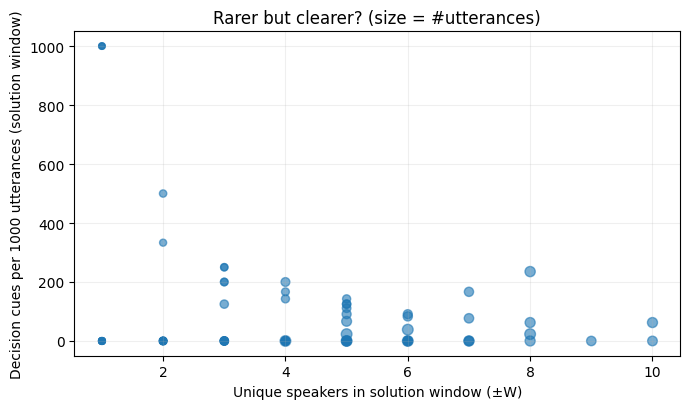

Saved: /Users/maxchalekson/Projects/NICO-Research/NICO_human-gemini/Data/scaling_outputs/summaries/solution_scatter_speakers_vs_density.png


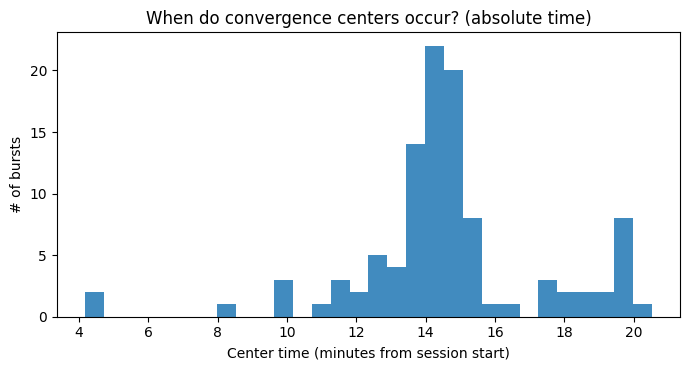

Saved: /Users/maxchalekson/Projects/NICO-Research/NICO_human-gemini/Data/scaling_outputs/summaries/centers_timing_absolute_minutes.png


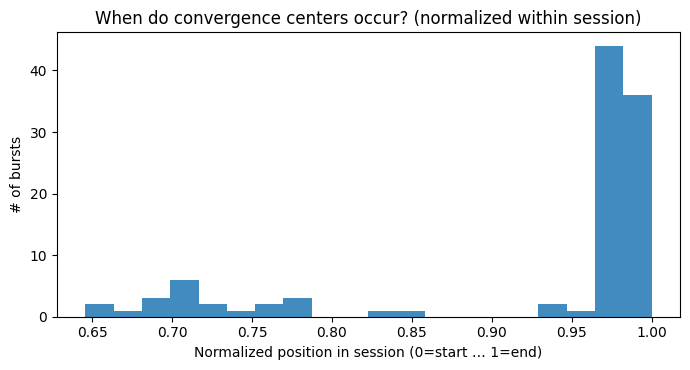

Saved: /Users/maxchalekson/Projects/NICO-Research/NICO_human-gemini/Data/scaling_outputs/summaries/centers_timing_normalized.png


In [12]:
# === From spans to exemplars & checks (+ visuals) ============================
from pathlib import Path
import pandas as pd, numpy as np
import matplotlib.pyplot as plt

DATA_DIR = Path("/Users/maxchalekson/Projects/NICO-Research/NICO_human-gemini/Data")
SUM_DIR  = DATA_DIR / "scaling_outputs" / "summaries"
SUM_DIR.mkdir(parents=True, exist_ok=True)

# --- Inputs ---
spans_csv = SUM_DIR / "burst_idea_solution_spans.csv"
df = pd.read_csv(spans_csv)

# We use mapped_all ONLY to compute session lengths for timing normalization
mapped_path = SUM_DIR / "mapped_all.csv"
if mapped_path.exists():
    mapped_all = pd.read_csv(mapped_path)
    # ensure numeric & sensible
    if "sent_time_sec" in mapped_all.columns:
        mapped_all["sent_time_sec"] = pd.to_numeric(mapped_all["sent_time_sec"], errors="coerce")
else:
    mapped_all = None

# 1) Sanity checks -------------------------------------------------------------
print("Rows:", len(df), "| bursts (unique):", df["burst_id"].nunique())
print("Non-empty solution windows:", (df["soln_n_utts"] > 0).sum())
print("Non-empty idea windows:", (df["idea_n_utts"] > 0).sum())

ok = (df["idea_decision_per_1000"].notna() & df["soln_decision_per_1000"].notna())
corr = df.loc[ok, ["idea_decision_per_1000","soln_decision_per_1000"]].corr().iloc[0,1]
print(f"Correlation (idea vs solution decision density): {corr:.2f}")

print("\nSolution unique speakers (5-number):")
print(df["soln_unique_speakers"].describe().round(2).to_string())

print("\nSolution decision/1000 (5-number):")
print(df["soln_decision_per_1000"].describe().round(2).to_string())

# 2) Pick exemplars ------------------------------------------------------------
min_speakers = 6
hi_thresh = df["soln_decision_per_1000"].quantile(0.90)  # top decile across ALL conferences
ex = (df[(df["soln_unique_speakers"] >= min_speakers) &
         (df["soln_decision_per_1000"] >= hi_thresh)]
      .sort_values(["soln_decision_per_1000","soln_unique_speakers"], ascending=False)
      .head(5)
      .copy())

print("\n=== Exemplars (top 5) ===")
cols = ["session","burst_id","center_time_sec",
        "soln_unique_speakers","soln_n_utts","soln_decision_per_1000",
        "soln_assign_hits","soln_agree_hits","solution_keywords"]
print(ex[cols].to_string(index=False))

# 3) Pull ±10s snippets for those exemplars -----------------------------------
# Note: requires mapped_all to exist (your sentences mapped to centers)
def snippet_for(session, center, half=10.0):
    if mapped_all is None:
        return pd.DataFrame(columns=["speaker","sentence","delta_to_center"])
    S = mapped_all[(mapped_all["session"]==session) &
                   (mapped_all["center_time_sec"]==center)]
    if S.empty:
        return pd.DataFrame(columns=["speaker","sentence","delta_to_center"])
    M = S[S["delta_to_center"].between(-half, +half)]
    return (M.sort_values("delta_to_center")
             [["speaker","sentence","delta_to_center"]]
             .reset_index(drop=True))

snips = []
for _, r in ex.iterrows():
    s = snippet_for(r["session"], r["center_time_sec"], half=10.0)
    s.insert(0, "center_time_sec", r["center_time_sec"])
    s.insert(0, "session", r["session"])
    s.insert(0, "burst_id", r["burst_id"])
    snips.append(s.assign(_note=f"speakers={int(r['soln_unique_speakers'])}, "
                                 f"dec/1k={r['soln_decision_per_1000']:.1f}, "
                                 f"kws={r['solution_keywords']}"))
snips_df = pd.concat(snips, ignore_index=True) if snips else pd.DataFrame()
snip_path = SUM_DIR / "exemplar_snippets_pm10s.csv"
snips_df.to_csv(snip_path, index=False)
print(f"\nSaved exemplar snippets: {snip_path}")

# 4) “Rarer but clearer” proxy check ------------------------------------------
df2 = df[df["soln_n_utts"]>0].copy()
df2["spk_bin"] = pd.cut(df2["soln_unique_speakers"],
                        bins=[0,2,4,6,8,12,99],
                        labels=["≤2","3–4","5–6","7–8","9–12","13+"])
rarer_clearer = (df2.groupby("spk_bin")
                   .agg(n_bursts=("burst_id","count"),
                        mean_dec_per_1000=("soln_decision_per_1000","mean"))
                   .reset_index())
rarer_clearer["mean_dec_per_1000"] = rarer_clearer["mean_dec_per_1000"].round(1)
print("\n=== Rarer but clearer (proxy by speakers in solution window) ===")
print(rarer_clearer.to_string(index=False))

# 5) VISUAL 1: Scatter — speakers vs decision density -------------------------
sc = df2.copy()
sc["soln_unique_speakers"] = pd.to_numeric(sc["soln_unique_speakers"], errors="coerce")
sc["soln_decision_per_1000"] = pd.to_numeric(sc["soln_decision_per_1000"], errors="coerce")
sc["soln_n_utts"] = pd.to_numeric(sc["soln_n_utts"], errors="coerce")
sc = sc.dropna(subset=["soln_unique_speakers","soln_decision_per_1000","soln_n_utts"])

plt.figure(figsize=(7,4.2))
sizes = 20 + 2.0 * sc["soln_n_utts"].clip(lower=1, upper=sc["soln_n_utts"].quantile(0.95))
plt.scatter(sc["soln_unique_speakers"], sc["soln_decision_per_1000"], s=sizes, alpha=0.6)
plt.xlabel("Unique speakers in solution window (±W)")
plt.ylabel("Decision cues per 1000 utterances (solution window)")
plt.title("Rarer but clearer? (size = #utterances)")
plt.grid(alpha=0.2)
plt.tight_layout()
out_scatter = SUM_DIR / "solution_scatter_speakers_vs_density.png"
plt.savefig(out_scatter, dpi=200)
plt.show()
print("Saved:", out_scatter)

# 6) VISUAL 2: Timing — when do centers occur? --------------------------------
# Absolute minutes:
df_tim = df.copy()
df_tim["center_time_sec"] = pd.to_numeric(df_tim["center_time_sec"], errors="coerce")
df_tim = df_tim.dropna(subset=["center_time_sec"])

plt.figure(figsize=(7,3.8))
plt.hist(df_tim["center_time_sec"]/60.0, bins=30, alpha=0.85)
plt.xlabel("Center time (minutes from session start)")
plt.ylabel("# of bursts")
plt.title("When do convergence centers occur? (absolute time)")
plt.tight_layout()
out_abs = SUM_DIR / "centers_timing_absolute_minutes.png"
plt.savefig(out_abs, dpi=200)
plt.show()
print("Saved:", out_abs)

# Normalized within-session position (0=start, 1=end), if session lengths available
if mapped_all is not None and "session" in mapped_all.columns:
    sess_len = (mapped_all.groupby("session")["sent_time_sec"]
                          .max()
                          .rename("session_len_sec")
                          .reset_index())
    df_norm = df_tim.merge(sess_len, on="session", how="left")
    df_norm["pos_in_session"] = (df_norm["center_time_sec"] / df_norm["session_len_sec"]).clip(0,1)
    plt.figure(figsize=(7,3.8))
    plt.hist(df_norm["pos_in_session"], bins=20, alpha=0.85)
    plt.xlabel("Normalized position in session (0=start … 1=end)")
    plt.ylabel("# of bursts")
    plt.title("When do convergence centers occur? (normalized within session)")
    plt.tight_layout()
    out_norm = SUM_DIR / "centers_timing_normalized.png"
    plt.savefig(out_norm, dpi=200)
    plt.show()
    print("Saved:", out_norm)
else:
    print("Skipping normalized timing plot (no mapped_all with session lengths found).")

going to split by conference

Centers: 105 | Sessions covered: 82 | Tracks: ['MND' 'ABI' 'SLU' 'MZT']


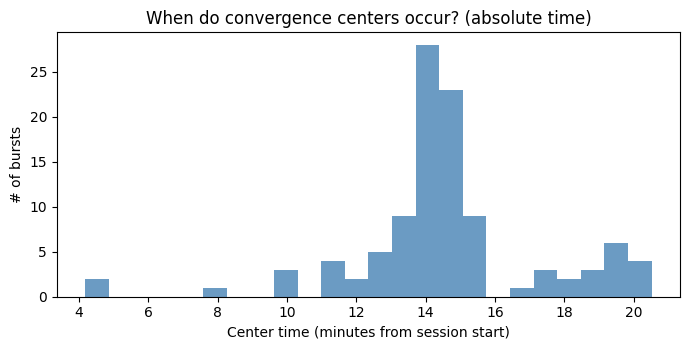

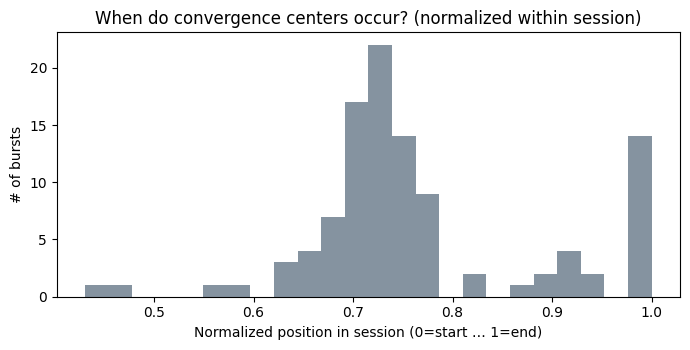

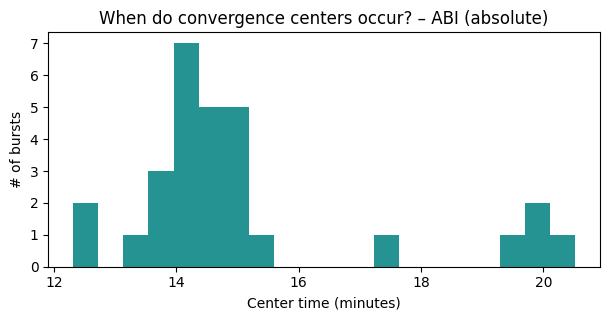

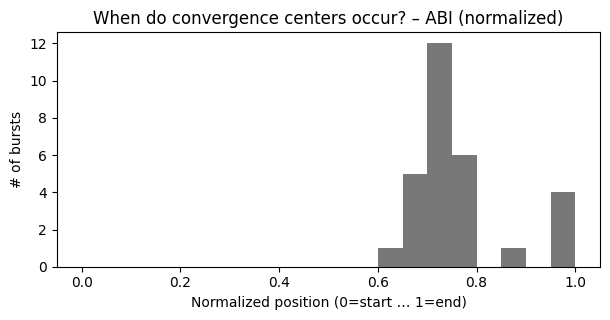

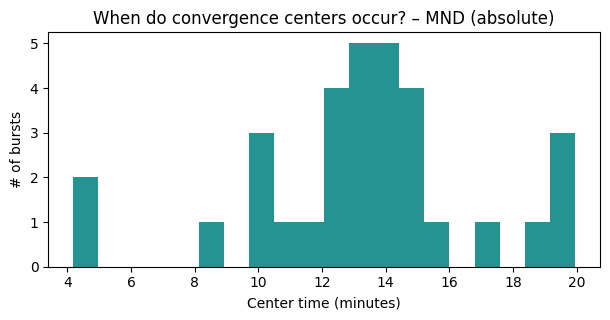

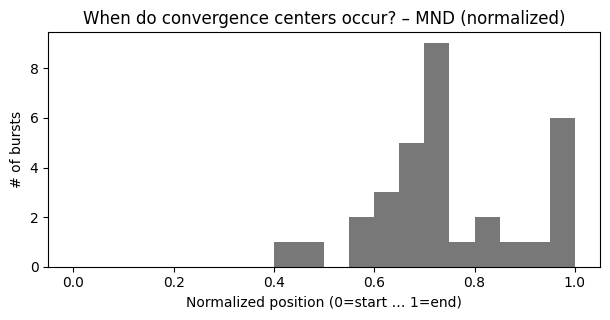

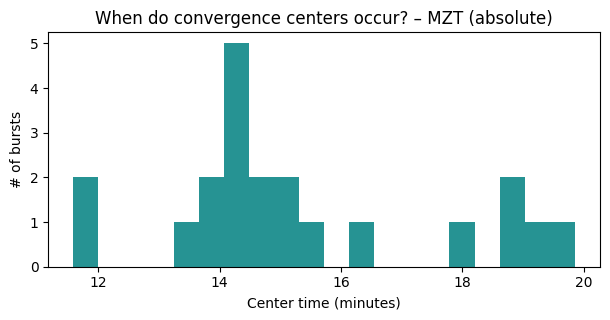

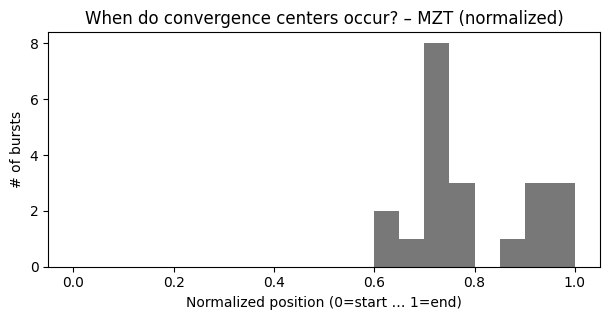

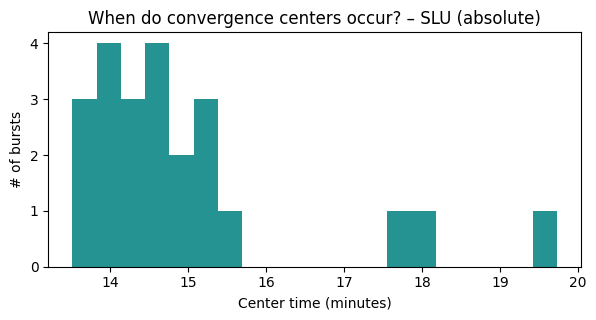

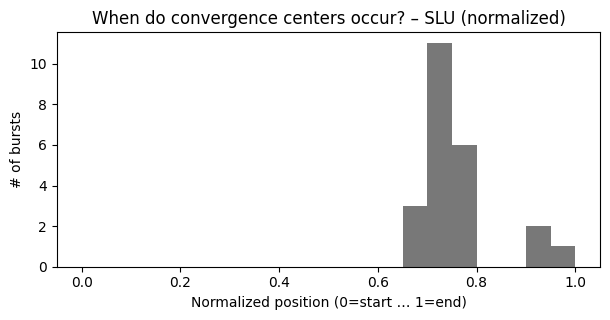


Per-track convergence timing stats:
track  n_centers  median_min  iqr_min  median_norm  iqr_norm  p95_norm
  ABI         29      14.400    0.933        0.736     0.051     0.998
  MND         32      13.458    2.706        0.717     0.158     1.000
  MZT         21      14.567    2.392        0.750     0.181     1.000
  SLU         23      14.567    1.125        0.728     0.057     0.925
Saved: /Users/maxchalekson/Projects/NICO-Research/NICO_human-gemini/Data/scaling_outputs/summaries/centers_when_per_track_stats.csv

Pooled: 19% of centers occur in the last 10% of the session.
Interpretation: absolute-time peaks (e.g., ~14–16 min) reflect similar session lengths,
while normalized position shows the real behavior: teams converge near the end across tracks.


In [13]:
# === Convergence timing: pooled + per-track ==============================
# Inputs required in memory:
#   - sents   : columns ["session","sent_time_sec", ...]
#   - centers : columns ["session","center_time_sec", ...]
# Output:
#   - pooled histograms (absolute minutes and within-session normalized)
#   - per-track histograms (ABI/MND/MZT/SLU) for both views
#   - per-track summary stats CSV

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ---------- paths ----------
DATA_DIR = Path("/Users/maxchalekson/Projects/NICO-Research/NICO_human-gemini/Data")
SUM_DIR  = DATA_DIR / "scaling_outputs" / "summaries"
SUM_DIR.mkdir(parents=True, exist_ok=True)

# ---------- helpers ----------
def extract_track(session_str: str) -> str:
    """
    Session looks like 'YYYY_MM_DD_TRACK_S#' -> return TRACK
    """
    parts = str(session_str).split("_")
    return parts[3] if len(parts) >= 5 else "UNK"

# ---------- session lengths ----------
sess_len = (sents.groupby("session")["sent_time_sec"]
                 .max()
                 .rename("session_len_sec")
                 .reset_index())

timing = (centers[["session","center_time_sec"]].copy()
          .merge(sess_len, on="session", how="left"))

# Drop any centers where we don't know session length
timing = timing.dropna(subset=["session_len_sec"]).copy()

# Features
timing["center_min"]  = timing["center_time_sec"] / 60.0
timing["center_norm"] = (timing["center_time_sec"] / timing["session_len_sec"]).clip(0, 1)
timing["track"]       = timing["session"].map(extract_track)

print("Centers:", len(timing), "| Sessions covered:", timing["session"].nunique(), "| Tracks:", timing["track"].unique())

# ---------- pooled histograms ----------
plt.figure(figsize=(7,3.6))
plt.hist(timing["center_min"], bins=24, color="steelblue", alpha=0.8)
plt.xlabel("Center time (minutes from session start)")
plt.ylabel("# of bursts")
plt.title("When do convergence centers occur? (absolute time)")
plt.tight_layout()
plt.savefig(SUM_DIR / "centers_when_absolute_pooled.png", dpi=160)
plt.show()

plt.figure(figsize=(7,3.6))
plt.hist(timing["center_norm"], bins=24, color="slategray", alpha=0.85)
plt.xlabel("Normalized position in session (0=start … 1=end)")
plt.ylabel("# of bursts")
plt.title("When do convergence centers occur? (normalized within session)")
plt.tight_layout()
plt.savefig(SUM_DIR / "centers_when_normalized_pooled.png", dpi=160)
plt.show()

# ---------- per-track histograms ----------
tracks = sorted(timing["track"].unique())
per_track_stats = []

for t in tracks:
    sub = timing.loc[timing["track"]==t].copy()
    if sub.empty: 
        continue

    # Absolute minutes
    plt.figure(figsize=(6.2,3.3))
    plt.hist(sub["center_min"], bins=20, color="teal", alpha=0.85)
    plt.xlabel("Center time (minutes)")
    plt.ylabel("# of bursts")
    plt.title(f"When do convergence centers occur? – {t} (absolute)")
    plt.tight_layout()
    plt.savefig(SUM_DIR / f"centers_when_absolute_{t}.png", dpi=160)
    plt.show()

    # Normalized 0..1
    plt.figure(figsize=(6.2,3.3))
    plt.hist(sub["center_norm"], bins=np.linspace(0,1,21), color="dimgray", alpha=0.9)
    plt.xlabel("Normalized position (0=start … 1=end)")
    plt.ylabel("# of bursts")
    plt.title(f"When do convergence centers occur? – {t} (normalized)")
    plt.tight_layout()
    plt.savefig(SUM_DIR / f"centers_when_normalized_{t}.png", dpi=160)
    plt.show()

    # Collect quick stats
    per_track_stats.append({
        "track": t,
        "n_centers": len(sub),
        "median_min": np.median(sub["center_min"]),
        "iqr_min": np.percentile(sub["center_min"], 75) - np.percentile(sub["center_min"], 25),
        "median_norm": np.median(sub["center_norm"]),
        "iqr_norm": np.percentile(sub["center_norm"], 75) - np.percentile(sub["center_norm"], 25),
        "p95_norm": np.percentile(sub["center_norm"], 95),
    })

# ---------- save stats ----------
stats_df = pd.DataFrame(per_track_stats)
stats_csv = SUM_DIR / "centers_when_per_track_stats.csv"
stats_df.to_csv(stats_csv, index=False)
print("\nPer-track convergence timing stats:")
print(stats_df.round(3).to_string(index=False))
print("Saved:", stats_csv)

# ---------- talking points (print to console) ----------
late_share = (timing["center_norm"] >= 0.9).mean()
print(f"\nPooled: {late_share:.0%} of centers occur in the last 10% of the session.")
print("Interpretation: absolute-time peaks (e.g., ~14–16 min) reflect similar session lengths,")
print("while normalized position shows the real behavior: teams converge near the end across tracks.")

## post advice from EV

[Slide5] Using exemplar burst → session=2021_04_23_MND_S2 | center=797.00s | window=±20s

[Slide5] Example-burst stats
• Utterances in ±20s: 20
• Unique speakers:        6
• Decision hits:          11
• Decision density:       550.0 per 1000 utterances
[Slide5] Saved snippet → /Users/maxchalekson/Projects/NICO-Research/NICO_human-gemini/Data/scaling_outputs/summaries/slide5_example_snippet.csv


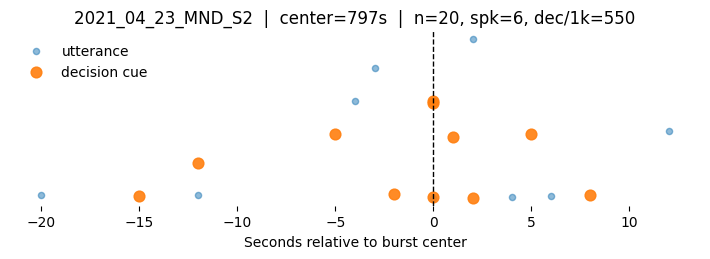

[Slide5] Saved timeline plot → /Users/maxchalekson/Projects/NICO-Research/NICO_human-gemini/Data/scaling_outputs/summaries/slide5_example_timeline.png


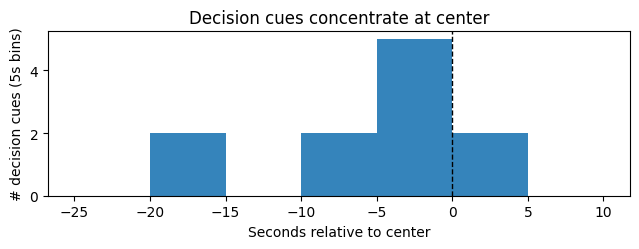

[Slide5] Saved bar plot → /Users/maxchalekson/Projects/NICO-Research/NICO_human-gemini/Data/scaling_outputs/summaries/slide5_example_decbar.png


In [16]:
# === Slide 5: Worked Example – One Burst =====================================
# Creates a concrete example snippet + stats + a small timeline plot to paste into the slide

from pathlib import Path
import json
import pandas as pd, numpy as np, matplotlib.pyplot as plt

# ----- Config -----
DATA_DIR = Path("/Users/maxchalekson/Projects/NICO-Research/NICO_human-gemini/Data")
OUT_DIR  = DATA_DIR / "scaling_outputs" / "summaries"
OUT_DIR.mkdir(parents=True, exist_ok=True)

W = 20.0            # half-window (±W seconds) shown on the slide
MIN_UTTS = 10       # only consider bursts with ≥ this many utterances in ±W
DEDUP = True        # drop exact duplicates per (rounded second, speaker, sentence)
JITTER_STD = 0.06   # vertical jitter to separate overlapping dots; 0 to disable
ADD_BAR = True      # also save a 5s-binned bar chart of decision cues

# sanity: required columns
_need = {
    "session","center_time_sec","delta_to_center","speaker","sentence",
    "kw_decision","kw_assign","kw_summarize","kw_agree"
}
missing = _need - set(mapped_all.columns)
if missing:
    raise RuntimeError(f"mapped_all is missing columns: {sorted(missing)}")

# ----- Helper: pick an exemplar burst (or set one explicitly) -----
def pick_best_burst(mapped_df: pd.DataFrame, half=W, min_utts=MIN_UTTS):
    gcols = ["session","center_time_sec"]
    base = (mapped_df[mapped_df["delta_to_center"].between(-half, +half)]
            .assign(decision_any=lambda d: d[["kw_decision","kw_assign","kw_summarize","kw_agree"]].any(axis=1)))
    if base.empty:
        raise RuntimeError("No sentences fall within ±W of any center. Check mapped_all or W.")

    grp = (base.groupby(gcols, as_index=False)
              .agg(n_utts=("sentence","size"),
                   n_dec=("decision_any","sum"),
                   n_speakers=("speaker", lambda s: s.astype(str).str.strip().nunique())))
    grp = grp[grp["n_utts"] >= min_utts].copy()
    if grp.empty:
        raise RuntimeError(f"No bursts have at least {min_utts} utterances in ±{half}s.")
    grp["decisions_per_1000"] = 1000 * grp["n_dec"] / grp["n_utts"].clip(lower=1)
    best = grp.sort_values(["decisions_per_1000","n_speakers","n_utts"], ascending=False).iloc[0]
    return best["session"], float(best["center_time_sec"])

# Option B (manual): uncomment to force a specific burst
# FORCED_SESSION = "2021_04_23_MND_S2"
# FORCED_CENTER  = 797.0

try:
    FORCED_SESSION, FORCED_CENTER  # noqa: F821
    sess, center = FORCED_SESSION, float(FORCED_CENTER)
except Exception:
    sess, center = pick_best_burst(mapped_all, half=W, min_utts=MIN_UTTS)

print(f"[Slide5] Using exemplar burst → session={sess} | center={center:.2f}s | window=±{W:.0f}s")

# ----- Extract the window for the slide -----
win = (mapped_all[(mapped_all["session"]==sess) &
                  (mapped_all["center_time_sec"]==center) &
                  (mapped_all["delta_to_center"].between(-W, +W))].copy())

if win.empty:
    raise RuntimeError("Selected burst has no utterances within ±W. Try another burst or adjust W.")

# Optional: de-duplicate exact repeats at the same rounded second
if DEDUP:
    win["t_round"] = np.round(win["delta_to_center"]).astype(int)
    win = (win.sort_values(["t_round","speaker","sentence"])
              .drop_duplicates(["t_round","speaker","sentence"])
              .drop(columns=["t_round"], errors="ignore"))

# Compact “signals” tag per utterance for the slide table
def _signals_row(r):
    tags = []
    if pd.notna(r.get("kw_decision"))  and r["kw_decision"]:  tags.append("DECIDE")
    if pd.notna(r.get("kw_assign"))    and r["kw_assign"]:    tags.append("ASSIGN")
    if pd.notna(r.get("kw_agree"))     and r["kw_agree"]:     tags.append("AGREE")
    if pd.notna(r.get("kw_summarize")) and r["kw_summarize"]: tags.append("SUM")
    return ", ".join(tags)

win = win.sort_values("delta_to_center")
snippet = (win.assign(signal_tags=win.apply(_signals_row, axis=1))
             [["delta_to_center","speaker","sentence","signal_tags"]]
             .rename(columns={"delta_to_center":"t_rel_sec"}))

# ----- Compute slide stats -----
n_utts = len(win)
is_dec_series = (win[["kw_decision","kw_assign","kw_summarize","kw_agree"]].fillna(False)).any(axis=1)
n_dec  = int(is_dec_series.sum())
n_spk  = win["speaker"].astype(str).str.strip().nunique()
decisions_per_1000 = 1000 * n_dec / max(n_utts, 1)

print("\n[Slide5] Example-burst stats")
print(f"• Utterances in ±{W:.0f}s: {n_utts}")
print(f"• Unique speakers:        {n_spk}")
print(f"• Decision hits:          {n_dec}")
print(f"• Decision density:       {decisions_per_1000:.1f} per 1000 utterances")

# Save a CSV + JSON you can paste from
csv_path = OUT_DIR / "slide5_example_snippet.csv"
snippet.to_csv(csv_path, index=False)
with open(OUT_DIR / "slide5_example_stats.json","w") as f:
    json.dump({
        "session": sess, "center_time_sec": center, "window_sec": W,
        "n_utts": int(n_utts), "n_speakers": int(n_spk),
        "n_decision_hits": int(n_dec),
        "decisions_per_1000": float(round(decisions_per_1000, 2))
    }, f, indent=2)
print(f"[Slide5] Saved snippet → {csv_path}")

# ----- Tiny timeline scatter for the slide -----
plt.figure(figsize=(7.2, 2.7))
spk_codes = {s:i for i,s in enumerate(win["speaker"].astype(str).unique())}
x = win["delta_to_center"].to_numpy()
y_base = np.array([spk_codes[s] for s in win["speaker"].astype(str)])
y = y_base + (np.random.default_rng(0).normal(0, JITTER_STD, len(y_base)) if JITTER_STD>0 else 0)

is_dec = is_dec_series.to_numpy()
plt.scatter(x[~is_dec], y[~is_dec], s=20, alpha=0.5, label="utterance")
plt.scatter(x[is_dec],  y[is_dec],  s=60, alpha=0.9, marker="o", label="decision cue")

plt.axvline(0, color="black", linestyle="--", linewidth=1)
plt.xlabel("Seconds relative to burst center")
plt.yticks([]); plt.box(False)
title = f"{sess}  |  center={center:.0f}s  |  n={n_utts}, spk={n_spk}, dec/1k={decisions_per_1000:.0f}"
plt.title(title)
plt.legend(loc="upper left", frameon=False)
plt.tight_layout()
png_path = OUT_DIR / "slide5_example_timeline.png"
plt.savefig(png_path, dpi=200)
plt.show()
print(f"[Slide5] Saved timeline plot → {png_path}")

# ----- Optional: 5s-binned bar chart of decision cues ------------------------
if ADD_BAR:
    binw = 5
    b = (win.assign(bin=((win["delta_to_center"]//binw)*binw).astype(int),
                    decision_any=is_dec_series)
           .groupby("bin").agg(dec=("decision_any","sum")).reset_index())
    plt.figure(figsize=(6.5, 2.6))
    plt.bar(b["bin"]-binw/2, b["dec"], width=binw, alpha=0.9)
    plt.axvline(0, ls="--", c="k", lw=1)
    plt.xlabel("Seconds relative to center")
    plt.ylabel("# decision cues (5s bins)")
    plt.title("Decision cues concentrate at center")
    plt.tight_layout()
    bar_path = OUT_DIR / "slide5_example_decbar.png"
    plt.savefig(bar_path, dpi=200)
    plt.show()
    print(f"[Slide5] Saved bar plot → {bar_path}")